# Cluster Asset Impact Analysis Pipeline_gmm

This notebook combines GMM cluster standardization and the current v2 asset impact analysis into one runnable pipeline.

## Purpose
- start from a model-specific cluster output table coming directly from a clustering notebook
- standardize that output into a reusable cluster-membership table with `developer_id`, `cluster_id`, and `cluster_label`
- join the standardized cluster-membership table back to `dev_profile_final_v4`
- summarize every currently surfaced asset and asset-adjacent signal by cluster
- compare exposed vs not exposed developers within each cluster for each signal
- keep the workflow fast and reproducible before attempting the heavier event-time version

## How To Use This Notebook
1. Use either a DuckDB table name or a parquet path for `SOURCE_TABLE` in the parameter cell.
2. If you downloaded model outputs as parquet exports, you can either point `SOURCE_TABLE` directly at one parquet file or use the optional load step below to load selected tables into DuckDB first.
3. Set `ID_COL` to the developer id column and `CLUSTER_ID_COL` to the cluster id column from the source data.
4. If your source already has human-readable labels, set `CLUSTER_LABEL_COL` to that column name. If not, set it to `None` and this notebook will create labels as `cluster_<cluster_id>`.
5. Set `OUTPUT_TABLE` to the standardized membership table you want to create.
6. Run the notebook top to bottom. The downstream impact analysis will automatically use the standardized output table.

## Standardized Output Schema
- `developer_id`
- `cluster_id`
- `cluster_label`

## Input assumptions
Source cluster table:
- one row per developer coming from a cluster modeling notebook
- includes a developer id column and a cluster id column
- may optionally include a cluster label column

Profile table:
- one row per developer in `dev_profile_final_v4`
- developer-level aggregated activity, persona, journey, dormancy, and effort fields


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

pd.set_option('display.max_colwidth', 120)
plt.style.use('ggplot')

## 1. Parameters

In [2]:
DB_PATH = 'developer_project.duckdb'

# Source cluster parquet or table produced by a model-specific workflow.
SOURCE_TABLE = 'dev_gmm_stratified_clusters_v1'
SOURCE_IS_PARQUET = SOURCE_TABLE.lower().endswith('.parquet')
SOURCE_RELATION = f"read_parquet('{SOURCE_TABLE.replace('\\', '/')}')" if SOURCE_IS_PARQUET else SOURCE_TABLE

# Standardized cluster-membership table created by this pipeline.
OUTPUT_TABLE = 'cluster_membership_gmm_stratified_v1'

# Source column mappings.
ID_COL = 'developer_id'
CLUSTER_ID_COL = 'gmm_cluster_id'
CLUSTER_LABEL_COL = 'gmm_cluster_label'  # Source has human-readable labels.

# Optional helper for loading selected parquet exports into DuckDB first.
LOAD_EXPORTS_TO_DUCKDB = True
PARQUET_DIR = Path('toexport_clusters')
TABLES_TO_LOAD = [
    'dev_gmm_stratified_clusters_v1',
]

# Downstream analysis reads from the standardized output table.
CLUSTER_TABLE = OUTPUT_TABLE
PROFILE_TABLE = 'dev_profile_final_v4'

CLUSTER_PROFILE_TABLE = 'cluster_profile_asset_base_v2'
CLUSTER_ASSET_CATALOG_TABLE = 'cluster_asset_catalog_v2'
CLUSTER_ASSET_LONG_TABLE = 'cluster_asset_long_v2'
CLUSTER_ASSET_SUMMARY_TABLE = 'cluster_asset_summary_v2'
CLUSTER_ASSET_EXPOSURE_TABLE = 'cluster_asset_exposure_by_cluster_v2'
CLUSTER_EXPOSED_OUTCOME_TABLE = 'cluster_asset_outcomes_exposed_v2'
CLUSTER_ASSET_INTENSITY_TABLE = 'cluster_asset_intensity_by_cluster_v2'
CLUSTER_ASSET_EXPOSED_PROFILE_TABLE = 'cluster_asset_exposed_profile_v2'
CLUSTER_ASSET_PRIORITY_TABLE = 'cluster_asset_priority_by_cluster_v2'
CLUSTER_PERSONA_PROFILE_TABLE = 'cluster_persona_profile_v2'
CLUSTER_JOURNEY_PROFILE_TABLE = 'cluster_journey_profile_v2'
CLUSTER_JOURNEY_STATE_PROFILE_TABLE = 'cluster_journey_state_profile_v2'
CLUSTER_LIFECYCLE_PROFILE_TABLE = 'cluster_lifecycle_profile_v2'
CLUSTER_DORMANCY_PROFILE_TABLE = 'cluster_dormancy_profile_v2'
CLUSTER_EFFORT_PROFILE_TABLE = 'cluster_effort_profile_v2'
CLUSTER_ACTIVITY_DEBUG_TABLE = 'cluster_recent_activity_debug_v2'

MIN_EXPOSED_DEVELOPERS = 100


## 2. Optional: Load Selected Exported Tables Into DuckDB, Then Validate Inputs


In [3]:
con = duckdb.connect(DB_PATH)

if LOAD_EXPORTS_TO_DUCKDB:
    for table_name in TABLES_TO_LOAD:
        parquet_path = PARQUET_DIR / f"{table_name}.parquet"

        if not parquet_path.exists():
            print(f"Skipping missing file: {parquet_path}")
            continue

        con.execute(f"""
            CREATE OR REPLACE TABLE {table_name} AS
            SELECT *
            FROM read_parquet('{parquet_path.as_posix()}')
        """)

        n_rows = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
        print(f"Loaded {table_name}: {n_rows:,} rows")

available_tables = set(con.execute('SHOW TABLES').fetchdf()['name'].tolist())
required_tables = [PROFILE_TABLE] if SOURCE_IS_PARQUET else [SOURCE_TABLE, PROFILE_TABLE]
missing_tables = [t for t in required_tables if t not in available_tables]
if missing_tables:
    raise ValueError(f'Missing required tables: {missing_tables}')

source_cols = con.execute(f"DESCRIBE SELECT * FROM {SOURCE_RELATION}").fetchdf()['column_name'].tolist()
required_source_cols = [ID_COL, CLUSTER_ID_COL]
missing_source_cols = [c for c in required_source_cols if c not in source_cols]
if missing_source_cols:
    raise ValueError(f'Missing required source columns in {SOURCE_TABLE}: {missing_source_cols}')

if CLUSTER_LABEL_COL is not None and CLUSTER_LABEL_COL not in source_cols:
    raise ValueError(f'CLUSTER_LABEL_COL={CLUSTER_LABEL_COL!r} not found in {SOURCE_TABLE}')

profile_cols = con.execute(f"PRAGMA table_info({PROFILE_TABLE})").fetchdf()['name'].tolist()

display(pd.DataFrame({'required_table': required_tables}))
print(f'Source table: {SOURCE_TABLE}')
print('Source columns available:', len(source_cols))
print(f'Profile table: {PROFILE_TABLE}')
print('Profile columns available:', len(profile_cols))
display(pd.DataFrame({'source_column': source_cols}))

display(Markdown('### Source Sample Rows'))
source_preview_cols = [c for c in [ID_COL, CLUSTER_ID_COL] + ([CLUSTER_LABEL_COL] if CLUSTER_LABEL_COL is not None else []) if c in source_cols]
display(con.execute(f"SELECT {', '.join(source_preview_cols)} FROM {SOURCE_RELATION} LIMIT 10").fetchdf())

display(Markdown('### Source Cluster Counts Preview'))
display(con.execute(f"SELECT {CLUSTER_ID_COL} AS source_cluster_id, COUNT(*) AS developers FROM {SOURCE_RELATION} GROUP BY 1 ORDER BY developers DESC, source_cluster_id LIMIT 20").fetchdf())


Loaded dev_gmm_stratified_clusters_v1: 9,381,508 rows


,required_table
0,dev_gmm_stratified_clusters_v1
1,dev_profile_final_v4


Source table: dev_gmm_stratified_clusters_v1
Source columns available: 6
Profile table: dev_profile_final_v4
Profile columns available: 145


,source_column
0,developer_id
1,stratum
2,gmm_cluster_id
3,gmm_cluster_label
4,gmm_max_posterior
5,gmm_posterior_entropy


### Source Sample Rows

,developer_id,gmm_cluster_id,gmm_cluster_label
0,10545032,0,active_c0
1,8165860,4,active_c4
2,7895235,4,active_c4
3,10558946,0,active_c0
4,10562398,0,active_c0
5,8490949,4,active_c4
6,10569108,0,active_c0
7,5692488,1,active_c1
8,5059111,4,active_c4
9,10213600,3,active_c3


### Source Cluster Counts Preview

,source_cluster_id,developers
0,-1,6807297
1,-2,1717692
2,2,374522
3,1,221494
4,0,168944
5,4,64463
6,3,27096


## 3. Build Standardized Cluster Membership Table


In [4]:
if CLUSTER_LABEL_COL is None:
    standardize_sql = f"""
    CREATE OR REPLACE TABLE {OUTPUT_TABLE} AS
    SELECT
        {ID_COL} AS developer_id,
        {CLUSTER_ID_COL} AS cluster_id,
        'cluster_' || CAST({CLUSTER_ID_COL} AS VARCHAR) AS cluster_label
    FROM {SOURCE_RELATION}
    """
else:
    standardize_sql = f"""
    CREATE OR REPLACE TABLE {OUTPUT_TABLE} AS
    SELECT
        {ID_COL} AS developer_id,
        {CLUSTER_ID_COL} AS cluster_id,
        {CLUSTER_LABEL_COL} AS cluster_label
    FROM {SOURCE_RELATION}
    """

print(standardize_sql)
con.execute(standardize_sql)
print(f'Created standardized table: {OUTPUT_TABLE}')



    CREATE OR REPLACE TABLE cluster_membership_gmm_stratified_v1 AS
    SELECT
        developer_id AS developer_id,
        gmm_cluster_id AS cluster_id,
        gmm_cluster_label AS cluster_label
    FROM dev_gmm_stratified_clusters_v1
    
Created standardized table: cluster_membership_gmm_stratified_v1


## 4. Validate Standardized Cluster Table


In [5]:
cluster_cols = con.execute(f"PRAGMA table_info({CLUSTER_TABLE})").fetchdf()['name'].tolist()
required_cluster_cols = ['developer_id', 'cluster_id', 'cluster_label']
missing_cluster_cols = [c for c in required_cluster_cols if c not in cluster_cols]
if missing_cluster_cols:
    raise ValueError(f'{CLUSTER_TABLE} is missing required columns: {missing_cluster_cols}')

display(Markdown('### Standardized Row Count'))
display(con.execute(f'SELECT COUNT(*) AS n_rows FROM {CLUSTER_TABLE}').fetchdf())

display(Markdown('### Standardized Null Check'))
display(con.execute(f"""
SELECT
    SUM(CASE WHEN developer_id IS NULL THEN 1 ELSE 0 END) AS null_developer_id,
    SUM(CASE WHEN cluster_id IS NULL THEN 1 ELSE 0 END) AS null_cluster_id,
    SUM(CASE WHEN cluster_label IS NULL THEN 1 ELSE 0 END) AS null_cluster_label
FROM {CLUSTER_TABLE}
""").fetchdf())

display(Markdown('### Output Sample Rows'))
display(con.execute(f'SELECT * FROM {CLUSTER_TABLE} LIMIT 10').fetchdf())

display(Markdown('### Output Cluster Counts'))
display(con.execute(f"""
SELECT cluster_label, COUNT(*) AS developers
FROM {CLUSTER_TABLE}
GROUP BY 1
ORDER BY developers DESC, cluster_label
""").fetchdf())

profile_cols = con.execute(f"PRAGMA table_info({PROFILE_TABLE})").fetchdf()['name'].tolist()
print('Standardized cluster table columns:', cluster_cols)
print('Profile table columns:', len(profile_cols))


### Standardized Row Count

,n_rows
0,9381508


### Standardized Null Check

,null_developer_id,null_cluster_id,null_cluster_label
0,0.0,0.0,0.0


### Output Sample Rows

,developer_id,cluster_id,cluster_label
0,10545032,0,active_c0
1,8165860,4,active_c4
2,7895235,4,active_c4
3,10558946,0,active_c0
4,10562398,0,active_c0
5,8490949,4,active_c4
6,10569108,0,active_c0
7,5692488,1,active_c1
8,5059111,4,active_c4
9,10213600,3,active_c3


### Output Cluster Counts

,cluster_label,developers
0,unactivated,6697675
1,dormant_low_effort_lapsed,858704
2,dormant_mid_effort_lapsed,687155
3,active_c2,272713
4,at_risk_c1,174528
5,at_risk_c0,117555
6,unknown,109622
7,at_risk_c2,101809
8,dormant_former_high_effort,89564
9,dormant_former_power_builder,82269


Standardized cluster table columns: ['developer_id', 'cluster_id', 'cluster_label']
Profile table columns: 145


## 5. Build Asset Catalog

These are the currently available asset and asset-adjacent signals already surfaced in `dev_profile_final_v4`.

Transformed helper columns are intentionally excluded so this notebook stays focused on interpretable underlying signals.

In [6]:
def col_exists(col):
    return col in profile_cols

asset_catalog = [
    {'asset_name': 'dli_training', 'column_name': 'lifetime_dli_training_count', 'asset_group': 'activity_asset', 'asset_role': 'learning_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'webinar', 'column_name': 'lifetime_webinar_count', 'asset_group': 'activity_asset', 'asset_role': 'learning_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'devzone_download', 'column_name': 'lifetime_devzone_download_count', 'asset_group': 'activity_asset', 'asset_role': 'download_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'ngc_download', 'column_name': 'lifetime_ngc_download_count', 'asset_group': 'activity_asset', 'asset_role': 'download_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'forum_contribution', 'column_name': 'lifetime_forum_count', 'asset_group': 'activity_asset', 'asset_role': 'community_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'bug_filed', 'column_name': 'lifetime_bug_count', 'asset_group': 'activity_asset', 'asset_role': 'community_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'hackathon', 'column_name': 'lifetime_hackathon_count', 'asset_group': 'activity_asset', 'asset_role': 'community_activity', 'signal_type': 'count', 'analysis_role': 'rankable_activity_asset'},
    {'asset_name': 'api_usage', 'column_name': 'lifetime_api_count', 'asset_group': 'outcome_signal', 'asset_role': 'product_adoption', 'signal_type': 'count', 'analysis_role': 'likely_outcome'},
    {'asset_name': 'discover_count', 'column_name': 'lifetime_discover_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'learn_count', 'column_name': 'lifetime_learn_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'evaluate_count', 'column_name': 'lifetime_evaluate_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_lifetime', 'column_name': 'lifetime_build_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'champion_count_lifetime', 'column_name': 'lifetime_champion_count', 'asset_group': 'cluster_descriptor', 'asset_role': 'journey_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_0_30d', 'column_name': 'build_count_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_30_90d', 'column_name': 'build_count_30_90d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_count_90_180d', 'column_name': 'build_count_90_180d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_share_0_30d', 'column_name': 'build_share_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'rate', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'build_velocity_0_30_vs_30_90', 'column_name': 'build_velocity_0_30_vs_30_90', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'rate', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'weighted_recent_build', 'column_name': 'weighted_recent_build', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'count', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'active_non_builder_0_30d', 'column_name': 'active_non_builder_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'low_volume_builder_0_30d', 'column_name': 'low_volume_builder_0_30d', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'recent_build_flag', 'column_name': 'recent_build_flag', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'},
    {'asset_name': 'recent_champion_flag', 'column_name': 'recent_champion_flag', 'asset_group': 'cluster_descriptor', 'asset_role': 'recent_behavior_descriptor', 'signal_type': 'binary', 'analysis_role': 'cluster_behavior_descriptor'}
]

available_assets = [asset for asset in asset_catalog if col_exists(asset['column_name'])]
missing_assets = [asset['column_name'] for asset in asset_catalog if not col_exists(asset['column_name'])]

if not available_assets:
    raise ValueError('No asset-related columns from the catalog were found in dev_profile_final_v4')

asset_catalog_df = pd.DataFrame(available_assets)
display(asset_catalog_df)
print('Asset rows in scope:', len(asset_catalog_df))
if missing_assets:
    print('Catalog columns not present in profile table:', missing_assets)

,asset_name,column_name,asset_group,asset_role,signal_type,analysis_role
0,dli_training,lifetime_dli_training_count,activity_asset,learning_activity,count,rankable_activity_asset
1,webinar,lifetime_webinar_count,activity_asset,learning_activity,count,rankable_activity_asset
2,devzone_download,lifetime_devzone_download_count,activity_asset,download_activity,count,rankable_activity_asset
3,ngc_download,lifetime_ngc_download_count,activity_asset,download_activity,count,rankable_activity_asset
4,forum_contribution,lifetime_forum_count,activity_asset,community_activity,count,rankable_activity_asset
5,bug_filed,lifetime_bug_count,activity_asset,community_activity,count,rankable_activity_asset
6,hackathon,lifetime_hackathon_count,activity_asset,community_activity,count,rankable_activity_asset
7,api_usage,lifetime_api_count,outcome_signal,product_adoption,count,likely_outcome
8,discover_count,lifetime_discover_count,cluster_descriptor,journey_descriptor,count,cluster_behavior_descriptor
9,learn_count,lifetime_learn_count,cluster_descriptor,journey_descriptor,count,cluster_behavior_descriptor


Asset rows in scope: 23


## 6. Build Base Cluster-Profile Table And Long Asset Table

In [7]:
base_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_PROFILE_TABLE} AS
SELECT
    c.developer_id,
    c.cluster_id,
    c.cluster_label,
    p.*
FROM {CLUSTER_TABLE} c
JOIN {PROFILE_TABLE} p USING (developer_id)
"""

con.execute(base_sql)
con.register('asset_catalog_df_view', asset_catalog_df)
con.execute(f'CREATE OR REPLACE TABLE {CLUSTER_ASSET_CATALOG_TABLE} AS SELECT * FROM asset_catalog_df_view')

asset_selects = []
for asset in available_assets:
    column_name = asset['column_name']
    asset_selects.append(f"""
    SELECT
        developer_id,
        cluster_id,
        cluster_label,
        '{asset['asset_name']}' AS asset_name,
        '{asset['asset_group']}' AS asset_group,
        '{asset['asset_role']}' AS asset_role,
        '{asset['analysis_role']}' AS analysis_role,
        '{asset['signal_type']}' AS signal_type,
        '{column_name}' AS source_column,
        COALESCE(CAST({column_name} AS DOUBLE), 0.0) AS exposure_value,
        CASE WHEN COALESCE(CAST({column_name} AS DOUBLE), 0.0) > 0 THEN 1 ELSE 0 END AS exposed_flag
    FROM {CLUSTER_PROFILE_TABLE}
    """)

long_asset_sql = f"CREATE OR REPLACE TABLE {CLUSTER_ASSET_LONG_TABLE} AS\n" + "\nUNION ALL\n".join(asset_selects)
con.execute(long_asset_sql)

display(con.execute(f'SELECT COUNT(*) AS n_rows, COUNT(DISTINCT developer_id) AS distinct_developers FROM {CLUSTER_PROFILE_TABLE}').fetchdf())
display(con.execute(f'SELECT COUNT(*) AS asset_rows, COUNT(DISTINCT asset_name) AS distinct_assets FROM {CLUSTER_ASSET_LONG_TABLE}').fetchdf())
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_LONG_TABLE} ORDER BY cluster_label, asset_group, asset_name LIMIT 10').fetchdf())

,n_rows,distinct_developers
0,9379190,9379190


,asset_rows,distinct_assets
0,215721370,23


,developer_id,cluster_id,cluster_label,asset_name,asset_group,asset_role,analysis_role,signal_type,source_column,exposure_value,exposed_flag
0,10461046,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
1,10334659,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
2,10411048,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
3,10411873,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
4,10414475,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
5,10415119,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
6,10343467,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
7,10344390,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
8,10348225,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0
9,10282543,0,active_c0,bug_filed,activity_asset,community_activity,rankable_activity_asset,count,lifetime_bug_count,0.0,0


## 7. Cluster Size And Signal Coverage Summary

In [8]:
summary_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_SUMMARY_TABLE} AS
WITH per_dev_asset_counts AS (
    SELECT
        developer_id,
        cluster_label,
        SUM(CASE WHEN analysis_role = 'rankable_activity_asset' THEN exposed_flag ELSE 0 END) AS rankable_activity_assets_exposed,
        SUM(CASE WHEN analysis_role = 'cluster_behavior_descriptor' THEN exposed_flag ELSE 0 END) AS behavior_descriptors_active,
        SUM(CASE WHEN analysis_role = 'likely_outcome' THEN exposed_flag ELSE 0 END) AS likely_outcomes_active
    FROM {CLUSTER_ASSET_LONG_TABLE}
    GROUP BY 1,2
)
SELECT
    b.cluster_label,
    COUNT(*) AS developers,
    AVG(a.rankable_activity_assets_exposed) AS avg_rankable_activity_assets_exposed,
    AVG(a.behavior_descriptors_active) AS avg_behavior_descriptors_active,
    AVG(a.likely_outcomes_active) AS avg_likely_outcomes_active,
    AVG(b.activity_count_0_30d) AS avg_activity_count_0_30d,
    AVG(b.activity_count_30_90d) AS avg_activity_count_30_90d,
    AVG(b.activity_count_90_180d) AS avg_activity_count_90_180d,
    MEDIAN(b.activity_count_0_30d) AS median_activity_count_0_30d,
    AVG(b.high_effort_count_0_30d) AS avg_high_effort_count_0_30d,
    MEDIAN(b.high_effort_count_0_30d) AS median_high_effort_count_0_30d,
    AVG(CASE WHEN b.activity_count_0_30d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_0_30d,
    AVG(CASE WHEN b.activity_count_30_90d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_30_90d,
    AVG(CASE WHEN b.activity_count_90_180d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_90_180d,
    AVG(CASE WHEN b.dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
    AVG(CASE WHEN b.dormancy_status = 'At_Risk' THEN 1.0 ELSE 0.0 END) AS pct_at_risk,
    AVG(CASE WHEN b.dormancy_status = 'Cooling' THEN 1.0 ELSE 0.0 END) AS pct_cooling,
    AVG(CASE WHEN b.dormancy_status = 'Dormant' THEN 1.0 ELSE 0.0 END) AS pct_dormant,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Builder' THEN 1.0 ELSE 0.0 END) AS pct_builder,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Evaluator' THEN 1.0 ELSE 0.0 END) AS pct_evaluator,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Explorer' THEN 1.0 ELSE 0.0 END) AS pct_explorer,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Learner' THEN 1.0 ELSE 0.0 END) AS pct_learner,
    AVG(CASE WHEN b.persona = 'CUDA' THEN 1.0 ELSE 0.0 END) AS pct_cuda,
    AVG(CASE WHEN b.persona = 'GenAI' THEN 1.0 ELSE 0.0 END) AS pct_genai,
    AVG(CASE WHEN b.persona = 'Robotics' THEN 1.0 ELSE 0.0 END) AS pct_robotics,
    AVG(CASE WHEN b.persona = 'Simulation' THEN 1.0 ELSE 0.0 END) AS pct_simulation,
    AVG(CASE WHEN b.persona = 'Learning_Community' THEN 1.0 ELSE 0.0 END) AS pct_learning_community,
    AVG(CASE WHEN b.persona = 'Unknown' THEN 1.0 ELSE 0.0 END) AS pct_unknown_persona
FROM {CLUSTER_PROFILE_TABLE} b
JOIN per_dev_asset_counts a USING (developer_id, cluster_label)
GROUP BY 1
ORDER BY developers DESC, cluster_label
"""

persona_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_PERSONA_PROFILE_TABLE} AS
SELECT cluster_label, persona AS persona_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

journey_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_JOURNEY_PROFILE_TABLE} AS
SELECT cluster_label, behavior_journey_stage_30d AS journey_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

journey_state_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_JOURNEY_STATE_PROFILE_TABLE} AS
SELECT cluster_label, current_journey_state_30d AS journey_state_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

lifecycle_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_LIFECYCLE_PROFILE_TABLE} AS
SELECT cluster_label, final_lifecycle_status AS lifecycle_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

dormancy_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_DORMANCY_PROFILE_TABLE} AS
SELECT cluster_label, dormancy_status AS dormancy_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

effort_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_EFFORT_PROFILE_TABLE} AS
SELECT cluster_label, developer_effort_level AS effort_bucket, COUNT(*) AS developers,
       COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY cluster_label) AS pct_within_cluster
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1,2
"""

activity_debug_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ACTIVITY_DEBUG_TABLE} AS
SELECT
    cluster_label,
    COUNT(*) AS developers,
    AVG(activity_count_0_30d) AS avg_activity_count_0_30d,
    AVG(activity_count_30_90d) AS avg_activity_count_30_90d,
    AVG(activity_count_90_180d) AS avg_activity_count_90_180d,
    MEDIAN(activity_count_0_30d) AS median_activity_count_0_30d,
    MEDIAN(activity_count_30_90d) AS median_activity_count_30_90d,
    MEDIAN(activity_count_90_180d) AS median_activity_count_90_180d,
    AVG(CASE WHEN activity_count_0_30d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_0_30d,
    AVG(CASE WHEN activity_count_30_90d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_30_90d,
    AVG(CASE WHEN activity_count_90_180d > 0 THEN 1.0 ELSE 0.0 END) AS pct_any_activity_90_180d,
    AVG(CASE WHEN dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
    AVG(CASE WHEN dormancy_status = 'Dormant' THEN 1.0 ELSE 0.0 END) AS pct_dormant,
    AVG(CASE WHEN dormancy_status = 'Unactivated' THEN 1.0 ELSE 0.0 END) AS pct_unactivated
FROM {CLUSTER_PROFILE_TABLE}
GROUP BY 1
ORDER BY developers DESC
"""

con.execute(summary_sql)
con.execute(persona_sql)
con.execute(journey_sql)
con.execute(journey_state_sql)
con.execute(lifecycle_sql)
con.execute(dormancy_sql)
con.execute(effort_sql)
con.execute(activity_debug_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_SUMMARY_TABLE}').fetchdf())

,cluster_label,developers,avg_rankable_activity_assets_exposed,avg_behavior_descriptors_active,avg_likely_outcomes_active,avg_activity_count_0_30d,avg_activity_count_30_90d,avg_activity_count_90_180d,median_activity_count_0_30d,avg_high_effort_count_0_30d,...,pct_builder,pct_evaluator,pct_explorer,pct_learner,pct_cuda,pct_genai,pct_robotics,pct_simulation,pct_learning_community,pct_unknown_persona
0,unactivated,6695357,0.440779,1.263337,0.008180,0.055822,0.060342,0.080361,0.0,0.035955,...,0.004484,0.032632,0.000002,0.001987,0.292503,0.273242,0.046088,0.062580,0.053324,0.272264
1,dormant_low_effort_lapsed,858704,0.829476,2.139836,0.036222,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000075,0.000000,0.000000,0.000000,0.640375,0.127412,0.055362,0.075523,0.038100,0.063227
2,dormant_mid_effort_lapsed,687155,1.009251,2.597763,0.005850,0.000000,0.000000,0.000000,0.0,0.000000,...,0.051753,0.000831,0.000000,0.000000,0.706612,0.089735,0.072428,0.035599,0.085439,0.010187
3,active_c2,272713,1.025305,3.043944,0.133019,0.000000,1.403890,2.634066,0.0,0.000000,...,0.107743,0.009053,0.000000,0.000000,0.453814,0.284746,0.114468,0.043988,0.072688,0.030296
4,at_risk_c1,174528,0.639422,1.844031,0.114320,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.005363,0.000000,0.000000,0.366503,0.359094,0.092787,0.028632,0.093125,0.059859
5,at_risk_c0,117555,1.370099,2.994913,0.038637,0.000000,0.000000,0.000000,0.0,0.000000,...,0.389443,0.007273,0.000000,0.000000,0.535690,0.120548,0.260151,0.038918,0.032470,0.012224
6,unknown,109622,1.075541,1.826449,0.013163,0.091305,0.079008,0.072093,0.0,0.000000,...,0.001970,0.000000,0.000401,0.009779,0.788765,0.028762,0.058519,0.049488,0.012662,0.061803
7,at_risk_c2,101809,1.023318,2.380477,0.005235,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.804791,0.078942,0.022071,0.046715,0.015185,0.032296
8,dormant_former_high_effort,89564,1.406391,3.060136,0.011377,0.000000,0.000000,0.000000,0.0,0.000000,...,0.474242,0.038129,0.000000,0.000000,0.606337,0.091052,0.161650,0.041121,0.096735,0.003104
9,dormant_former_power_builder,82269,1.267245,3.100256,0.003841,0.000000,0.000000,0.000000,0.0,0.000000,...,0.999903,0.000085,0.000000,0.000000,0.428169,0.036490,0.527586,0.002431,0.002589,0.002735


## 8. Exposure Summary By Cluster And Asset/Signal

In [9]:
exposure_summary_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_EXPOSURE_TABLE} AS
SELECT
    cluster_label,
    asset_group,
    asset_role,
    analysis_role,
    signal_type,
    asset_name,
    source_column,
    COUNT(*) AS developers,
    SUM(exposed_flag) AS exposed_developers,
    AVG(exposed_flag) AS exposure_rate,
    AVG(exposure_value) AS avg_exposure_value_all,
    AVG(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS avg_exposure_value_exposed,
    MEDIAN(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS median_exposure_value_exposed
FROM {CLUSTER_ASSET_LONG_TABLE}
GROUP BY 1,2,3,4,5,6,7
"""

con.execute(exposure_summary_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_EXPOSURE_TABLE} ORDER BY cluster_label, asset_group, exposure_rate DESC, asset_name').fetchdf())

,cluster_label,asset_group,asset_role,analysis_role,signal_type,asset_name,source_column,developers,exposed_developers,exposure_rate,avg_exposure_value_all,avg_exposure_value_exposed,median_exposure_value_exposed
0,active_c0,activity_asset,download_activity,rankable_activity_asset,count,devzone_download,lifetime_devzone_download_count,51389,369.0,0.007181,0.171165,23.837398,2.0
1,active_c0,activity_asset,learning_activity,rankable_activity_asset,count,dli_training,lifetime_dli_training_count,51389,276.0,0.005371,0.015645,2.913043,2.0
2,active_c0,activity_asset,learning_activity,rankable_activity_asset,count,webinar,lifetime_webinar_count,51389,131.0,0.002549,0.005157,2.022901,1.0
3,active_c0,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,51389,92.0,0.001790,0.112631,62.913043,2.0
4,active_c0,activity_asset,community_activity,rankable_activity_asset,count,forum_contribution,lifetime_forum_count,51389,25.0,0.000486,0.002666,5.480000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,unknown,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,recent_build_flag,recent_build_flag,109622,216.0,0.001970,0.001970,1.000000,1.0
318,unknown,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,low_volume_builder_0_30d,low_volume_builder_0_30d,109622,178.0,0.001624,0.001624,1.000000,1.0
319,unknown,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,rate,build_velocity_0_30_vs_30_90,build_velocity_0_30_vs_30_90,109622,5.0,0.000046,0.000046,1.000000,1.0
320,unknown,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,recent_champion_flag,recent_champion_flag,109622,5.0,0.000046,0.000046,1.000000,1.0


## 9. Exposed vs Not Exposed Outcomes Within Each Cluster And Signal

This is the first-pass asset impact readout. It is descriptive, not causal.

In [10]:
outcomes_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_EXPOSED_OUTCOME_TABLE} AS
SELECT
    l.cluster_label,
    l.asset_group,
    l.asset_role,
    l.analysis_role,
    l.signal_type,
    l.asset_name,
    l.source_column,
    CASE WHEN l.exposed_flag = 1 THEN 'Exposed' ELSE 'Not Exposed' END AS exposure_status,
    COUNT(*) AS developers,
    AVG(l.exposure_value) AS avg_exposure_value,
    MEDIAN(l.exposure_value) AS median_exposure_value,
    AVG(b.activity_count_0_30d) AS avg_activity_count_0_30d,
    MEDIAN(b.activity_count_0_30d) AS median_activity_count_0_30d,
    AVG(b.high_effort_count_0_30d) AS avg_high_effort_count_0_30d,
    MEDIAN(b.high_effort_count_0_30d) AS median_high_effort_count_0_30d,
    AVG(b.activity_velocity_0_30_vs_30_90) AS avg_activity_velocity,
    AVG(b.weighted_recent_activity) AS avg_weighted_recent_activity,
    AVG(b.lifetime_api_count) AS avg_lifetime_api_count,
    AVG(CASE WHEN b.dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
    AVG(CASE WHEN b.behavior_journey_stage_30d = 'Builder' THEN 1.0 ELSE 0.0 END) AS pct_builder,
    AVG(CASE WHEN b.developer_effort_level IN ('high effort', 'very high effort') THEN 1.0 ELSE 0.0 END) AS pct_high_effort_level
FROM {CLUSTER_ASSET_LONG_TABLE} l
JOIN {CLUSTER_PROFILE_TABLE} b
  ON l.developer_id = b.developer_id
 AND l.cluster_id = b.cluster_id
 AND l.cluster_label = b.cluster_label
GROUP BY 1, 2, 3, 4, 5, 6, 7, 8
ORDER BY l.cluster_label, l.analysis_role, l.asset_name, exposure_status
"""

con.execute(outcomes_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_EXPOSED_OUTCOME_TABLE}').fetchdf())

,cluster_label,asset_group,asset_role,analysis_role,signal_type,asset_name,source_column,exposure_status,developers,avg_exposure_value,...,avg_activity_count_0_30d,median_activity_count_0_30d,avg_high_effort_count_0_30d,median_high_effort_count_0_30d,avg_activity_velocity,avg_weighted_recent_activity,avg_lifetime_api_count,pct_active,pct_builder,pct_high_effort_level
0,active_c0,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,binary,active_non_builder_0_30d,active_non_builder_0_30d,Exposed,51389,1.000000,...,16.869894,7.0,0.994026,1.0,3.808554,10.137991,15.936582,1.000000,0.001245,1.000000
1,active_c0,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,build_count_0_30d,build_count_0_30d,Not Exposed,51389,0.000000,...,16.869894,7.0,0.994026,1.0,3.808554,10.137991,15.936582,1.000000,0.001245,1.000000
2,active_c0,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,build_count_30_90d,build_count_30_90d,Exposed,27,6.851852,...,8.592593,2.0,0.185185,0.0,1.058851,9.829630,18.814815,1.000000,0.370370,1.000000
3,active_c0,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,build_count_30_90d,build_count_30_90d,Not Exposed,51362,0.000000,...,16.874246,7.0,0.994451,1.0,4.056855,10.138153,15.935069,1.000000,0.001051,1.000000
4,active_c0,cluster_descriptor,recent_behavior_descriptor,cluster_behavior_descriptor,count,build_count_90_180d,build_count_90_180d,Exposed,31,9.741935,...,5.387097,2.0,0.774194,0.0,1.322146,7.841935,18.741935,1.000000,0.516129,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,unknown,activity_asset,community_activity,rankable_activity_asset,count,hackathon,lifetime_hackathon_count,Not Exposed,109612,0.000000,...,0.091295,0.0,0.000000,0.0,0.363071,0.085690,0.185865,0.012143,0.001971,0.191886
532,unknown,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,Exposed,332,1.090361,...,0.027108,0.0,0.000000,0.0,0.000000,0.034337,0.054217,0.015060,0.003012,0.222892
533,unknown,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,Not Exposed,109290,0.000000,...,0.091500,0.0,0.000000,0.0,0.364520,0.085850,0.186248,0.012142,0.001967,0.191792
534,unknown,activity_asset,learning_activity,rankable_activity_asset,count,webinar,lifetime_webinar_count,Exposed,2107,1.630755,...,0.093972,0.0,0.000000,0.0,0.127767,0.107641,0.236355,0.021832,0.004271,0.442810


## 10. Breadth, Intensity, And Volume Readouts

This section summarizes cluster activity assets using three simpler concepts: breadth, intensity, and total volume.

It is descriptive only. The goal is to show which assets are most common, most intense, and largest by total usage within each cluster.

In [11]:
intensity_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_INTENSITY_TABLE} AS
SELECT
    cluster_label,
    asset_group,
    asset_role,
    analysis_role,
    signal_type,
    asset_name,
    source_column,
    COUNT(*) AS developers,
    SUM(exposed_flag) AS exposed_developers,
    AVG(exposure_value) AS avg_exposure_value_all,
    AVG(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS avg_exposure_value_exposed,
    MEDIAN(CASE WHEN exposed_flag = 1 THEN exposure_value END) AS median_exposure_value_exposed,
    QUANTILE_CONT(CASE WHEN exposed_flag = 1 THEN exposure_value END, 0.90) AS p90_exposure_value_exposed,
    SUM(exposure_value) AS total_exposure_value,
    SUM(exposure_value) * 1.0 / NULLIF(COUNT(*), 0) AS asset_volume_per_cluster_developer,
    SUM(exposure_value) * 1.0 / NULLIF(SUM(exposed_flag), 0) AS asset_volume_per_exposed_developer,
    SUM(exposure_value) * 1.0 / NULLIF(SUM(SUM(exposure_value)) OVER (PARTITION BY asset_name), 0) AS share_of_asset_volume
FROM {CLUSTER_ASSET_LONG_TABLE}
WHERE signal_type IN ('count', 'rate')
GROUP BY 1,2,3,4,5,6,7
"""

profile_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_EXPOSED_PROFILE_TABLE} AS
WITH cluster_asset_grid AS (
    SELECT DISTINCT
        c.cluster_label,
        a.asset_group,
        a.asset_role,
        a.analysis_role,
        a.signal_type,
        a.asset_name,
        a.column_name AS source_column
    FROM (SELECT DISTINCT cluster_label FROM {CLUSTER_PROFILE_TABLE}) c
    CROSS JOIN {CLUSTER_ASSET_CATALOG_TABLE} a
),
exposed_only AS (
    SELECT
        l.cluster_label,
        l.asset_group,
        l.asset_role,
        l.analysis_role,
        l.signal_type,
        l.asset_name,
        l.source_column,
        COUNT(*) AS exposed_developers,
        AVG(l.exposure_value) AS avg_exposure_value_exposed,
        MEDIAN(l.exposure_value) AS median_exposure_value_exposed,
        AVG(CASE WHEN b.persona = 'CUDA' THEN 1.0 ELSE 0.0 END) AS pct_cuda,
        AVG(CASE WHEN b.persona = 'GenAI' THEN 1.0 ELSE 0.0 END) AS pct_genai,
        AVG(CASE WHEN b.persona = 'Robotics' THEN 1.0 ELSE 0.0 END) AS pct_robotics,
        AVG(CASE WHEN b.persona = 'Simulation' THEN 1.0 ELSE 0.0 END) AS pct_simulation,
        AVG(CASE WHEN b.persona = 'Learning_Community' THEN 1.0 ELSE 0.0 END) AS pct_learning_community,
        AVG(CASE WHEN b.persona = 'Unknown' THEN 1.0 ELSE 0.0 END) AS pct_unknown_persona,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Builder' THEN 1.0 ELSE 0.0 END) AS pct_builder,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Evaluator' THEN 1.0 ELSE 0.0 END) AS pct_evaluator,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Explorer' THEN 1.0 ELSE 0.0 END) AS pct_explorer,
        AVG(CASE WHEN b.behavior_journey_stage_30d = 'Learner' THEN 1.0 ELSE 0.0 END) AS pct_learner,
        AVG(CASE WHEN b.dormancy_status = 'Active' THEN 1.0 ELSE 0.0 END) AS pct_active,
        AVG(CASE WHEN b.dormancy_status = 'At_Risk' THEN 1.0 ELSE 0.0 END) AS pct_at_risk,
        AVG(CASE WHEN b.dormancy_status = 'Cooling' THEN 1.0 ELSE 0.0 END) AS pct_cooling,
        AVG(CASE WHEN b.dormancy_status = 'Dormant' THEN 1.0 ELSE 0.0 END) AS pct_dormant,
        AVG(CASE WHEN b.developer_effort_level = 'very high effort' THEN 1.0 ELSE 0.0 END) AS pct_very_high_effort,
        AVG(CASE WHEN b.developer_effort_level = 'high effort' THEN 1.0 ELSE 0.0 END) AS pct_high_effort,
        AVG(CASE WHEN b.developer_effort_level = 'medium effort' THEN 1.0 ELSE 0.0 END) AS pct_medium_effort,
        AVG(CASE WHEN b.developer_effort_level = 'low effort' THEN 1.0 ELSE 0.0 END) AS pct_low_effort
    FROM {CLUSTER_ASSET_LONG_TABLE} l
    JOIN {CLUSTER_PROFILE_TABLE} b
      ON l.developer_id = b.developer_id
     AND l.cluster_id = b.cluster_id
     AND l.cluster_label = b.cluster_label
    WHERE l.exposed_flag = 1
    GROUP BY 1,2,3,4,5,6,7
)
SELECT
    g.cluster_label,
    g.asset_group,
    g.asset_role,
    g.analysis_role,
    g.signal_type,
    g.asset_name,
    g.source_column,
    COALESCE(e.exposed_developers, 0) AS exposed_developers,
    COALESCE(e.avg_exposure_value_exposed, 0.0) AS avg_exposure_value_exposed,
    COALESCE(e.median_exposure_value_exposed, 0.0) AS median_exposure_value_exposed,
    COALESCE(e.pct_cuda, 0.0) AS pct_cuda,
    COALESCE(e.pct_genai, 0.0) AS pct_genai,
    COALESCE(e.pct_robotics, 0.0) AS pct_robotics,
    COALESCE(e.pct_simulation, 0.0) AS pct_simulation,
    COALESCE(e.pct_learning_community, 0.0) AS pct_learning_community,
    COALESCE(e.pct_unknown_persona, 0.0) AS pct_unknown_persona,
    COALESCE(e.pct_builder, 0.0) AS pct_builder,
    COALESCE(e.pct_evaluator, 0.0) AS pct_evaluator,
    COALESCE(e.pct_explorer, 0.0) AS pct_explorer,
    COALESCE(e.pct_learner, 0.0) AS pct_learner,
    COALESCE(e.pct_active, 0.0) AS pct_active,
    COALESCE(e.pct_at_risk, 0.0) AS pct_at_risk,
    COALESCE(e.pct_cooling, 0.0) AS pct_cooling,
    COALESCE(e.pct_dormant, 0.0) AS pct_dormant,
    COALESCE(e.pct_very_high_effort, 0.0) AS pct_very_high_effort,
    COALESCE(e.pct_high_effort, 0.0) AS pct_high_effort,
    COALESCE(e.pct_medium_effort, 0.0) AS pct_medium_effort,
    COALESCE(e.pct_low_effort, 0.0) AS pct_low_effort
FROM cluster_asset_grid g
LEFT JOIN exposed_only e
  ON g.cluster_label = e.cluster_label
 AND g.asset_group = e.asset_group
 AND g.asset_role = e.asset_role
 AND g.analysis_role = e.analysis_role
 AND g.signal_type = e.signal_type
 AND g.asset_name = e.asset_name
 AND g.source_column = e.source_column
"""

con.execute(intensity_sql)
con.execute(profile_sql)

priority_sql = f"""
CREATE OR REPLACE TABLE {CLUSTER_ASSET_PRIORITY_TABLE} AS
SELECT
    i.cluster_label,
    i.asset_group,
    i.asset_role,
    i.analysis_role,
    i.signal_type,
    i.asset_name,
    i.source_column,
    i.developers AS cluster_developers,
    i.exposed_developers,
    e.exposure_rate,
    i.avg_exposure_value_all,
    i.avg_exposure_value_exposed,
    i.median_exposure_value_exposed,
    i.p90_exposure_value_exposed,
    i.total_exposure_value,
    i.asset_volume_per_cluster_developer,
    i.asset_volume_per_exposed_developer,
    i.share_of_asset_volume,
    ROW_NUMBER() OVER (
        PARTITION BY i.cluster_label
        ORDER BY i.asset_volume_per_cluster_developer DESC, i.exposed_developers DESC, i.avg_exposure_value_exposed DESC, i.asset_name
    ) AS rank_by_total_volume,
    ROW_NUMBER() OVER (
        PARTITION BY i.cluster_label
        ORDER BY e.exposure_rate DESC, i.exposed_developers DESC, i.asset_name
    ) AS rank_by_breadth,
    ROW_NUMBER() OVER (
        PARTITION BY i.cluster_label
        ORDER BY i.avg_exposure_value_exposed DESC, i.exposed_developers DESC, i.asset_name
    ) AS rank_by_intensity
FROM {CLUSTER_ASSET_INTENSITY_TABLE} i
JOIN {CLUSTER_ASSET_EXPOSURE_TABLE} e
  ON i.cluster_label = e.cluster_label
 AND i.asset_group = e.asset_group
 AND i.asset_role = e.asset_role
 AND i.analysis_role = e.analysis_role
 AND i.signal_type = e.signal_type
 AND i.asset_name = e.asset_name
 AND i.source_column = e.source_column
WHERE i.analysis_role = 'rankable_activity_asset'
"""

con.execute(priority_sql)
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_PRIORITY_TABLE} ORDER BY cluster_label, rank_by_total_volume LIMIT 10').fetchdf())

display(Markdown('### Cluster Size And Exposure Overview'))
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_SUMMARY_TABLE} ORDER BY developers DESC LIMIT 10').fetchdf())

display(Markdown('### Asset Catalog In Scope'))
display(con.execute(f'SELECT * FROM {CLUSTER_ASSET_CATALOG_TABLE} ORDER BY asset_group, asset_name LIMIT 10').fetchdf())

display(Markdown('### Rankable Activity Asset Exposure Rates'))
display(con.execute(f"""
SELECT *
FROM {CLUSTER_ASSET_EXPOSURE_TABLE}
WHERE analysis_role = 'rankable_activity_asset'
ORDER BY exposure_rate DESC, exposed_developers DESC, cluster_label
LIMIT 20
""").fetchdf())

display(Markdown('### Cluster Behavior Descriptor Exposure Rates'))
display(con.execute(f"""
SELECT *
FROM {CLUSTER_ASSET_EXPOSURE_TABLE}
WHERE analysis_role = 'cluster_behavior_descriptor'
ORDER BY exposure_rate DESC, exposed_developers DESC, cluster_label
LIMIT 20
""").fetchdf())

display(Markdown('### Cluster Activity Window Debug Summary'))
display(con.execute(f"""
SELECT *
FROM {CLUSTER_ACTIVITY_DEBUG_TABLE}
ORDER BY developers DESC
LIMIT 10
""").fetchdf())

display(Markdown('### Count And Rate Intensity By Cluster'))
display(con.execute(f"""
SELECT
    cluster_label,
    asset_name,
    asset_group,
    signal_type,
    exposed_developers,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    p90_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer,
    asset_volume_per_exposed_developer,
    share_of_asset_volume
FROM {CLUSTER_ASSET_INTENSITY_TABLE}
WHERE analysis_role = 'rankable_activity_asset'
ORDER BY asset_name, avg_exposure_value_exposed DESC, exposed_developers DESC
LIMIT 10
""").fetchdf())

display(Markdown('### Exposed Population Composition By Cluster And Asset'))
display(con.execute(f"""
SELECT
    cluster_label,
    asset_name,
    asset_group,
    exposed_developers,
    avg_exposure_value_exposed,
    pct_cuda,
    pct_genai,
    pct_robotics,
    pct_simulation,
    pct_learning_community,
    pct_builder,
    pct_evaluator,
    pct_explorer,
    pct_learner,
    pct_active,
    pct_high_effort,
    pct_very_high_effort
FROM {CLUSTER_ASSET_EXPOSED_PROFILE_TABLE}
WHERE analysis_role = 'rankable_activity_asset'
ORDER BY asset_name, exposed_developers DESC, cluster_label
LIMIT 10
""").fetchdf())

display(Markdown('### Cluster Persona Counts'))
display(con.execute(f"SELECT * FROM {CLUSTER_PERSONA_PROFILE_TABLE} ORDER BY cluster_label, developers DESC LIMIT 10").fetchdf())

display(Markdown('### Cluster Journey Counts'))
display(con.execute(f"SELECT * FROM {CLUSTER_JOURNEY_PROFILE_TABLE} ORDER BY cluster_label, developers DESC LIMIT 10").fetchdf())

display(Markdown('### Top Activity Assets Within Each Cluster By Normalized Cluster Volume'))
display(con.execute(f"""
SELECT
    cluster_label,
    rank_by_total_volume,
    asset_name,
    asset_group,
    signal_type,
    asset_role,
    exposed_developers,
    exposure_rate,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer,
    asset_volume_per_exposed_developer,
    share_of_asset_volume
FROM {CLUSTER_ASSET_PRIORITY_TABLE}
WHERE rank_by_total_volume <= 10
ORDER BY cluster_label, rank_by_total_volume
LIMIT 10
""").fetchdf())

display(Markdown('### Top Activity Assets Within Each Cluster By Breadth'))
display(con.execute(f"""
SELECT
    cluster_label,
    rank_by_breadth,
    asset_name,
    exposed_developers,
    exposure_rate,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer
FROM {CLUSTER_ASSET_PRIORITY_TABLE}
WHERE rank_by_breadth <= 10
ORDER BY cluster_label, rank_by_breadth
LIMIT 10
""").fetchdf())

display(Markdown('### Top Activity Assets Within Each Cluster By Intensity'))
display(con.execute(f"""
SELECT
    cluster_label,
    rank_by_intensity,
    asset_name,
    exposed_developers,
    exposure_rate,
    avg_exposure_value_exposed,
    median_exposure_value_exposed,
    p90_exposure_value_exposed,
    total_exposure_value,
    asset_volume_per_cluster_developer,
    asset_volume_per_exposed_developer
FROM {CLUSTER_ASSET_PRIORITY_TABLE}
WHERE rank_by_intensity <= 10
ORDER BY cluster_label, rank_by_intensity
LIMIT 10
""").fetchdf())

,cluster_label,asset_group,asset_role,analysis_role,signal_type,asset_name,source_column,cluster_developers,exposed_developers,exposure_rate,...,avg_exposure_value_exposed,median_exposure_value_exposed,p90_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer,asset_volume_per_exposed_developer,share_of_asset_volume,rank_by_total_volume,rank_by_breadth,rank_by_intensity
0,active_c0,activity_asset,download_activity,rankable_activity_asset,count,devzone_download,lifetime_devzone_download_count,51389,369.0,0.007181,...,23.837398,2.0,34.8,8796.0,0.171165,23.837398,0.000221,1,1,2
1,active_c0,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,51389,92.0,0.001790,...,62.913043,2.0,47.4,5788.0,0.112631,62.913043,0.000750,2,4,1
2,active_c0,activity_asset,learning_activity,rankable_activity_asset,count,dli_training,lifetime_dli_training_count,51389,276.0,0.005371,...,2.913043,2.0,5.0,804.0,0.015645,2.913043,0.000416,3,2,5
3,active_c0,activity_asset,learning_activity,rankable_activity_asset,count,webinar,lifetime_webinar_count,51389,131.0,0.002549,...,2.022901,1.0,4.0,265.0,0.005157,2.022901,0.000828,4,3,6
4,active_c0,activity_asset,community_activity,rankable_activity_asset,count,bug_filed,lifetime_bug_count,51389,9.0,0.000175,...,21.444444,2.0,52.6,193.0,0.003756,21.444444,0.001676,5,6,3
5,active_c0,activity_asset,community_activity,rankable_activity_asset,count,forum_contribution,lifetime_forum_count,51389,25.0,0.000486,...,5.480000,2.0,13.0,137.0,0.002666,5.480000,0.000175,6,5,4
6,active_c0,activity_asset,community_activity,rankable_activity_asset,count,hackathon,lifetime_hackathon_count,51389,1.0,0.000019,...,1.000000,1.0,1.0,1.0,0.000019,1.000000,0.000805,7,7,7
7,active_c1,activity_asset,download_activity,rankable_activity_asset,count,devzone_download,lifetime_devzone_download_count,46966,40687.0,0.866308,...,92.903753,41.0,216.0,3779975.0,80.483222,92.903753,0.095111,1,1,2
8,active_c1,activity_asset,download_activity,rankable_activity_asset,count,ngc_download,lifetime_ngc_download_count,46966,4502.0,0.095857,...,155.741226,8.0,135.0,701147.0,14.928821,155.741226,0.090821,2,3,1
9,active_c1,activity_asset,community_activity,rankable_activity_asset,count,forum_contribution,lifetime_forum_count,46966,3793.0,0.080761,...,68.422884,4.0,39.0,259528.0,5.525870,68.422884,0.331007,3,4,3


### Cluster Size And Exposure Overview

,cluster_label,developers,avg_rankable_activity_assets_exposed,avg_behavior_descriptors_active,avg_likely_outcomes_active,avg_activity_count_0_30d,avg_activity_count_30_90d,avg_activity_count_90_180d,median_activity_count_0_30d,avg_high_effort_count_0_30d,...,pct_builder,pct_evaluator,pct_explorer,pct_learner,pct_cuda,pct_genai,pct_robotics,pct_simulation,pct_learning_community,pct_unknown_persona
0,unactivated,6695357,0.440779,1.263337,0.008180,0.055822,0.060342,0.080361,0.0,0.035955,...,0.004484,0.032632,0.000002,0.001987,0.292503,0.273242,0.046088,0.062580,0.053324,0.272264
1,dormant_low_effort_lapsed,858704,0.829476,2.139836,0.036222,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000075,0.000000,0.000000,0.000000,0.640375,0.127412,0.055362,0.075523,0.038100,0.063227
2,dormant_mid_effort_lapsed,687155,1.009251,2.597763,0.005850,0.000000,0.000000,0.000000,0.0,0.000000,...,0.051753,0.000831,0.000000,0.000000,0.706612,0.089735,0.072428,0.035599,0.085439,0.010187
3,active_c2,272713,1.025305,3.043944,0.133019,0.000000,1.403890,2.634066,0.0,0.000000,...,0.107743,0.009053,0.000000,0.000000,0.453814,0.284746,0.114468,0.043988,0.072688,0.030296
4,at_risk_c1,174528,0.639422,1.844031,0.114320,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.005363,0.000000,0.000000,0.366503,0.359094,0.092787,0.028632,0.093125,0.059859
5,at_risk_c0,117555,1.370099,2.994913,0.038637,0.000000,0.000000,0.000000,0.0,0.000000,...,0.389443,0.007273,0.000000,0.000000,0.535690,0.120548,0.260151,0.038918,0.032470,0.012224
6,unknown,109622,1.075541,1.826449,0.013163,0.091305,0.079008,0.072093,0.0,0.000000,...,0.001970,0.000000,0.000401,0.009779,0.788765,0.028762,0.058519,0.049488,0.012662,0.061803
7,at_risk_c2,101809,1.023318,2.380477,0.005235,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.804791,0.078942,0.022071,0.046715,0.015185,0.032296
8,dormant_former_high_effort,89564,1.406391,3.060136,0.011377,0.000000,0.000000,0.000000,0.0,0.000000,...,0.474242,0.038129,0.000000,0.000000,0.606337,0.091052,0.161650,0.041121,0.096735,0.003104
9,dormant_former_power_builder,82269,1.267245,3.100256,0.003841,0.000000,0.000000,0.000000,0.0,0.000000,...,0.999903,0.000085,0.000000,0.000000,0.428169,0.036490,0.527586,0.002431,0.002589,0.002735


### Asset Catalog In Scope

,asset_name,column_name,asset_group,asset_role,signal_type,analysis_role
0,bug_filed,lifetime_bug_count,activity_asset,community_activity,count,rankable_activity_asset
1,devzone_download,lifetime_devzone_download_count,activity_asset,download_activity,count,rankable_activity_asset
2,dli_training,lifetime_dli_training_count,activity_asset,learning_activity,count,rankable_activity_asset
3,forum_contribution,lifetime_forum_count,activity_asset,community_activity,count,rankable_activity_asset
4,hackathon,lifetime_hackathon_count,activity_asset,community_activity,count,rankable_activity_asset
5,ngc_download,lifetime_ngc_download_count,activity_asset,download_activity,count,rankable_activity_asset
6,webinar,lifetime_webinar_count,activity_asset,learning_activity,count,rankable_activity_asset
7,active_non_builder_0_30d,active_non_builder_0_30d,cluster_descriptor,recent_behavior_descriptor,binary,cluster_behavior_descriptor
8,build_count_0_30d,build_count_0_30d,cluster_descriptor,recent_behavior_descriptor,count,cluster_behavior_descriptor
9,build_count_30_90d,build_count_30_90d,cluster_descriptor,recent_behavior_descriptor,count,cluster_behavior_descriptor


...

,cluster_label,rank_by_total_volume,asset_name,asset_group,signal_type,asset_role,exposed_developers,exposure_rate,avg_exposure_value_exposed,median_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer,asset_volume_per_exposed_developer,share_of_asset_volume
0,active_c0,1,devzone_download,activity_asset,count,download_activity,369.0,0.007181,23.837398,2.0,8796.0,0.171165,23.837398,0.000221
1,active_c0,2,ngc_download,activity_asset,count,download_activity,92.0,0.001790,62.913043,2.0,5788.0,0.112631,62.913043,0.000750
2,active_c0,3,dli_training,activity_asset,count,learning_activity,276.0,0.005371,2.913043,2.0,804.0,0.015645,2.913043,0.000416
3,active_c0,4,webinar,activity_asset,count,learning_activity,131.0,0.002549,2.022901,1.0,265.0,0.005157,2.022901,0.000828
4,active_c0,5,bug_filed,activity_asset,count,community_activity,9.0,0.000175,21.444444,2.0,193.0,0.003756,21.444444,0.001676
5,active_c0,6,forum_contribution,activity_asset,count,community_activity,25.0,0.000486,5.480000,2.0,137.0,0.002666,5.480000,0.000175
6,active_c0,7,hackathon,activity_asset,count,community_activity,1.0,0.000019,1.000000,1.0,1.0,0.000019,1.000000,0.000805
7,active_c1,1,devzone_download,activity_asset,count,download_activity,40687.0,0.866308,92.903753,41.0,3779975.0,80.483222,92.903753,0.095111
8,active_c1,2,ngc_download,activity_asset,count,download_activity,4502.0,0.095857,155.741226,8.0,701147.0,14.928821,155.741226,0.090821
9,active_c1,3,forum_contribution,activity_asset,count,community_activity,3793.0,0.080761,68.422884,4.0,259528.0,5.525870,68.422884,0.331007


### Top Activity Assets Within Each Cluster By Breadth

,cluster_label,rank_by_breadth,asset_name,exposed_developers,exposure_rate,avg_exposure_value_exposed,median_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer
0,active_c0,1,devzone_download,369.0,0.007181,23.837398,2.0,8796.0,0.171165
1,active_c0,2,dli_training,276.0,0.005371,2.913043,2.0,804.0,0.015645
2,active_c0,3,webinar,131.0,0.002549,2.022901,1.0,265.0,0.005157
3,active_c0,4,ngc_download,92.0,0.001790,62.913043,2.0,5788.0,0.112631
4,active_c0,5,forum_contribution,25.0,0.000486,5.480000,2.0,137.0,0.002666
5,active_c0,6,bug_filed,9.0,0.000175,21.444444,2.0,193.0,0.003756
6,active_c0,7,hackathon,1.0,0.000019,1.000000,1.0,1.0,0.000019
7,active_c1,1,devzone_download,40687.0,0.866308,92.903753,41.0,3779975.0,80.483222
8,active_c1,2,dli_training,10369.0,0.220777,4.457518,2.0,46220.0,0.984116
9,active_c1,3,ngc_download,4502.0,0.095857,155.741226,8.0,701147.0,14.928821


### Top Activity Assets Within Each Cluster By Intensity

,cluster_label,rank_by_intensity,asset_name,exposed_developers,exposure_rate,avg_exposure_value_exposed,median_exposure_value_exposed,p90_exposure_value_exposed,total_exposure_value,asset_volume_per_cluster_developer,asset_volume_per_exposed_developer
0,active_c0,1,ngc_download,92.0,0.001790,62.913043,2.0,47.4,5788.0,0.112631,62.913043
1,active_c0,2,devzone_download,369.0,0.007181,23.837398,2.0,34.8,8796.0,0.171165,23.837398
2,active_c0,3,bug_filed,9.0,0.000175,21.444444,2.0,52.6,193.0,0.003756,21.444444
3,active_c0,4,forum_contribution,25.0,0.000486,5.480000,2.0,13.0,137.0,0.002666,5.480000
4,active_c0,5,dli_training,276.0,0.005371,2.913043,2.0,5.0,804.0,0.015645,2.913043
5,active_c0,6,webinar,131.0,0.002549,2.022901,1.0,4.0,265.0,0.005157,2.022901
6,active_c0,7,hackathon,1.0,0.000019,1.000000,1.0,1.0,1.0,0.000019,1.000000
7,active_c1,1,ngc_download,4502.0,0.095857,155.741226,8.0,135.0,701147.0,14.928821,155.741226
8,active_c1,2,devzone_download,40687.0,0.866308,92.903753,41.0,216.0,3779975.0,80.483222,92.903753
9,active_c1,3,forum_contribution,3793.0,0.080761,68.422884,4.0,39.0,259528.0,5.525870,68.422884


## 11. Visualizations

These charts are meant to make the cluster differences easier to read than raw tables.

Run this step after the summary, exposure, intensity, exposed-profile, and ranking tables have been created.

<positron-console-cell-12>:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


## Cluster-By-Cluster Breakdown

### Cluster: `unactivated` (6,695,357 developers)

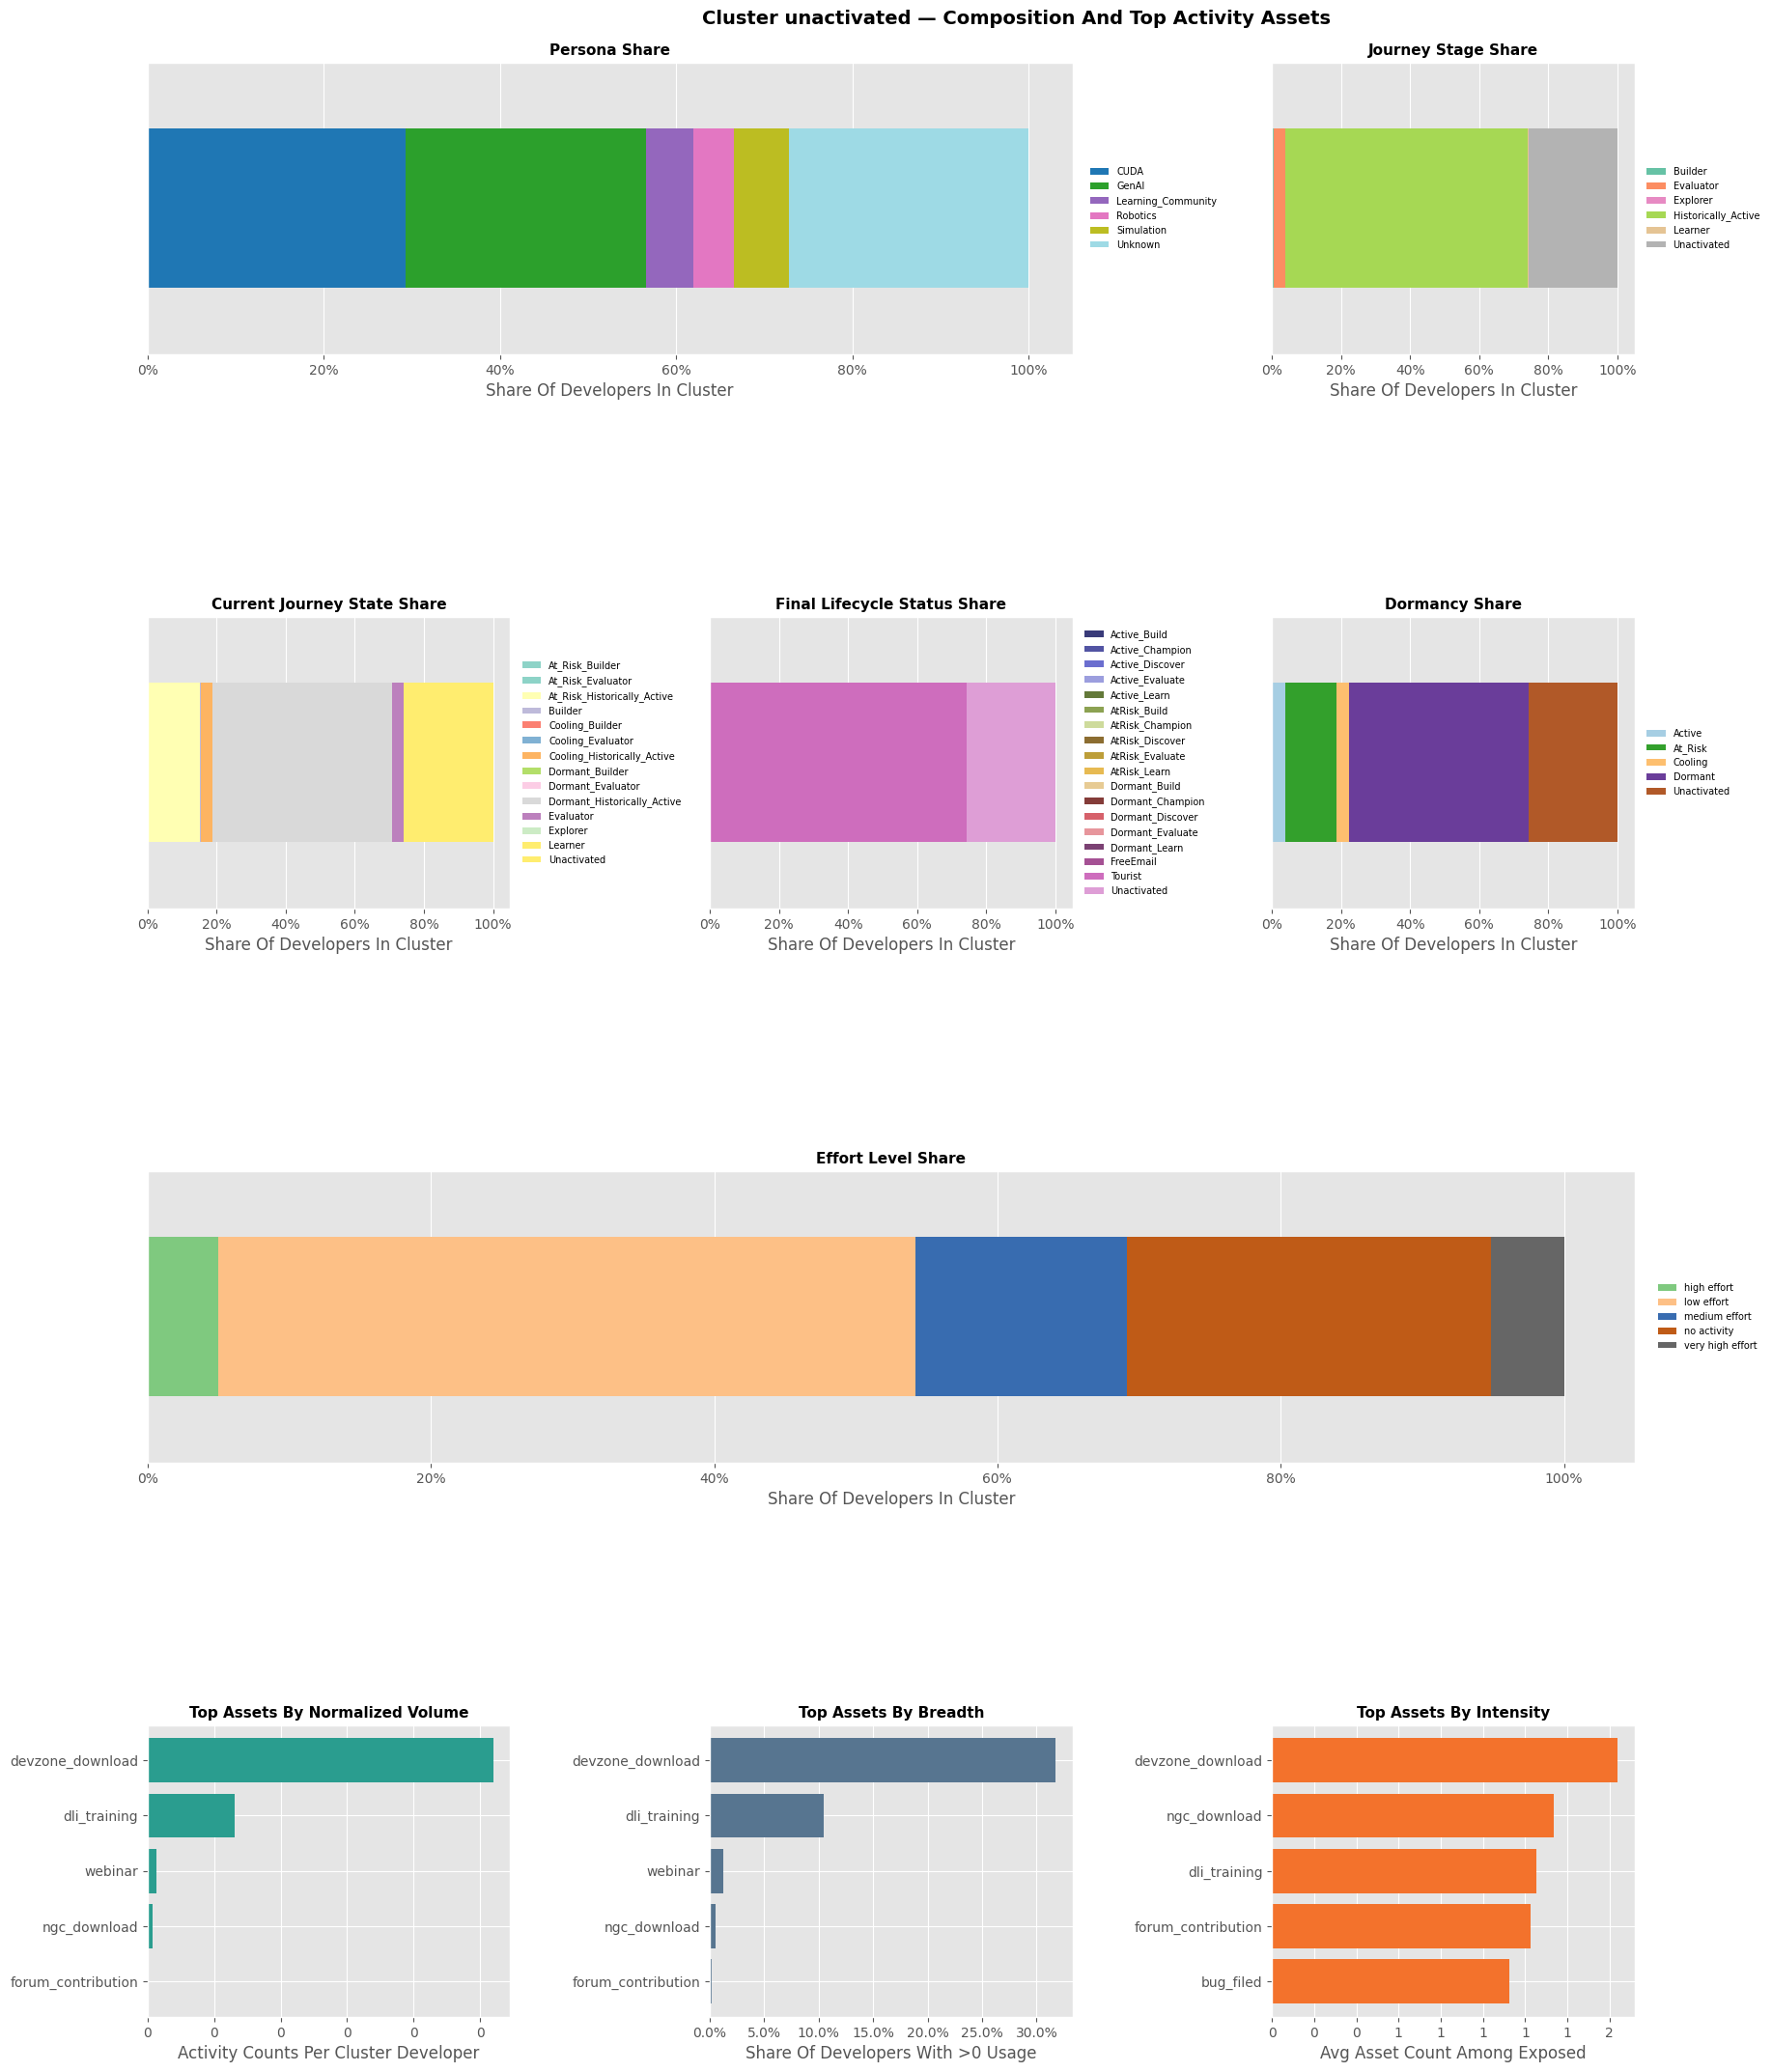

### Cluster: `dormant_low_effort_lapsed` (858,704 developers)

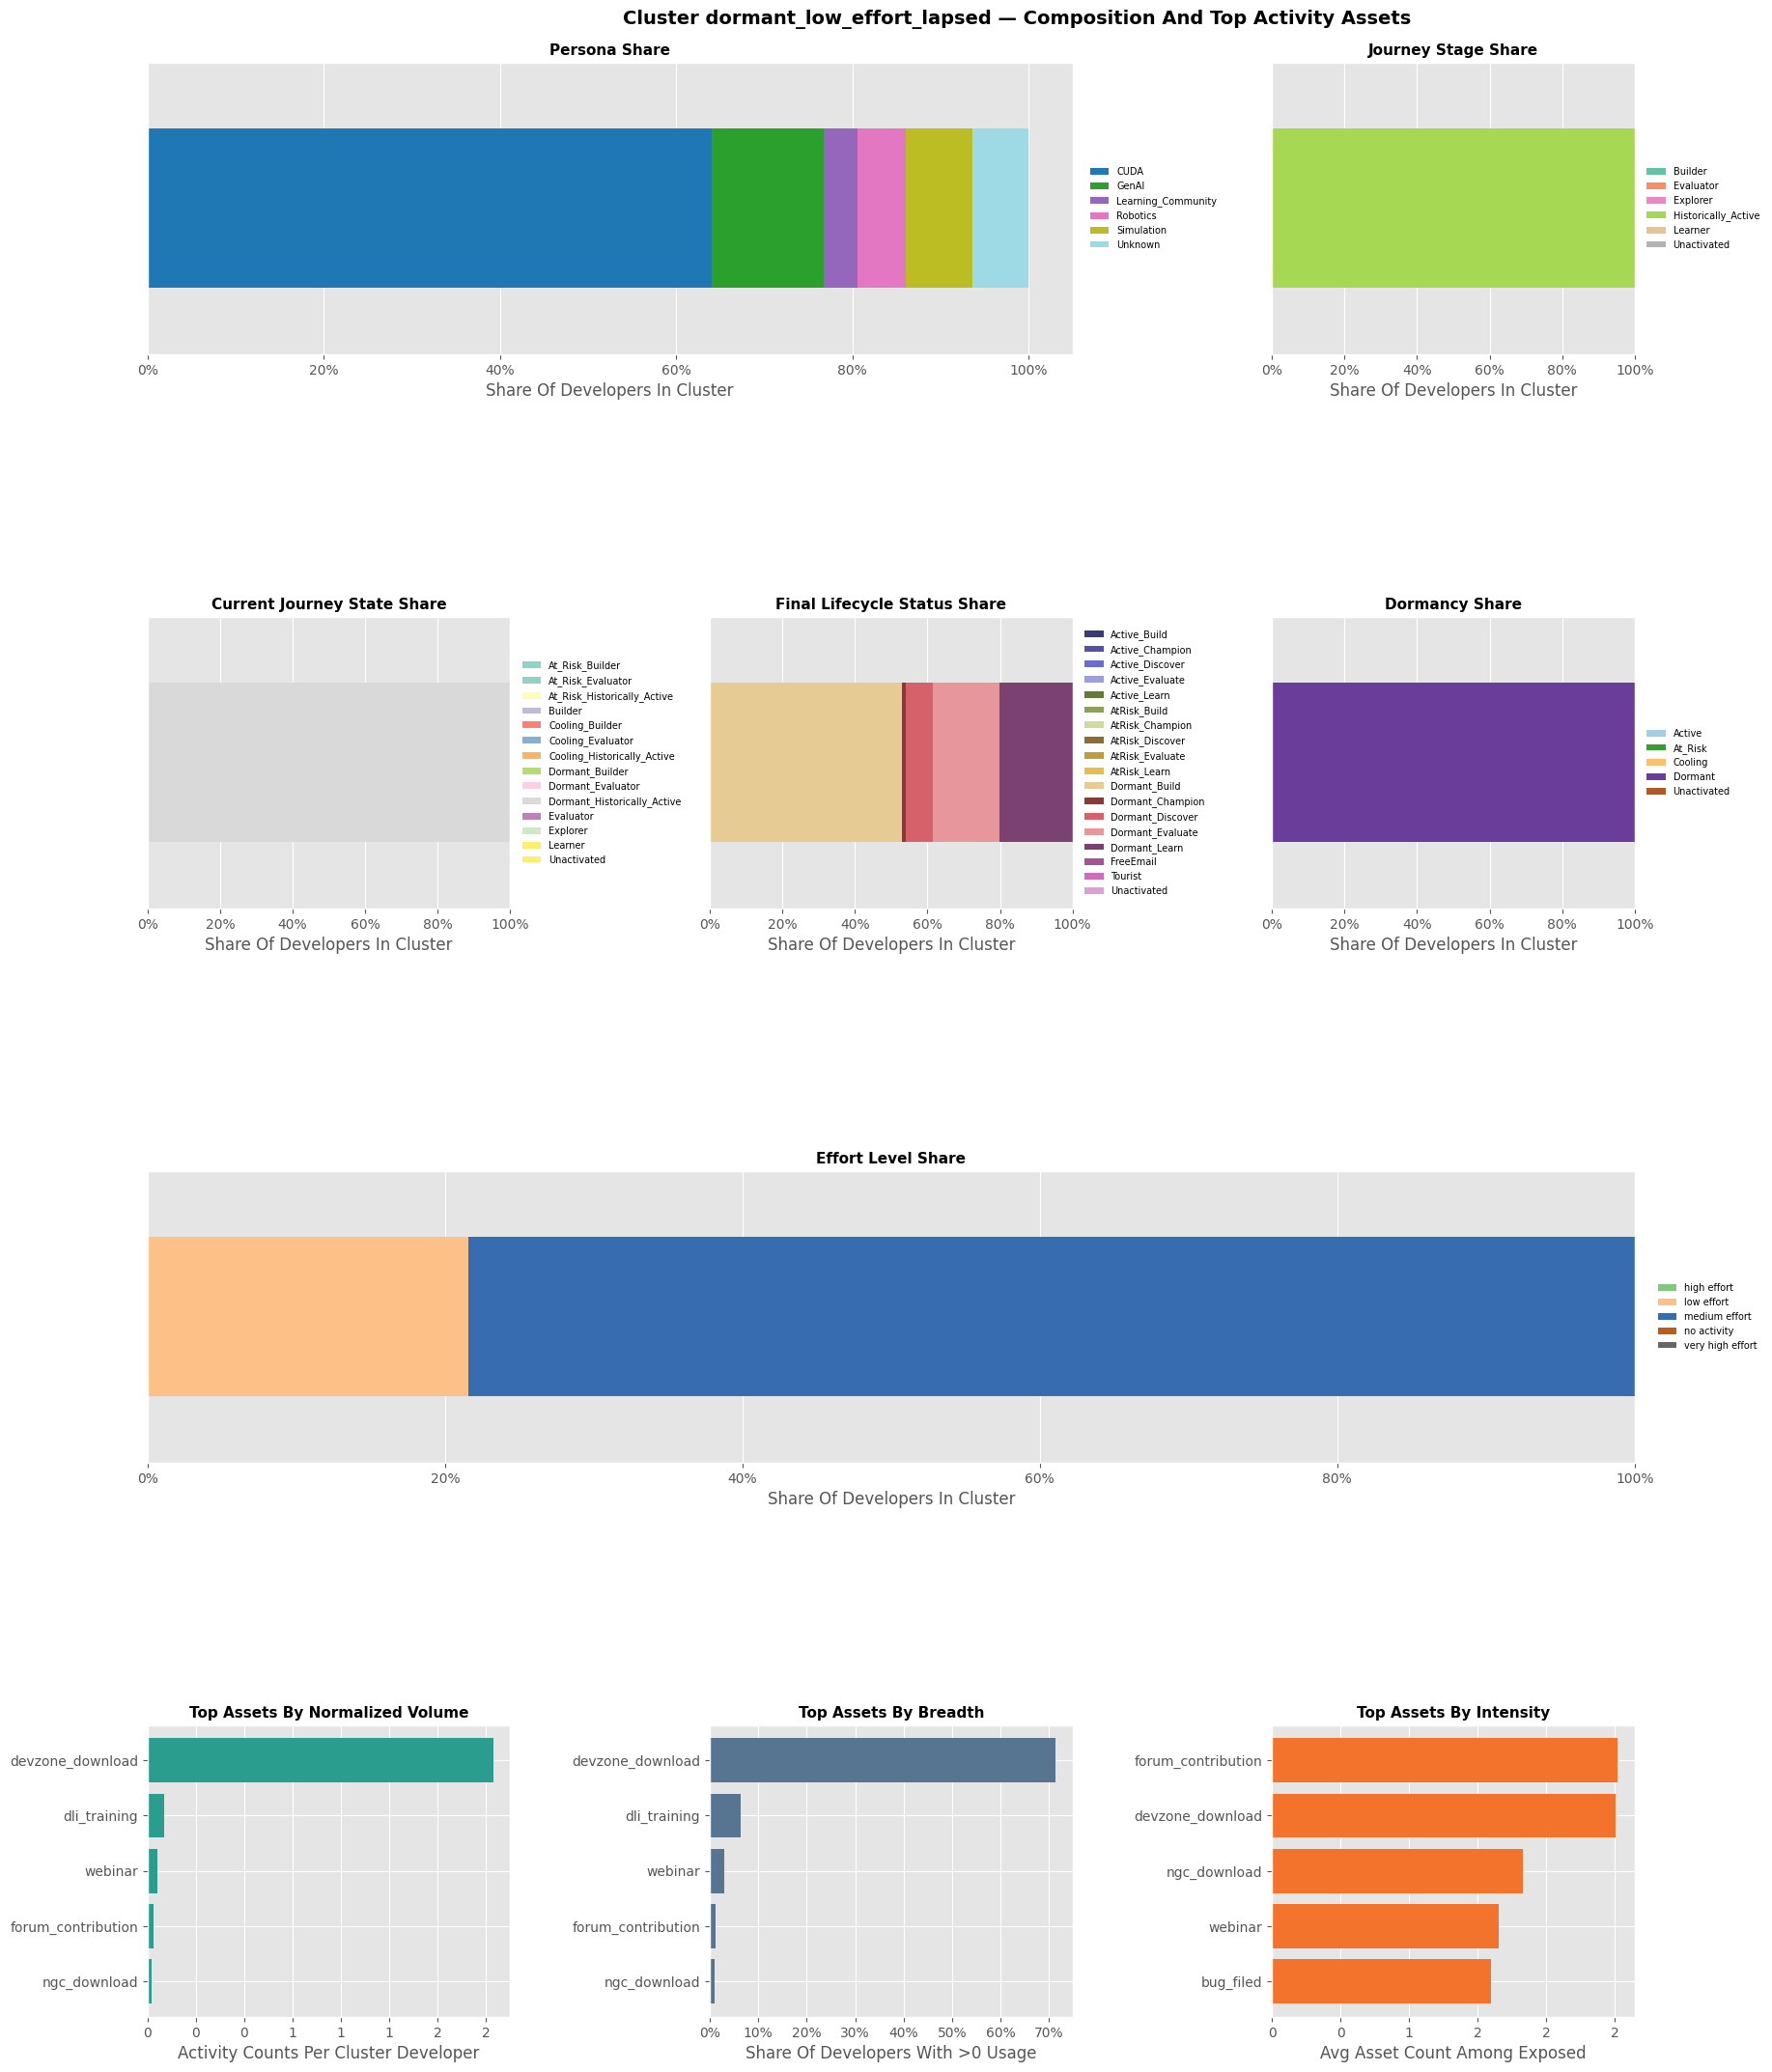

### Cluster: `dormant_mid_effort_lapsed` (687,155 developers)

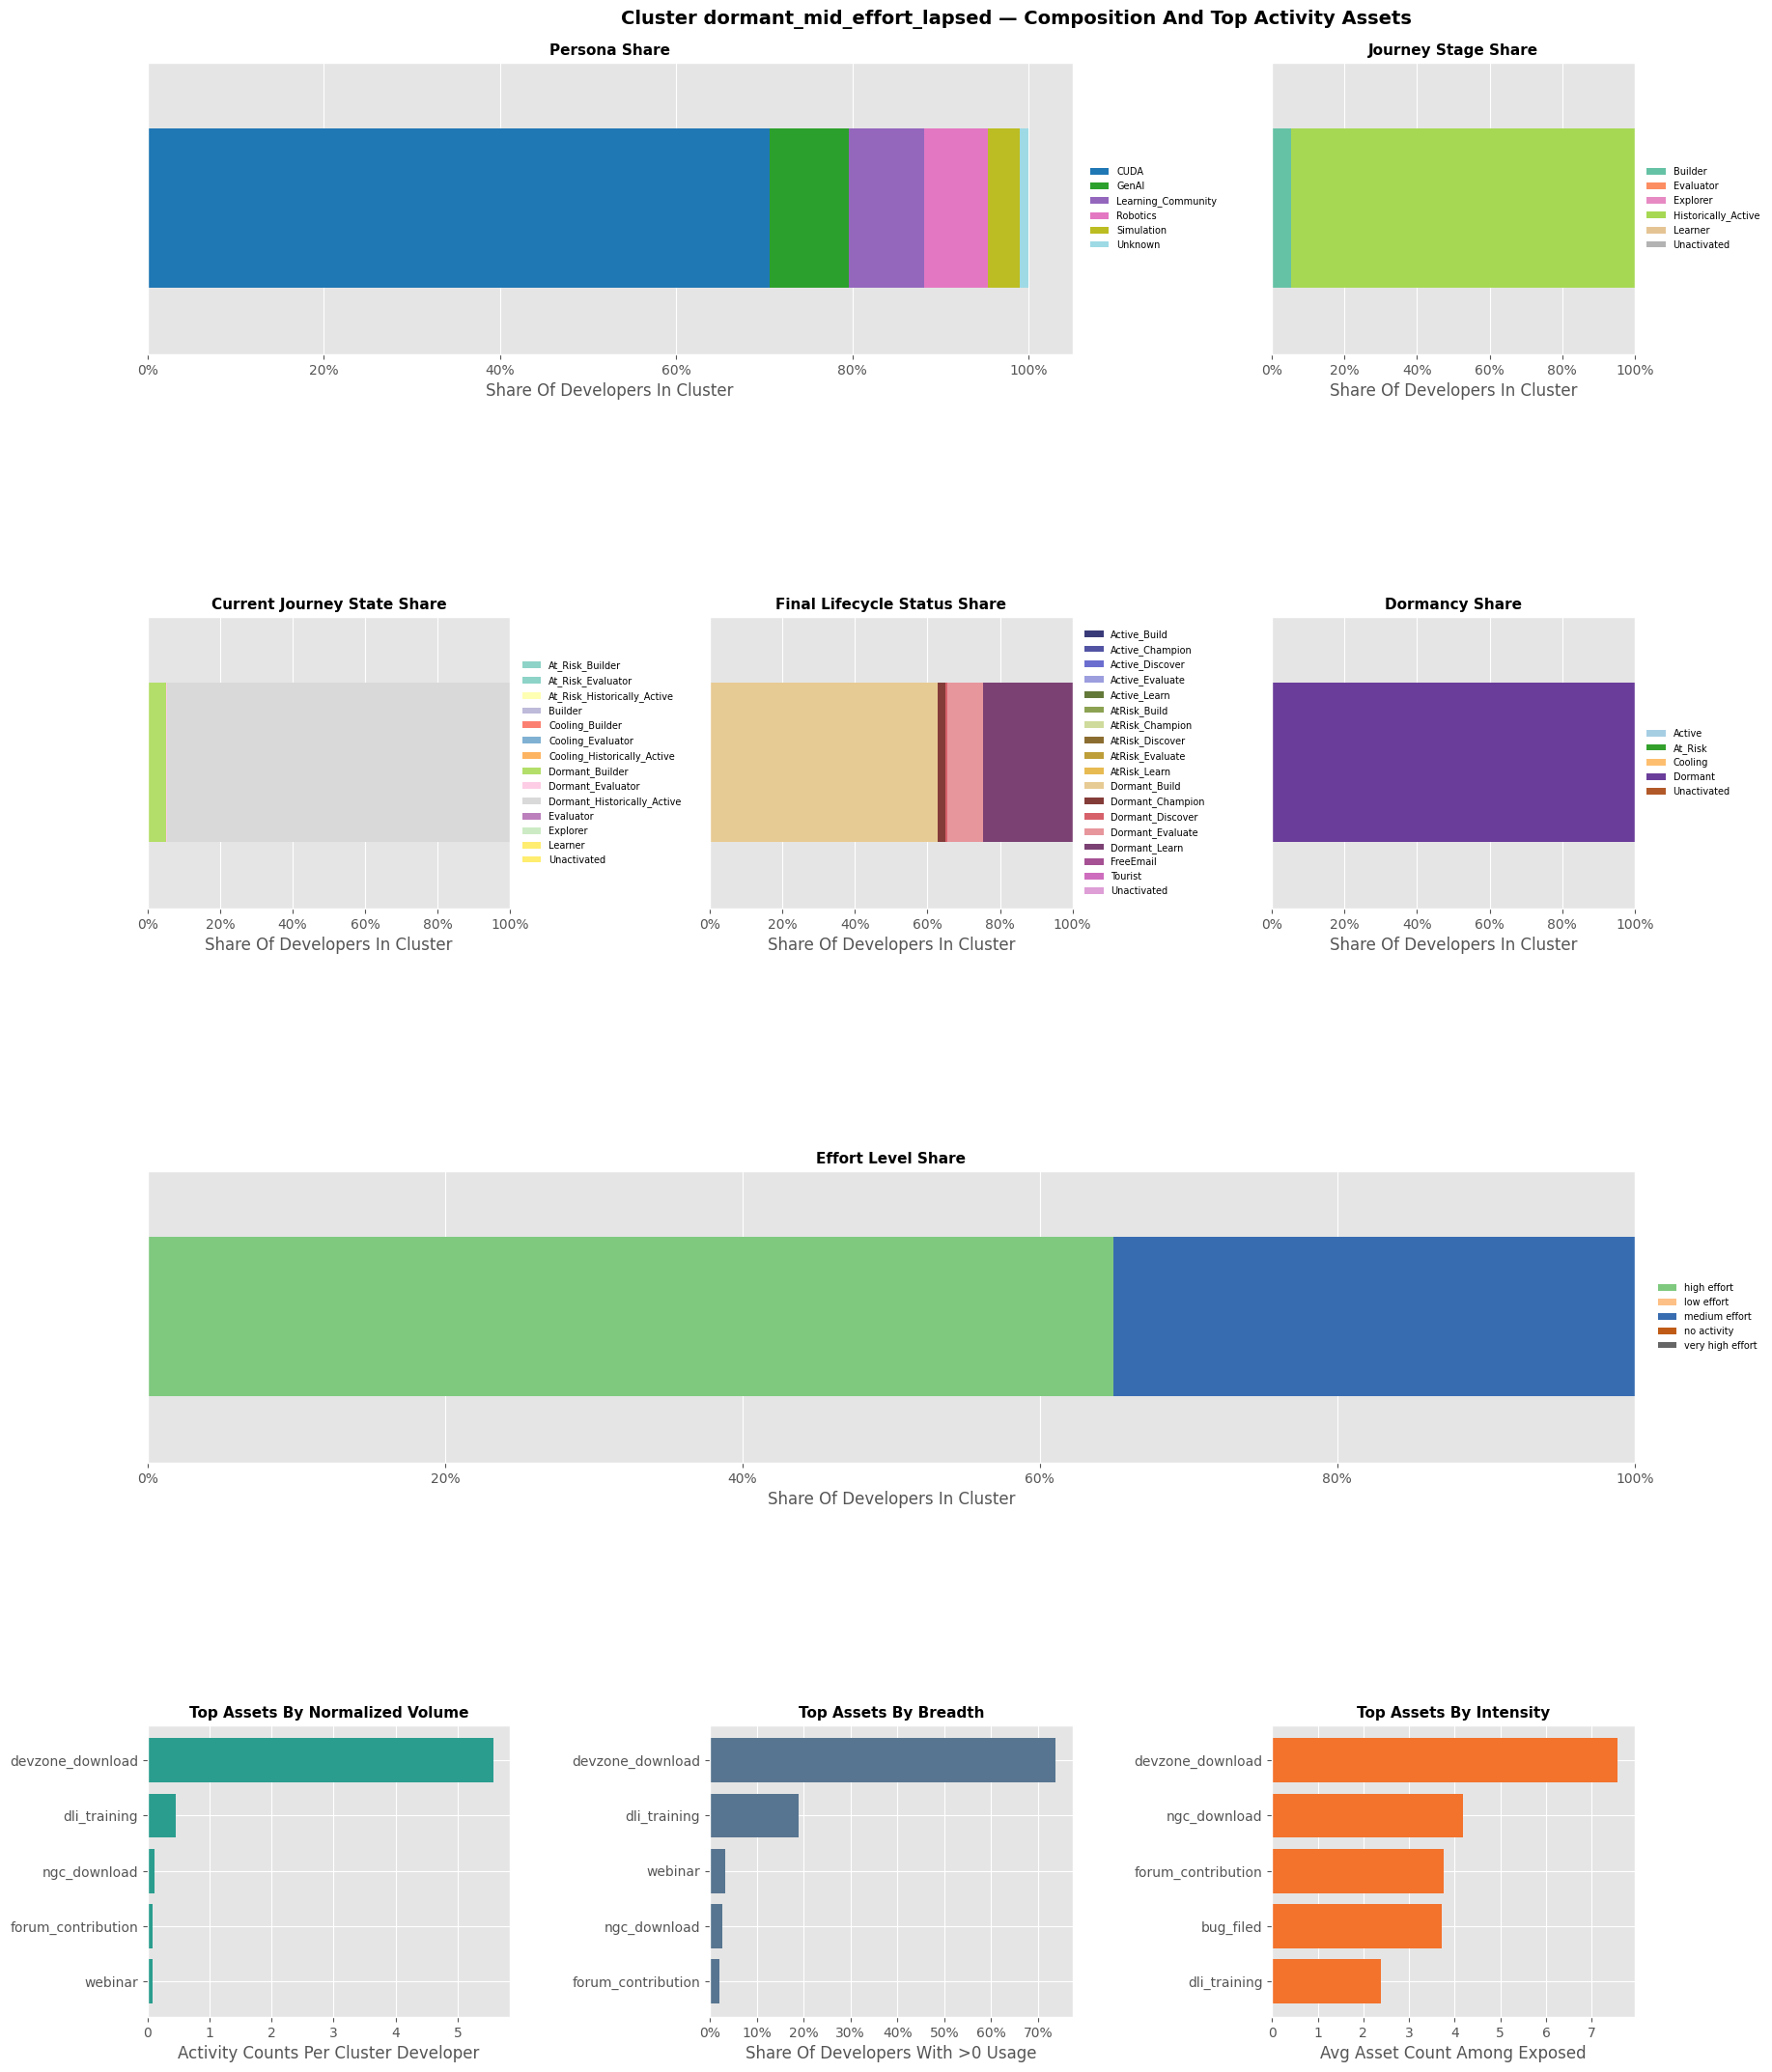

### Cluster: `active_c2` (272,713 developers)

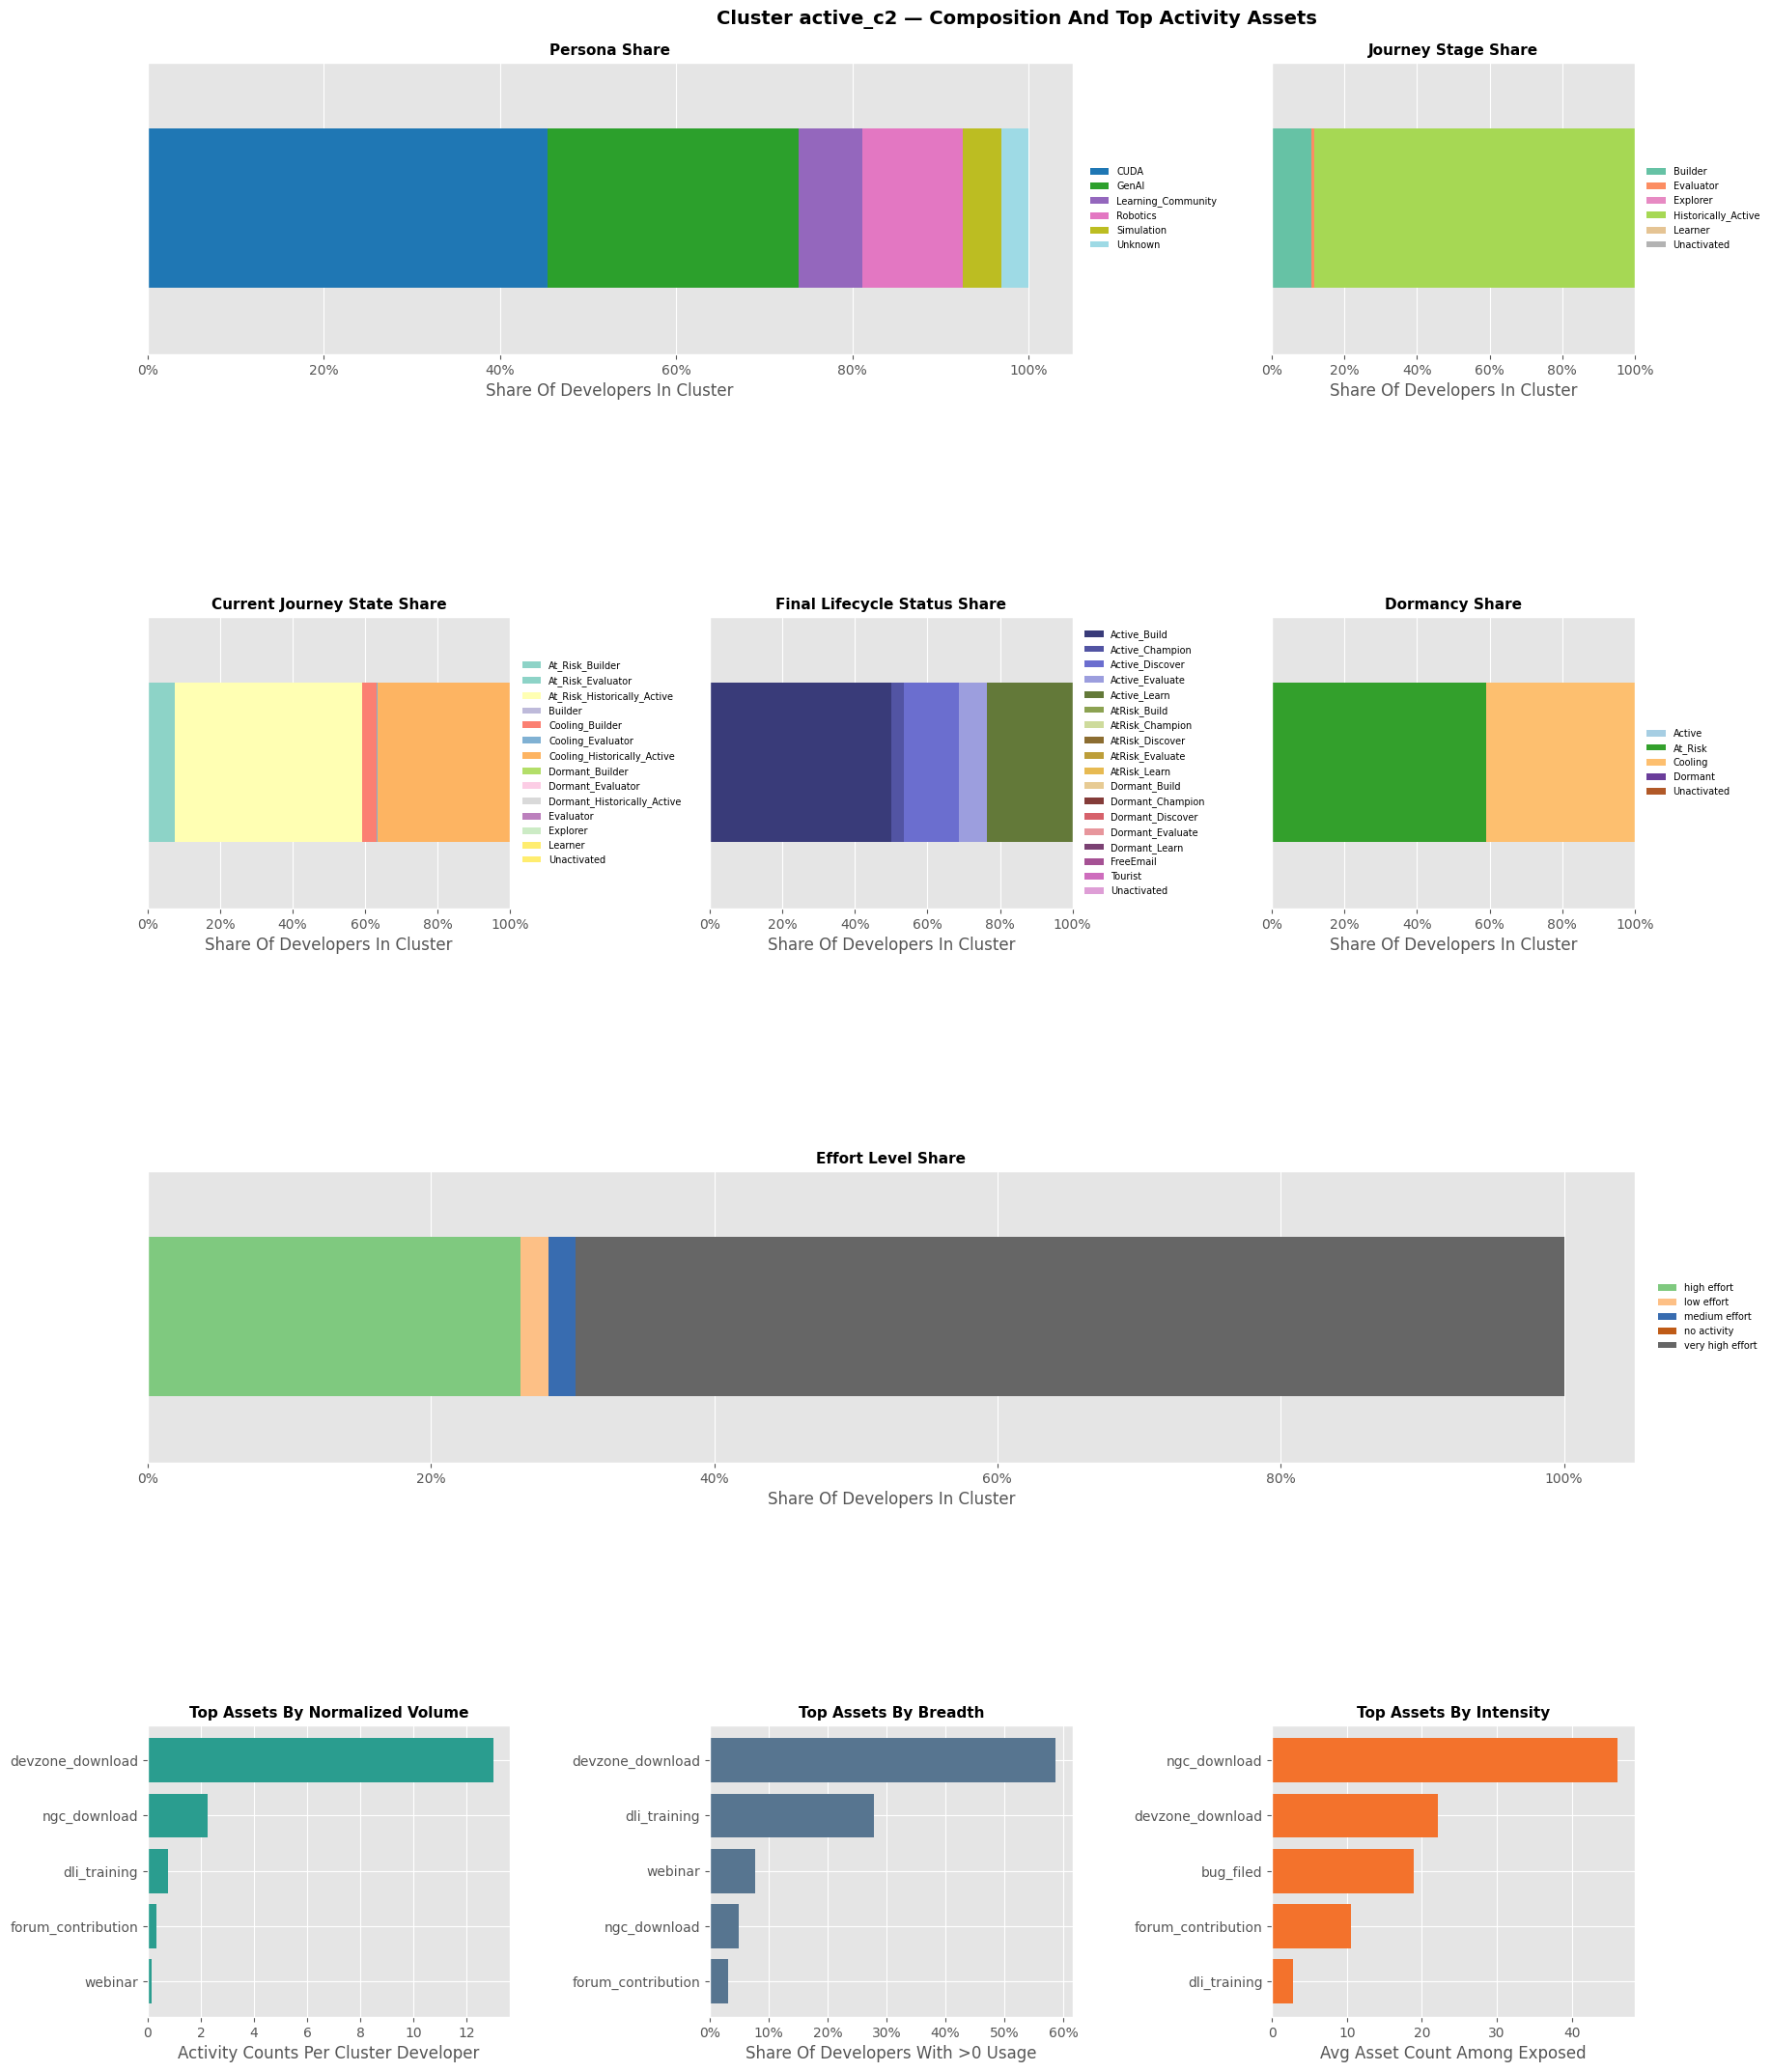

### Cluster: `at_risk_c1` (174,528 developers)

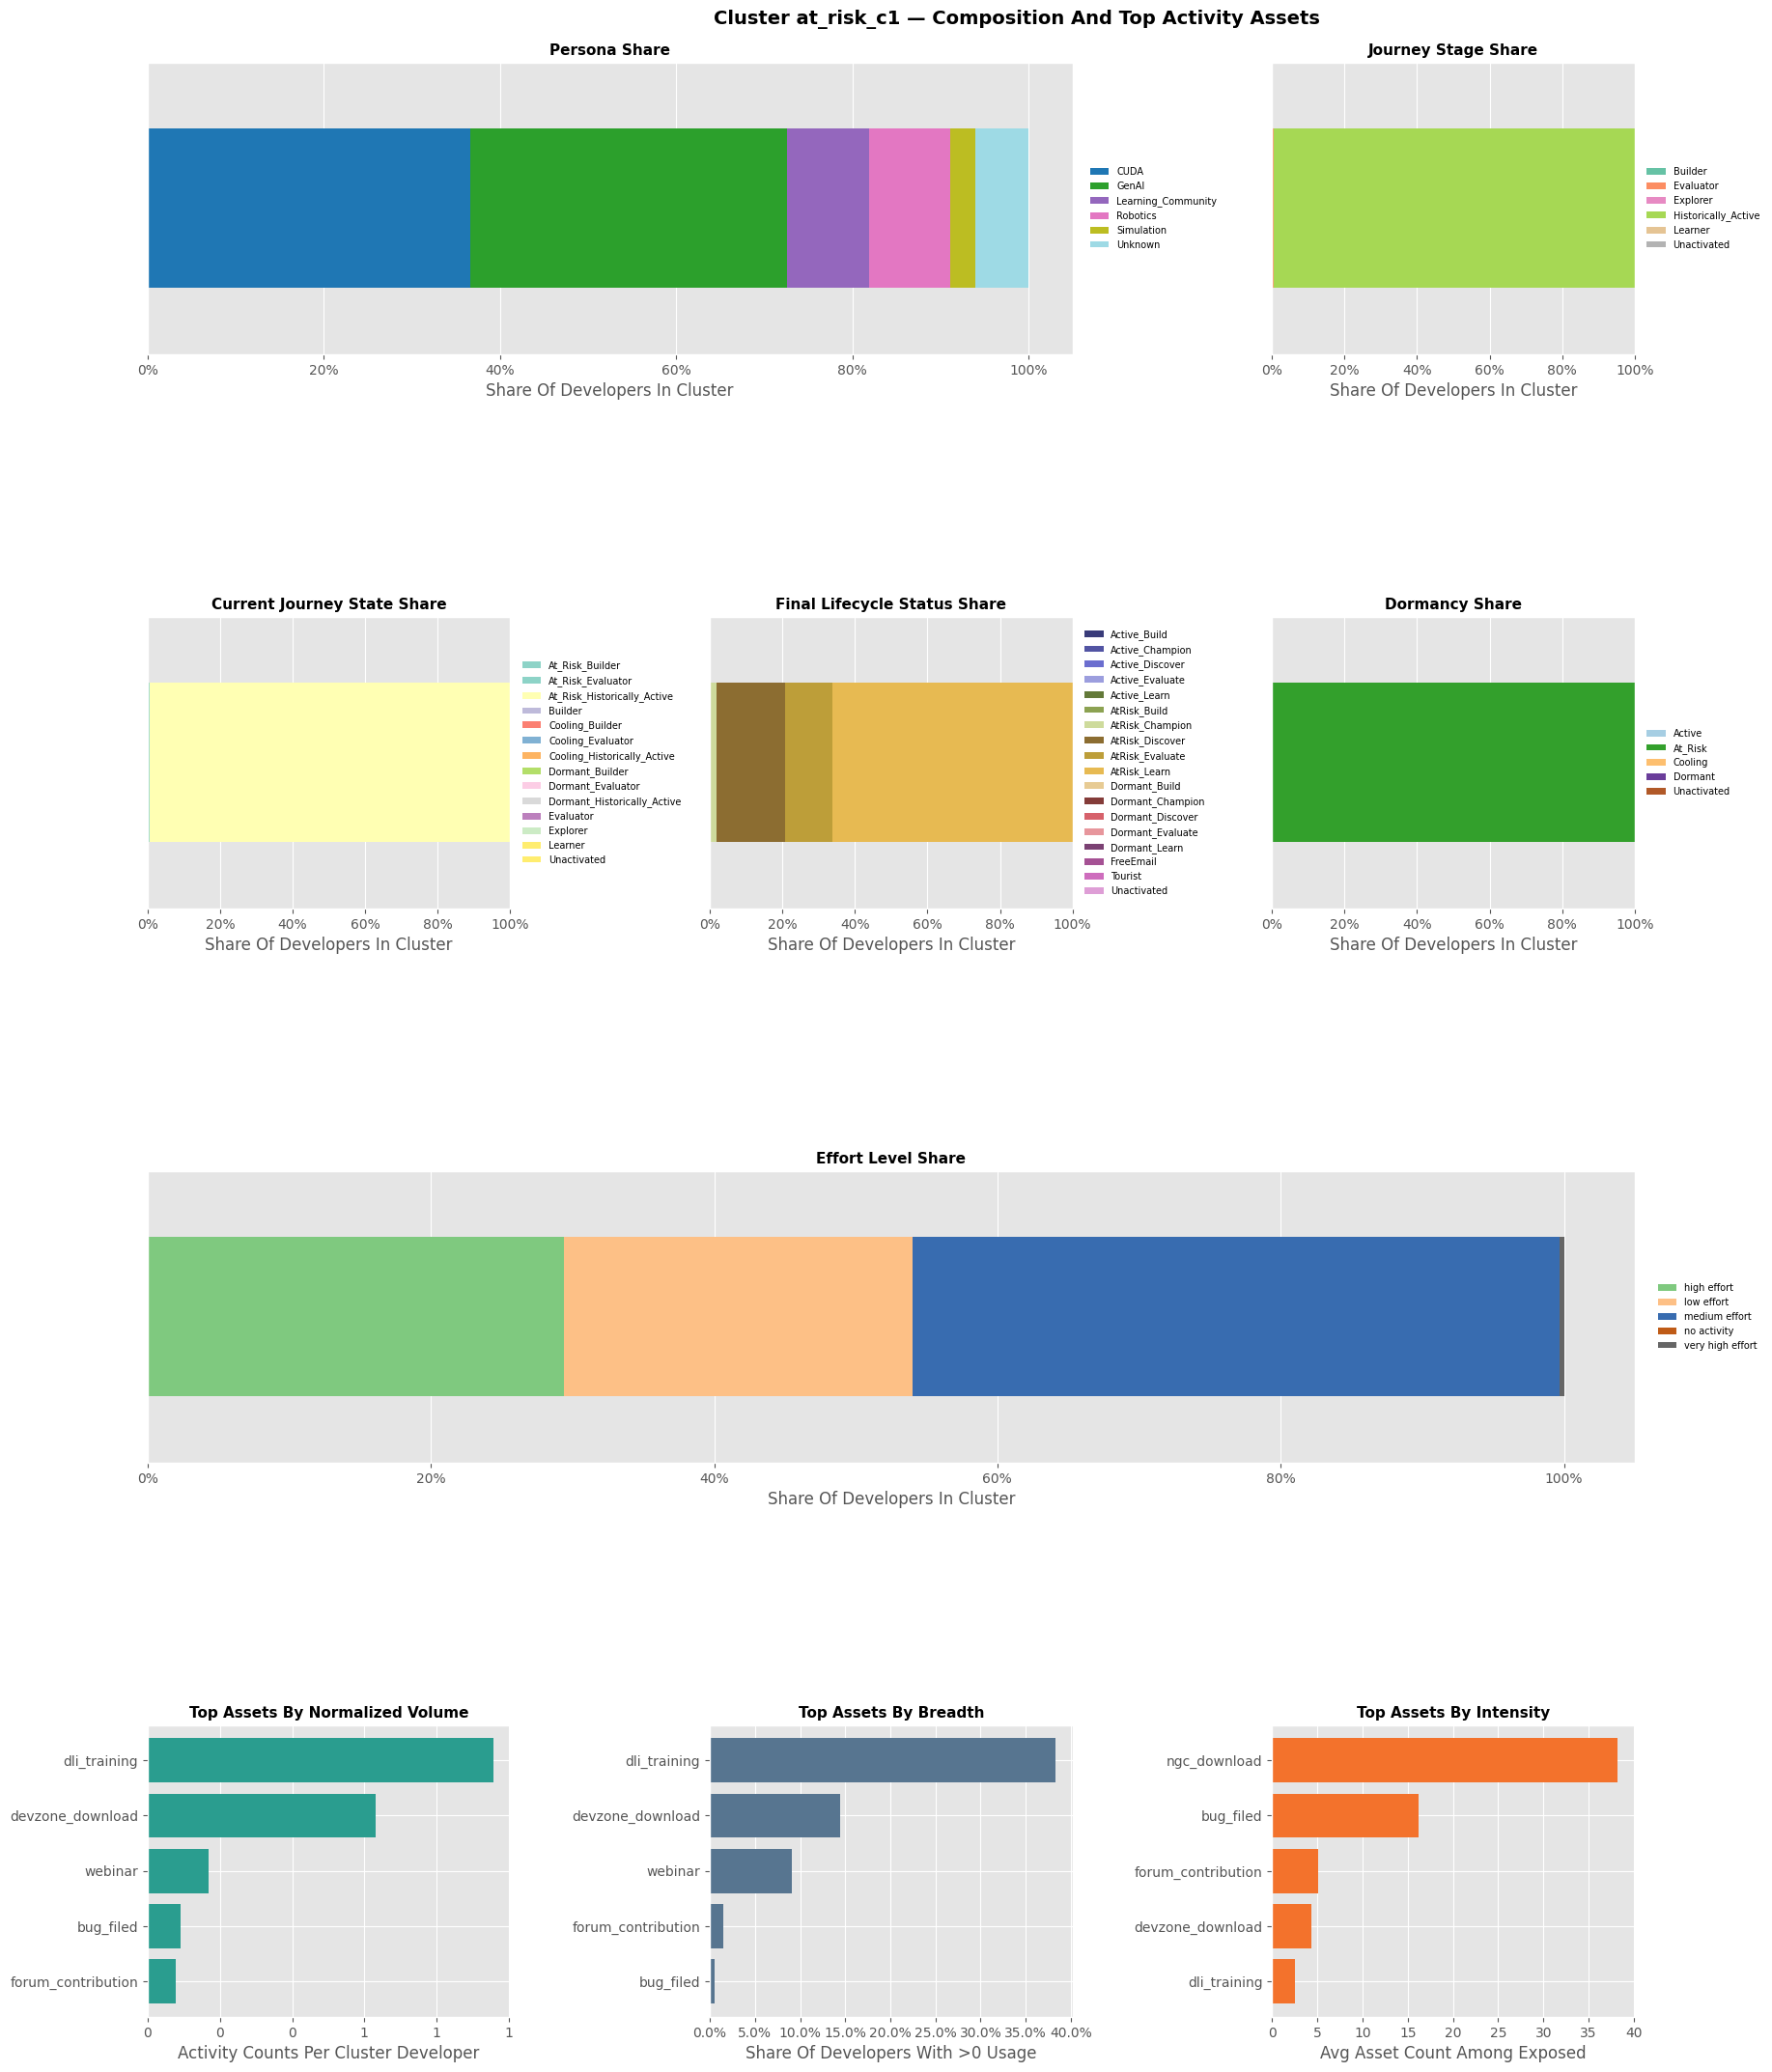

### Cluster: `at_risk_c0` (117,555 developers)

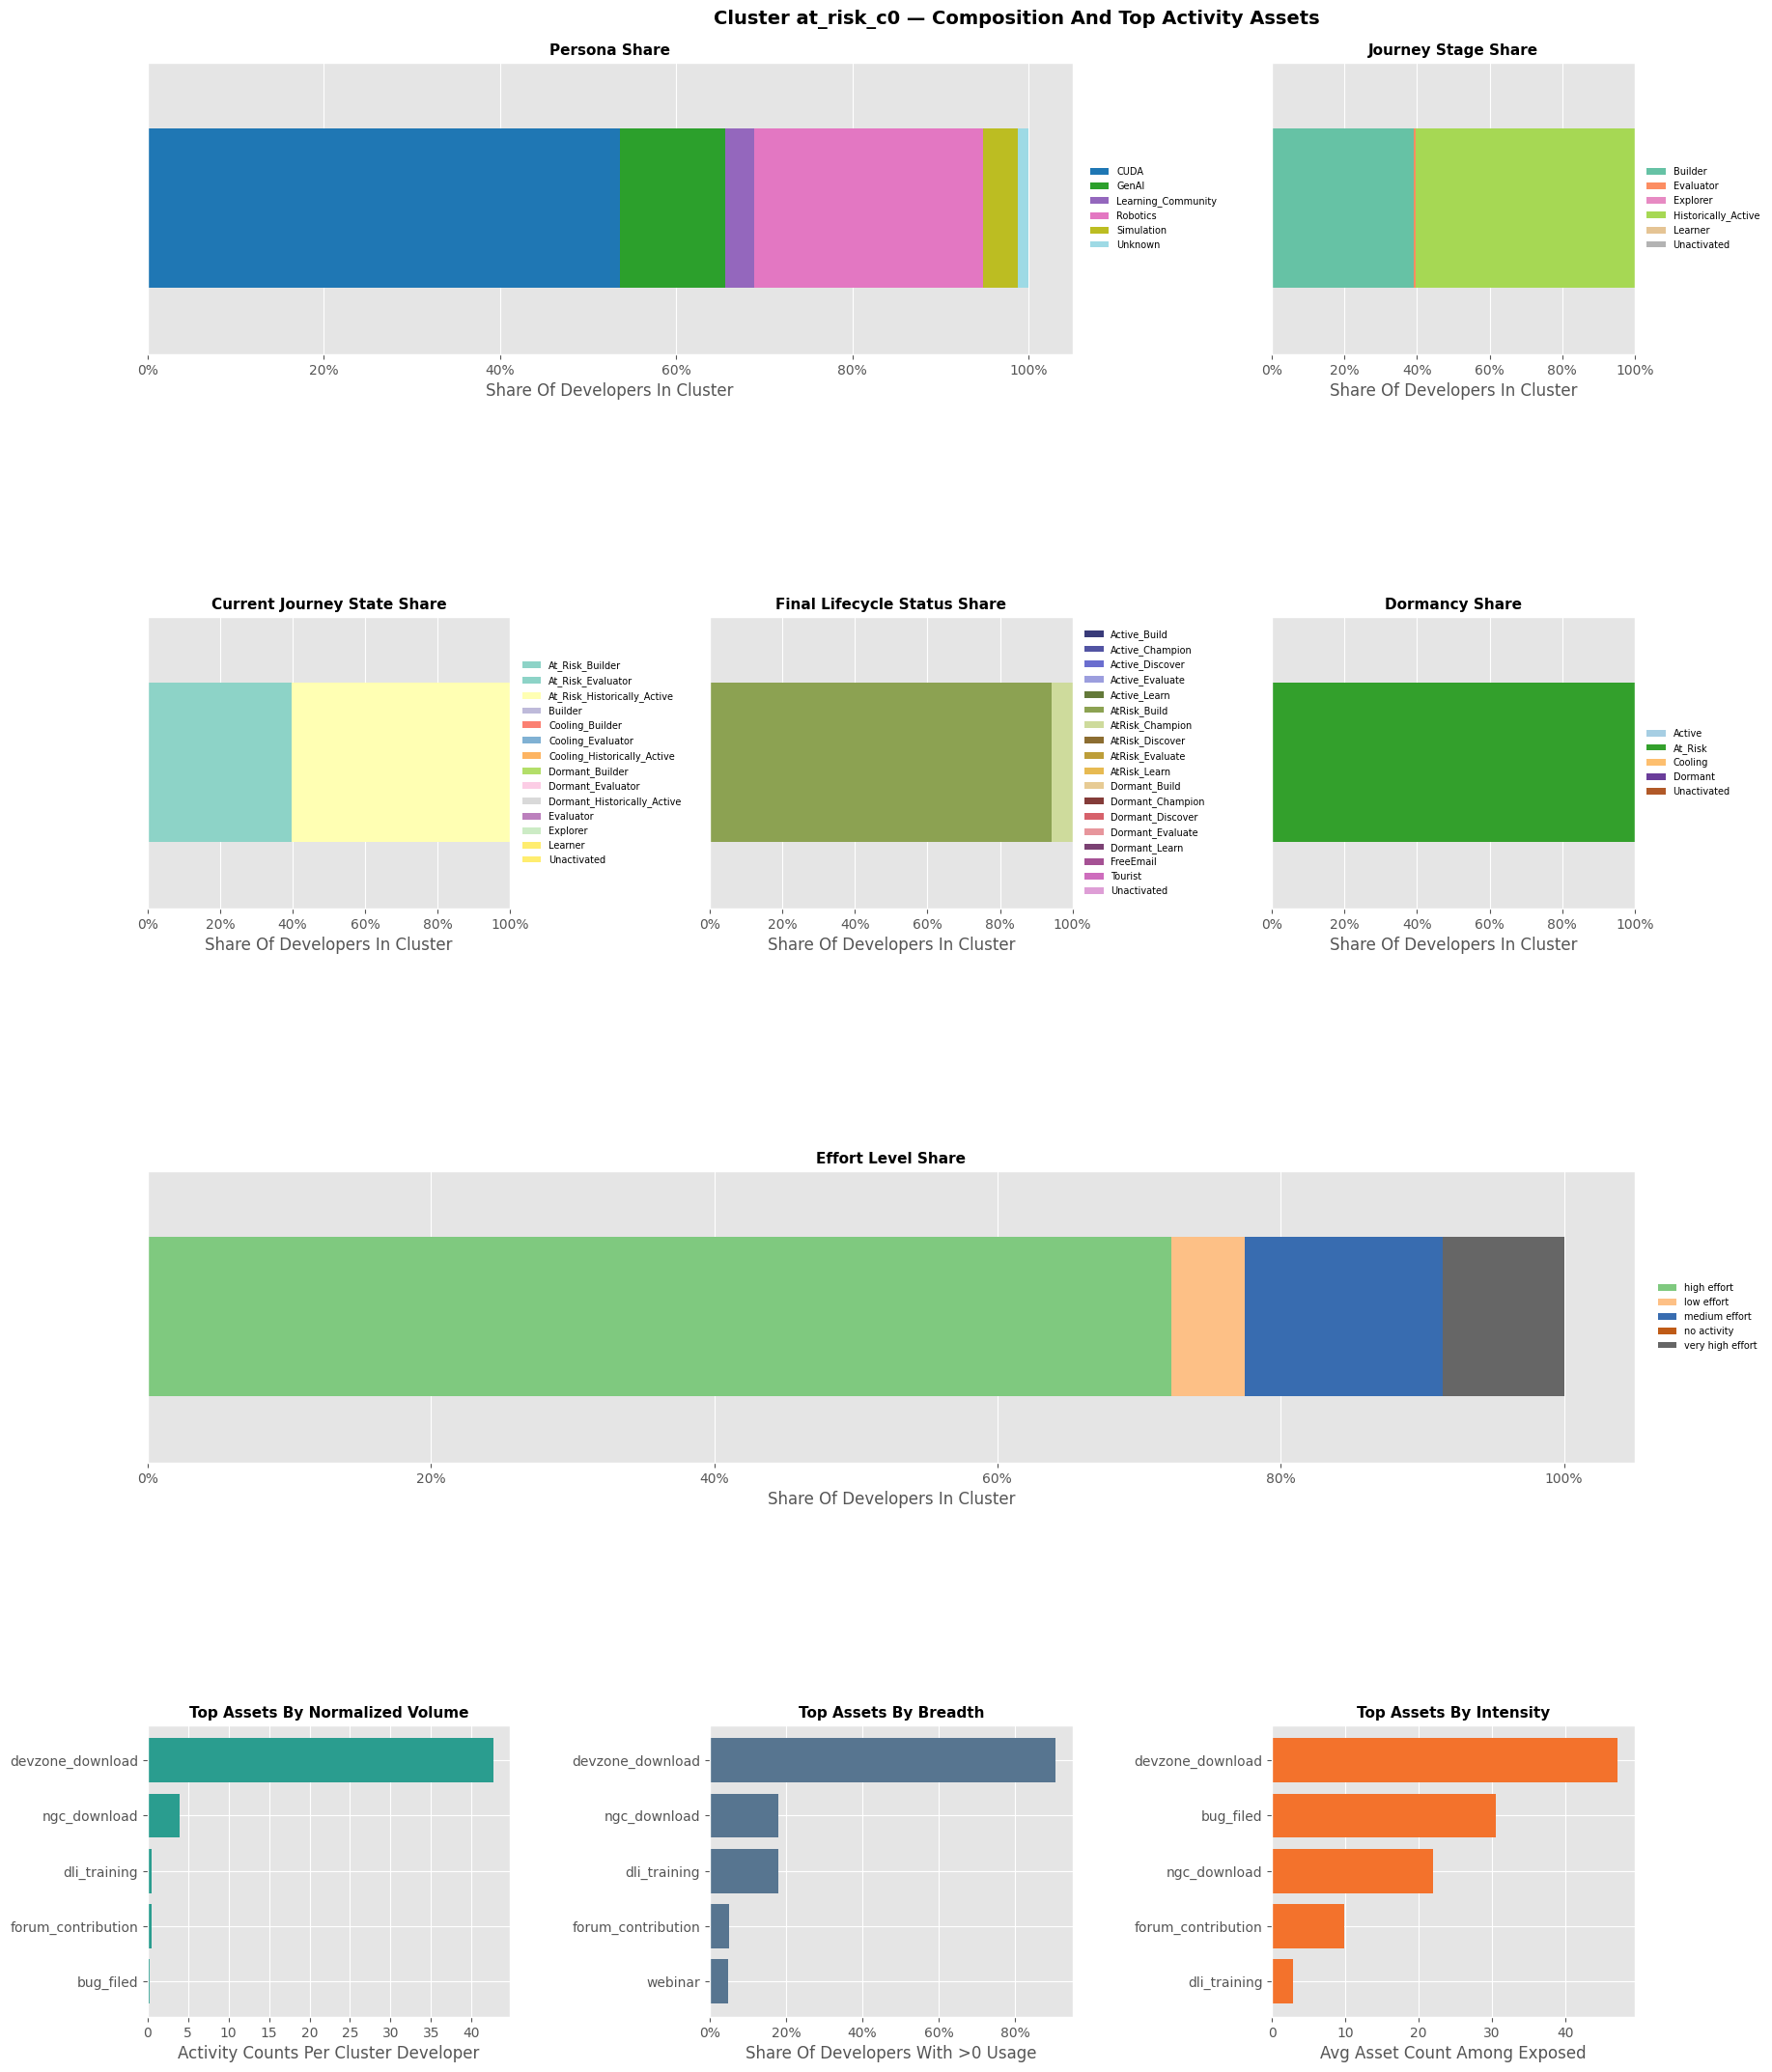

### Cluster: `unknown` (109,622 developers)

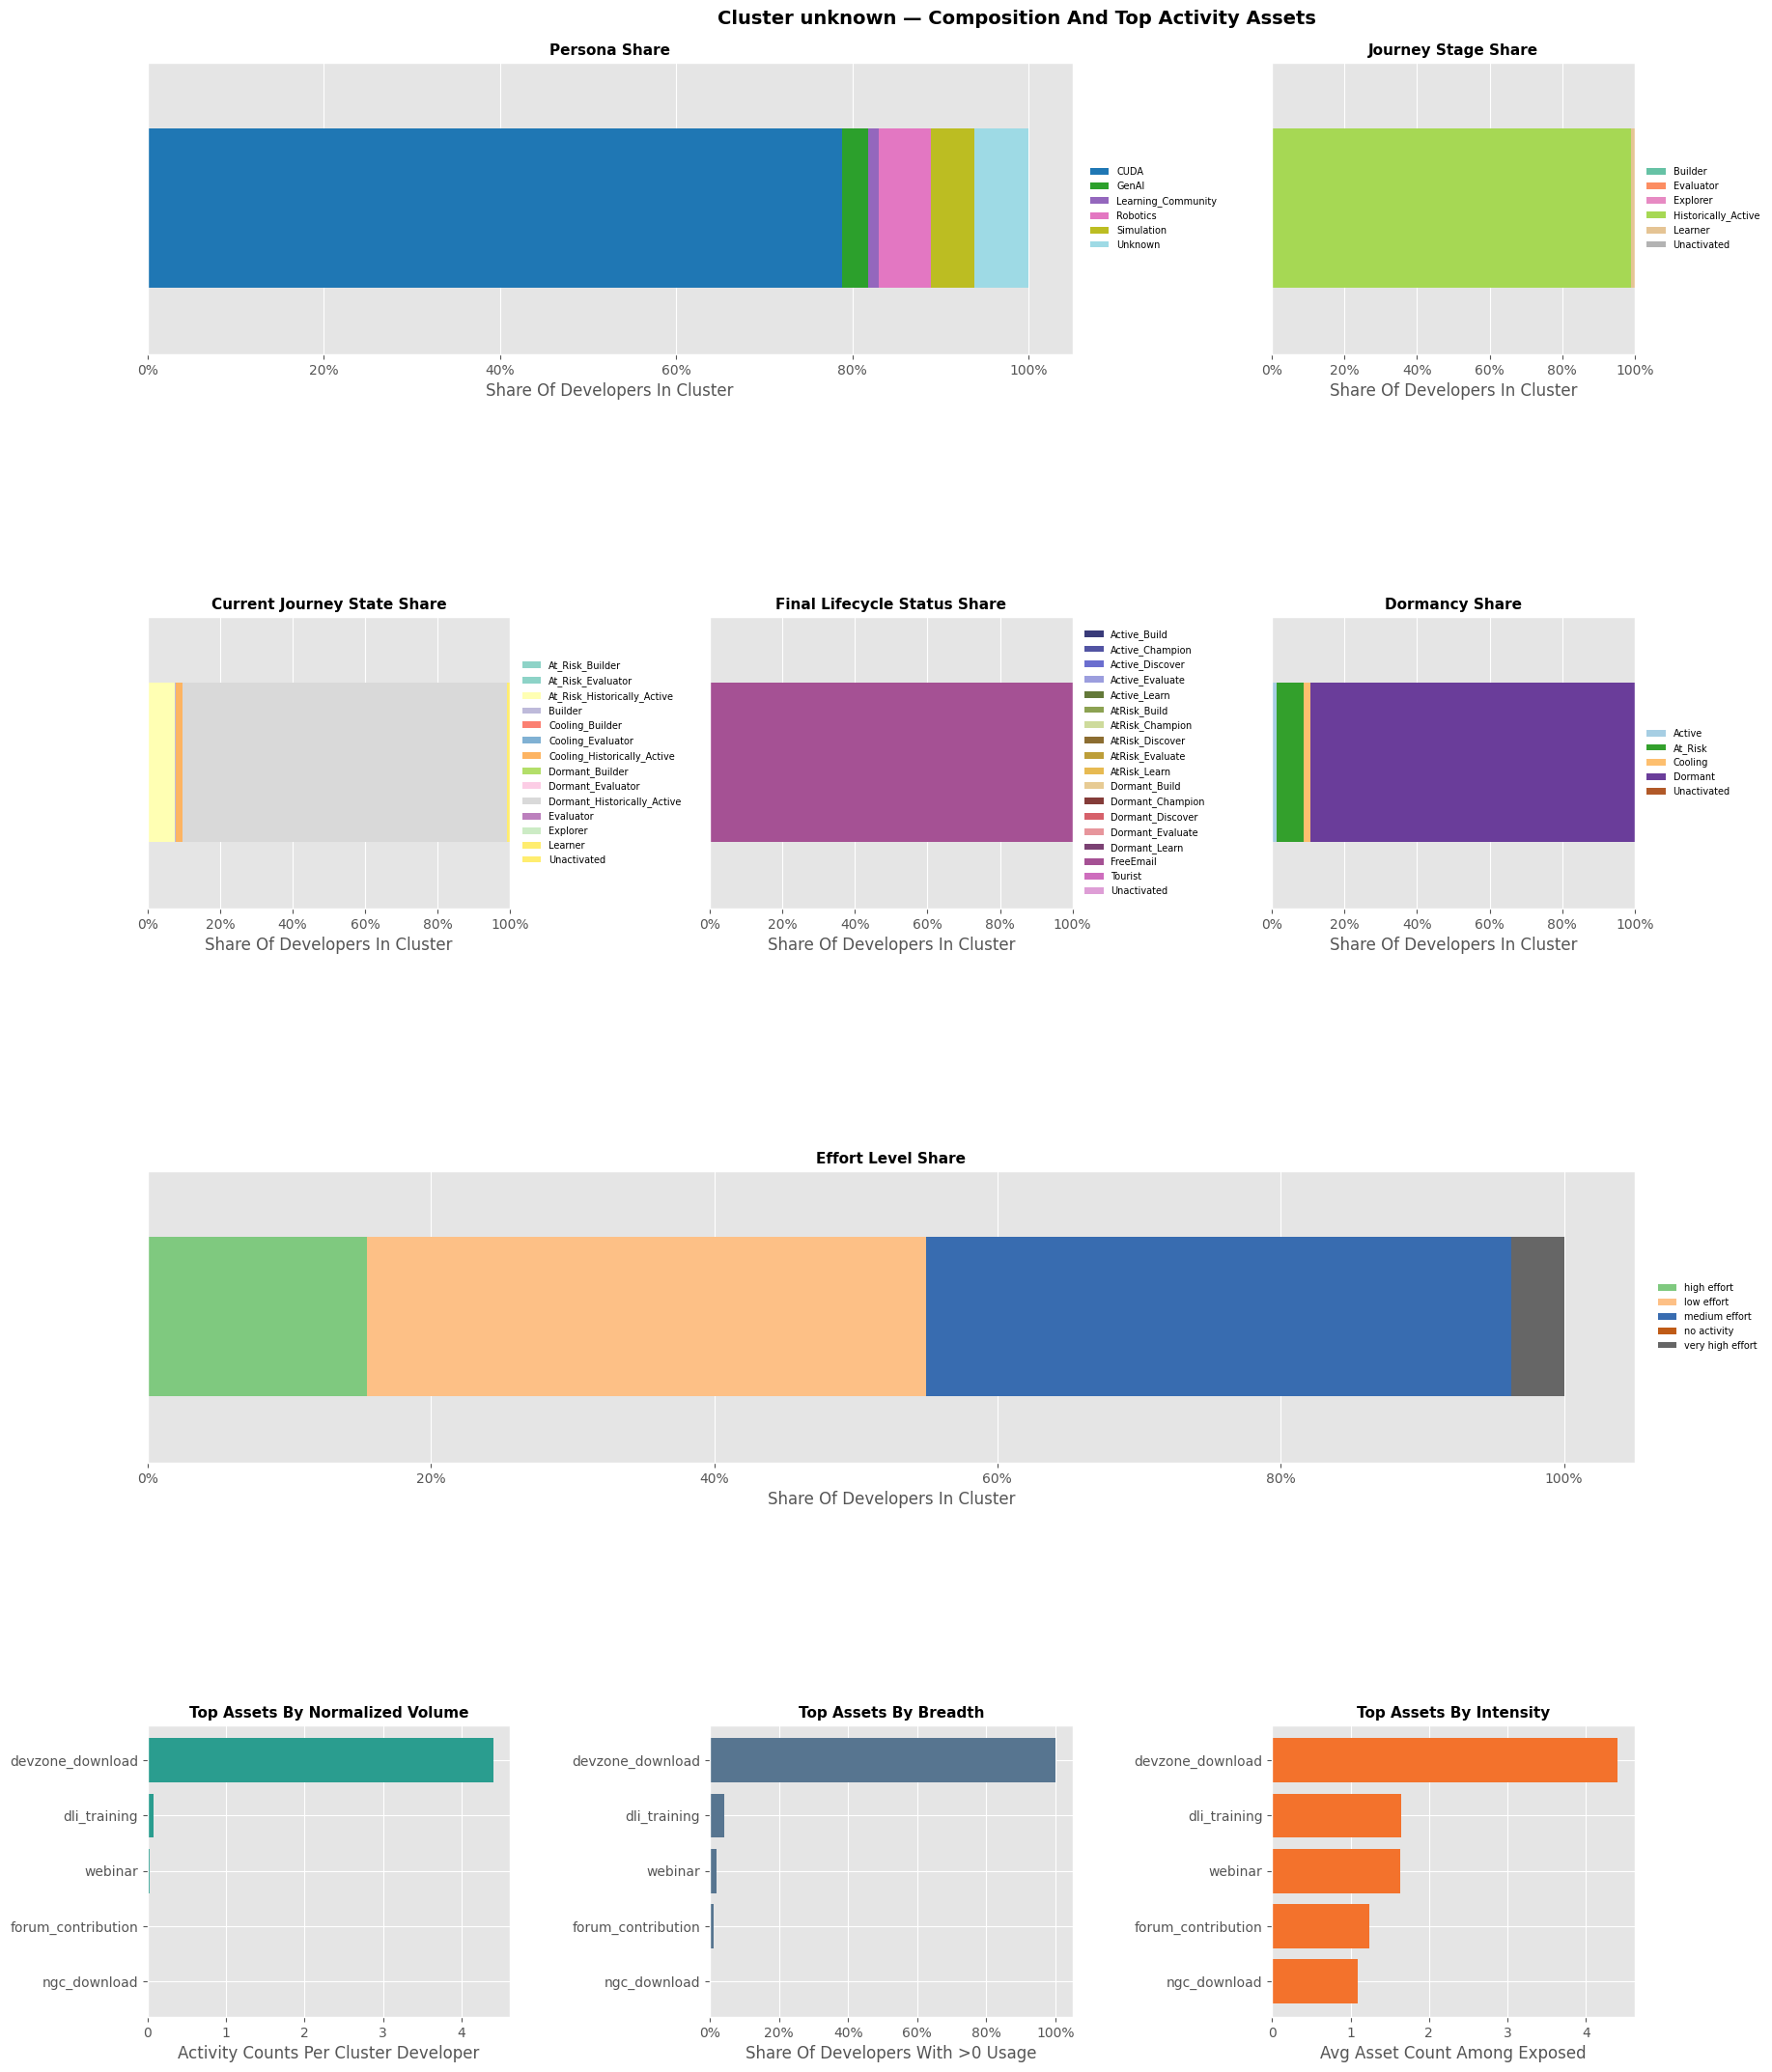

### Cluster: `at_risk_c2` (101,809 developers)

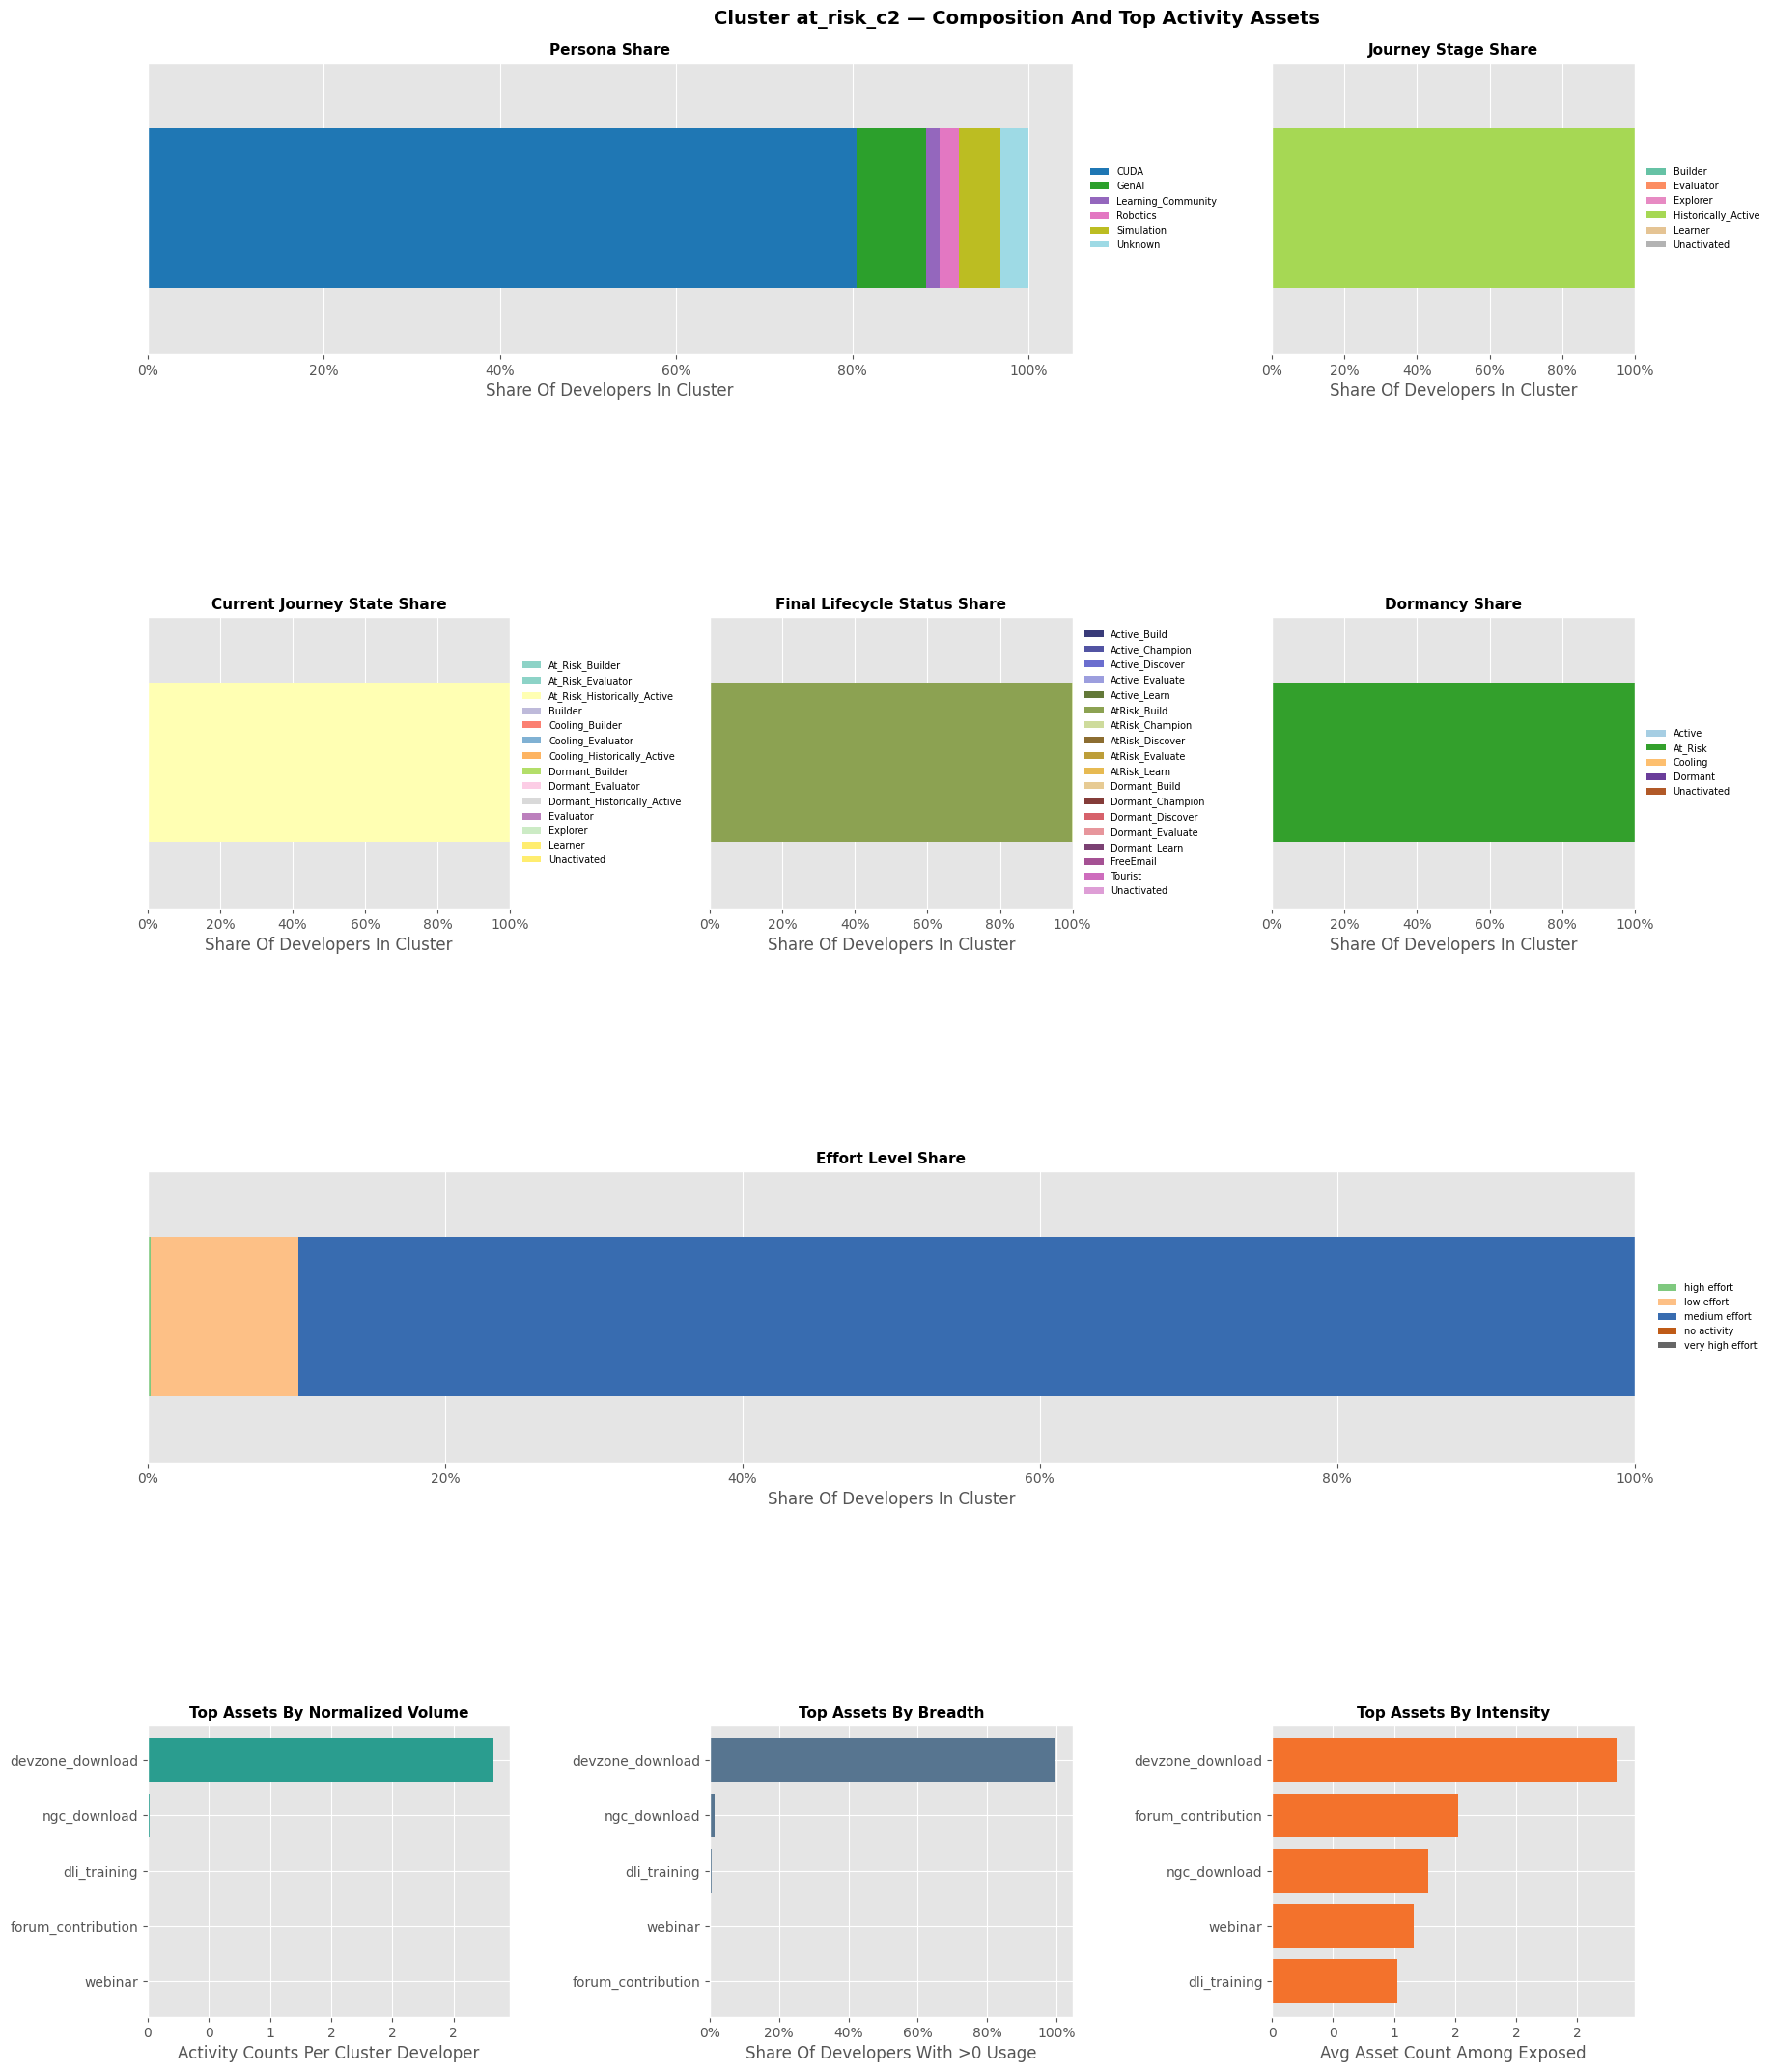

### Cluster: `dormant_former_high_effort` (89,564 developers)

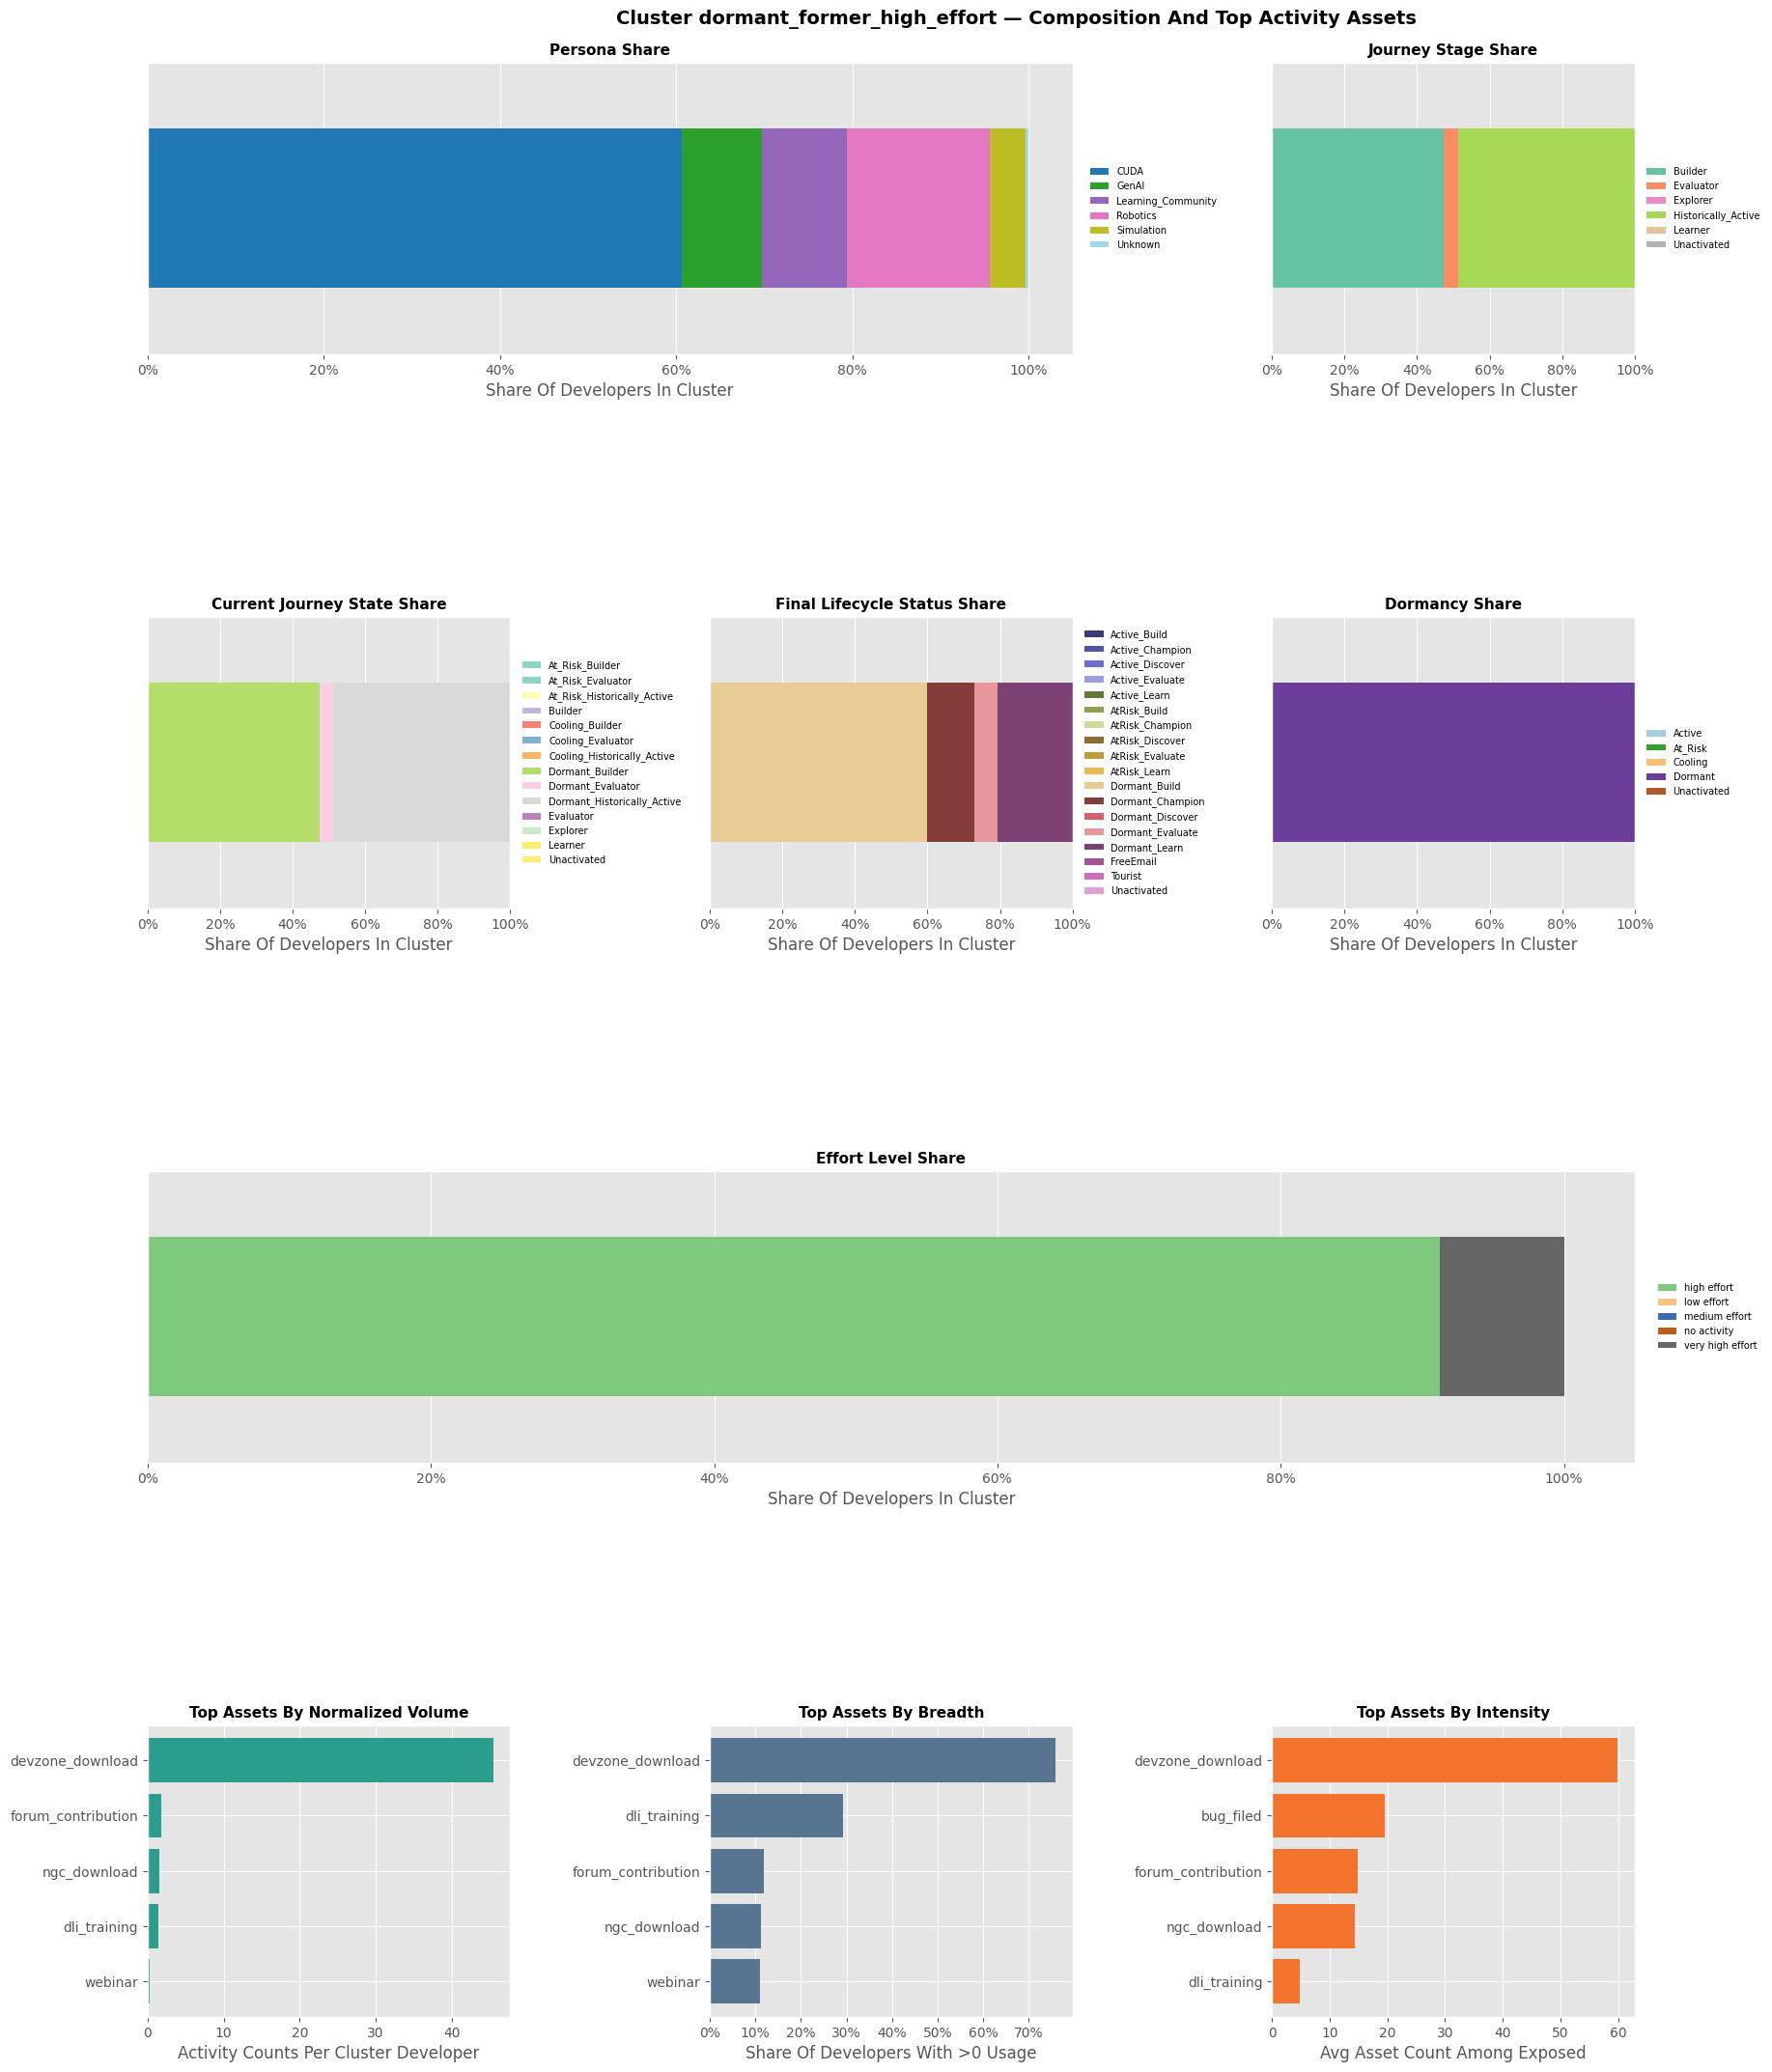

### Cluster: `dormant_former_power_builder` (82,269 developers)

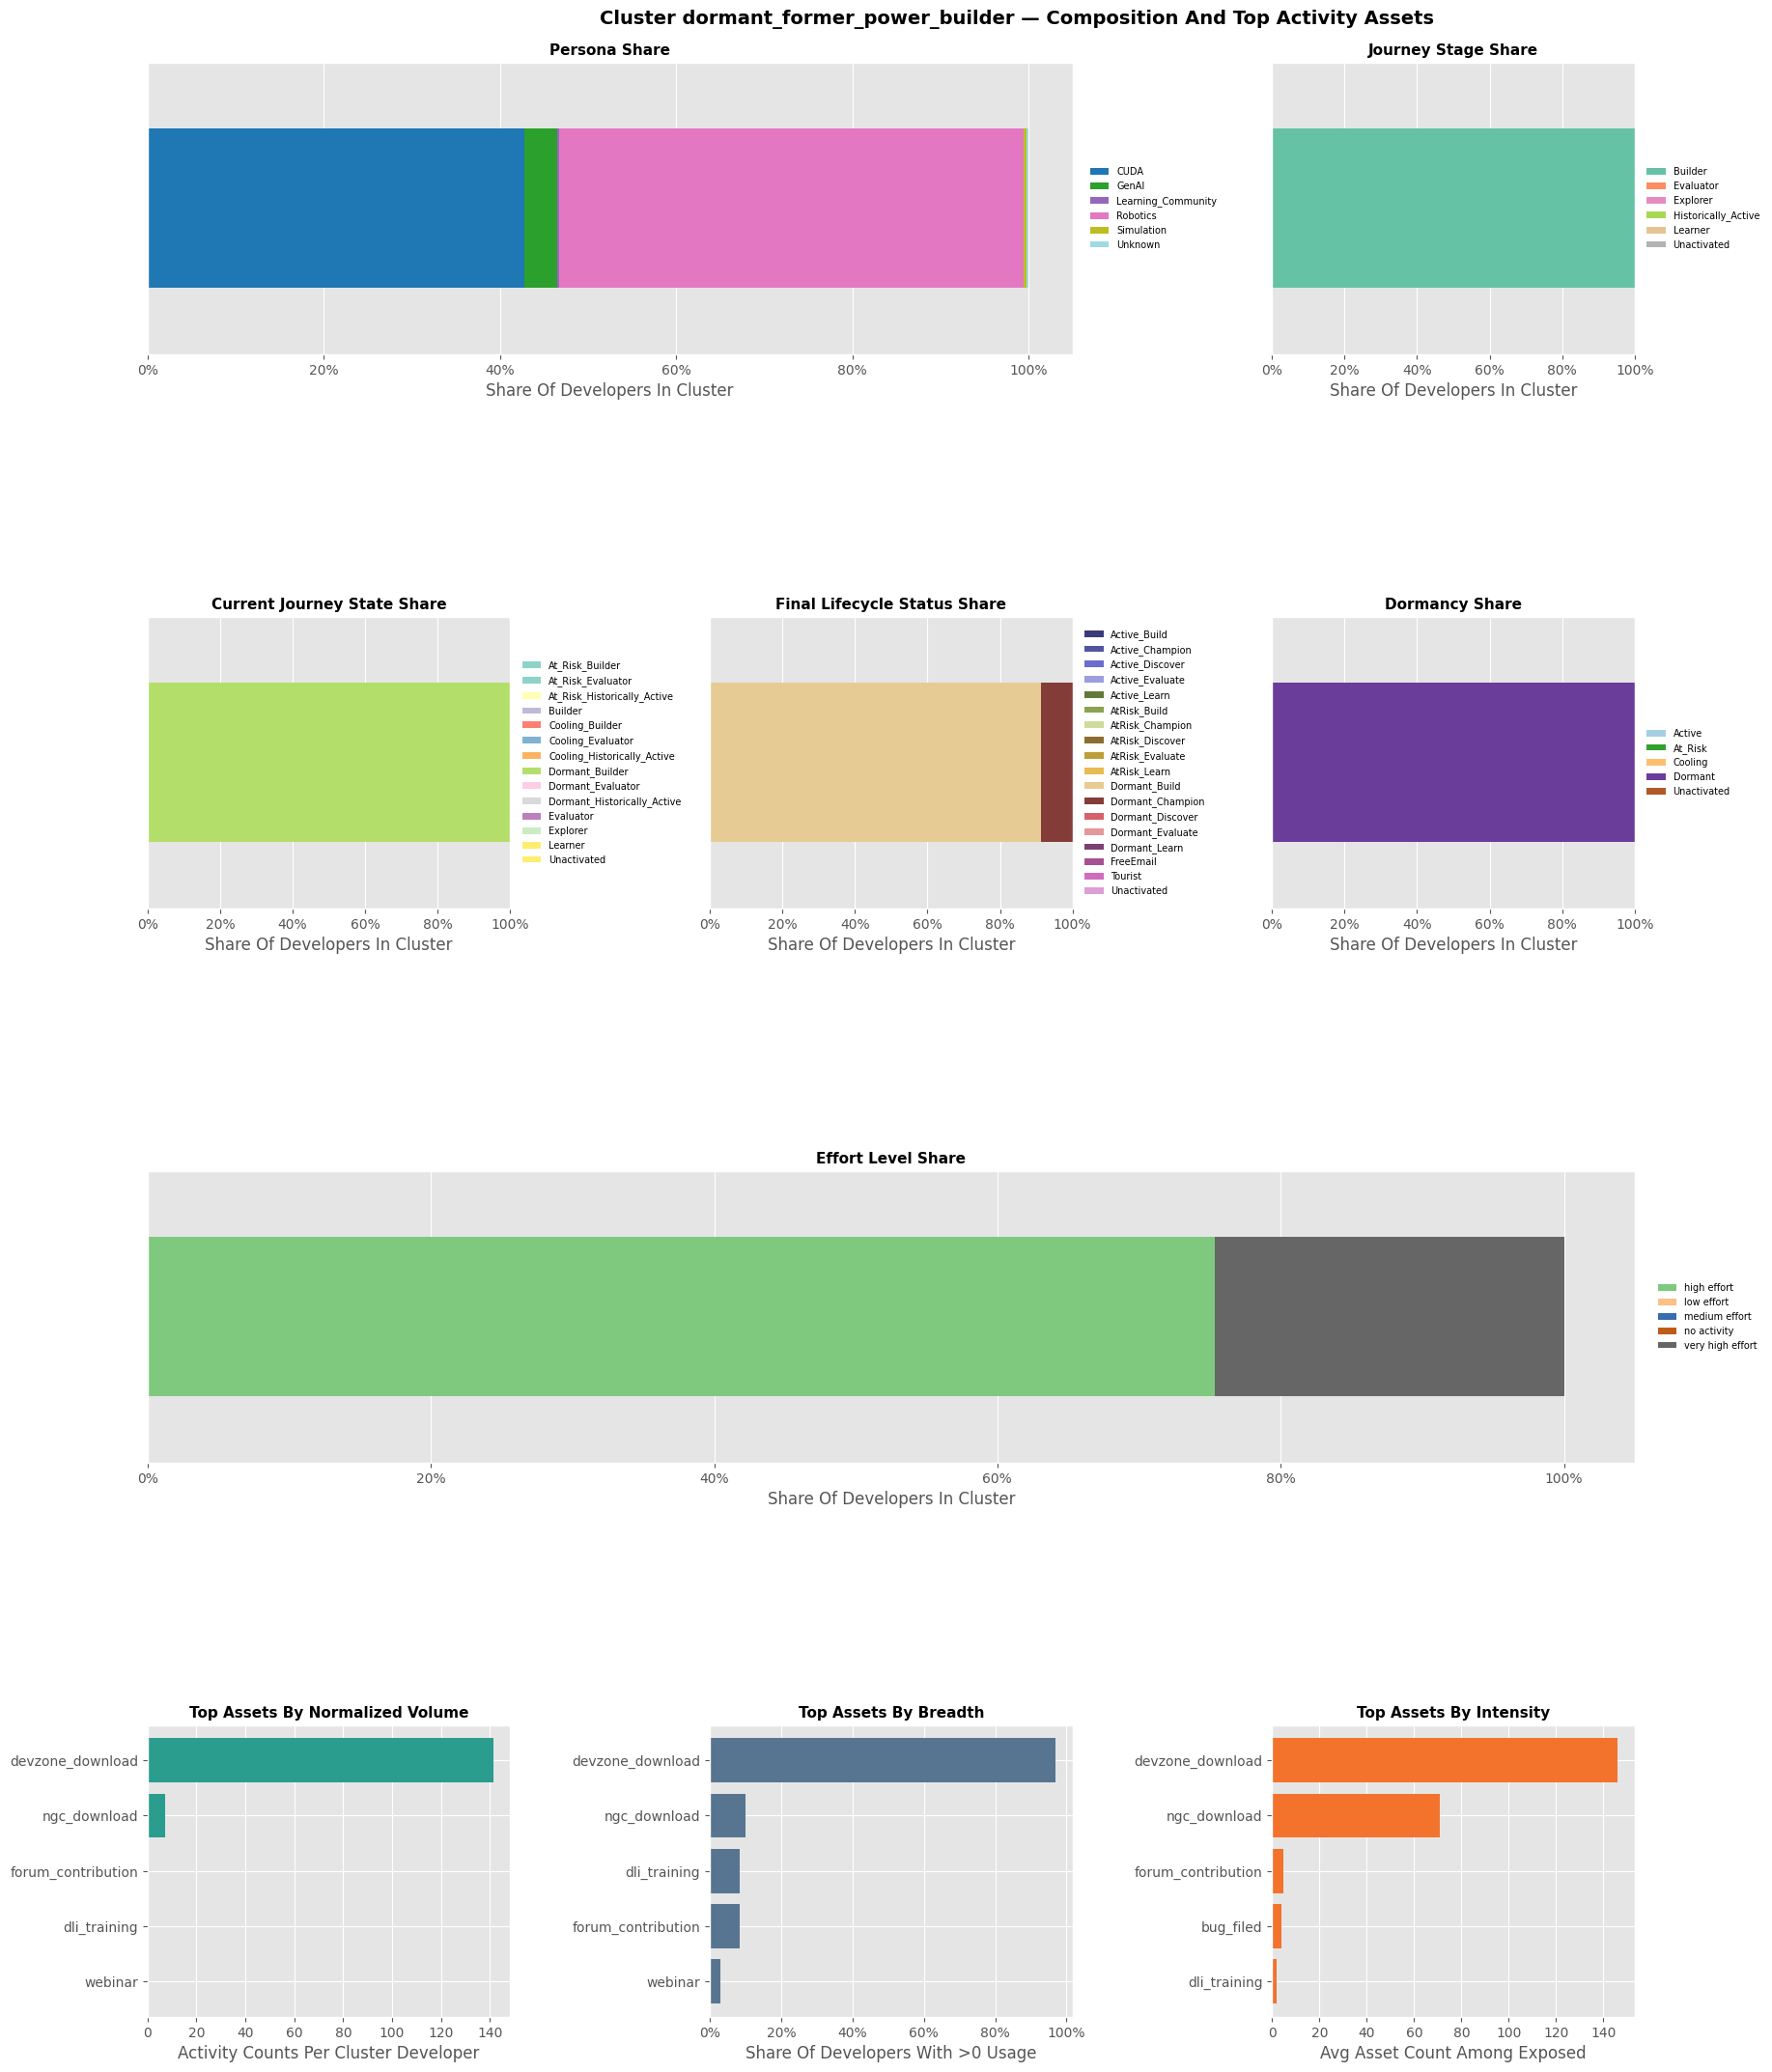

### Cluster: `active_c4` (64,463 developers)

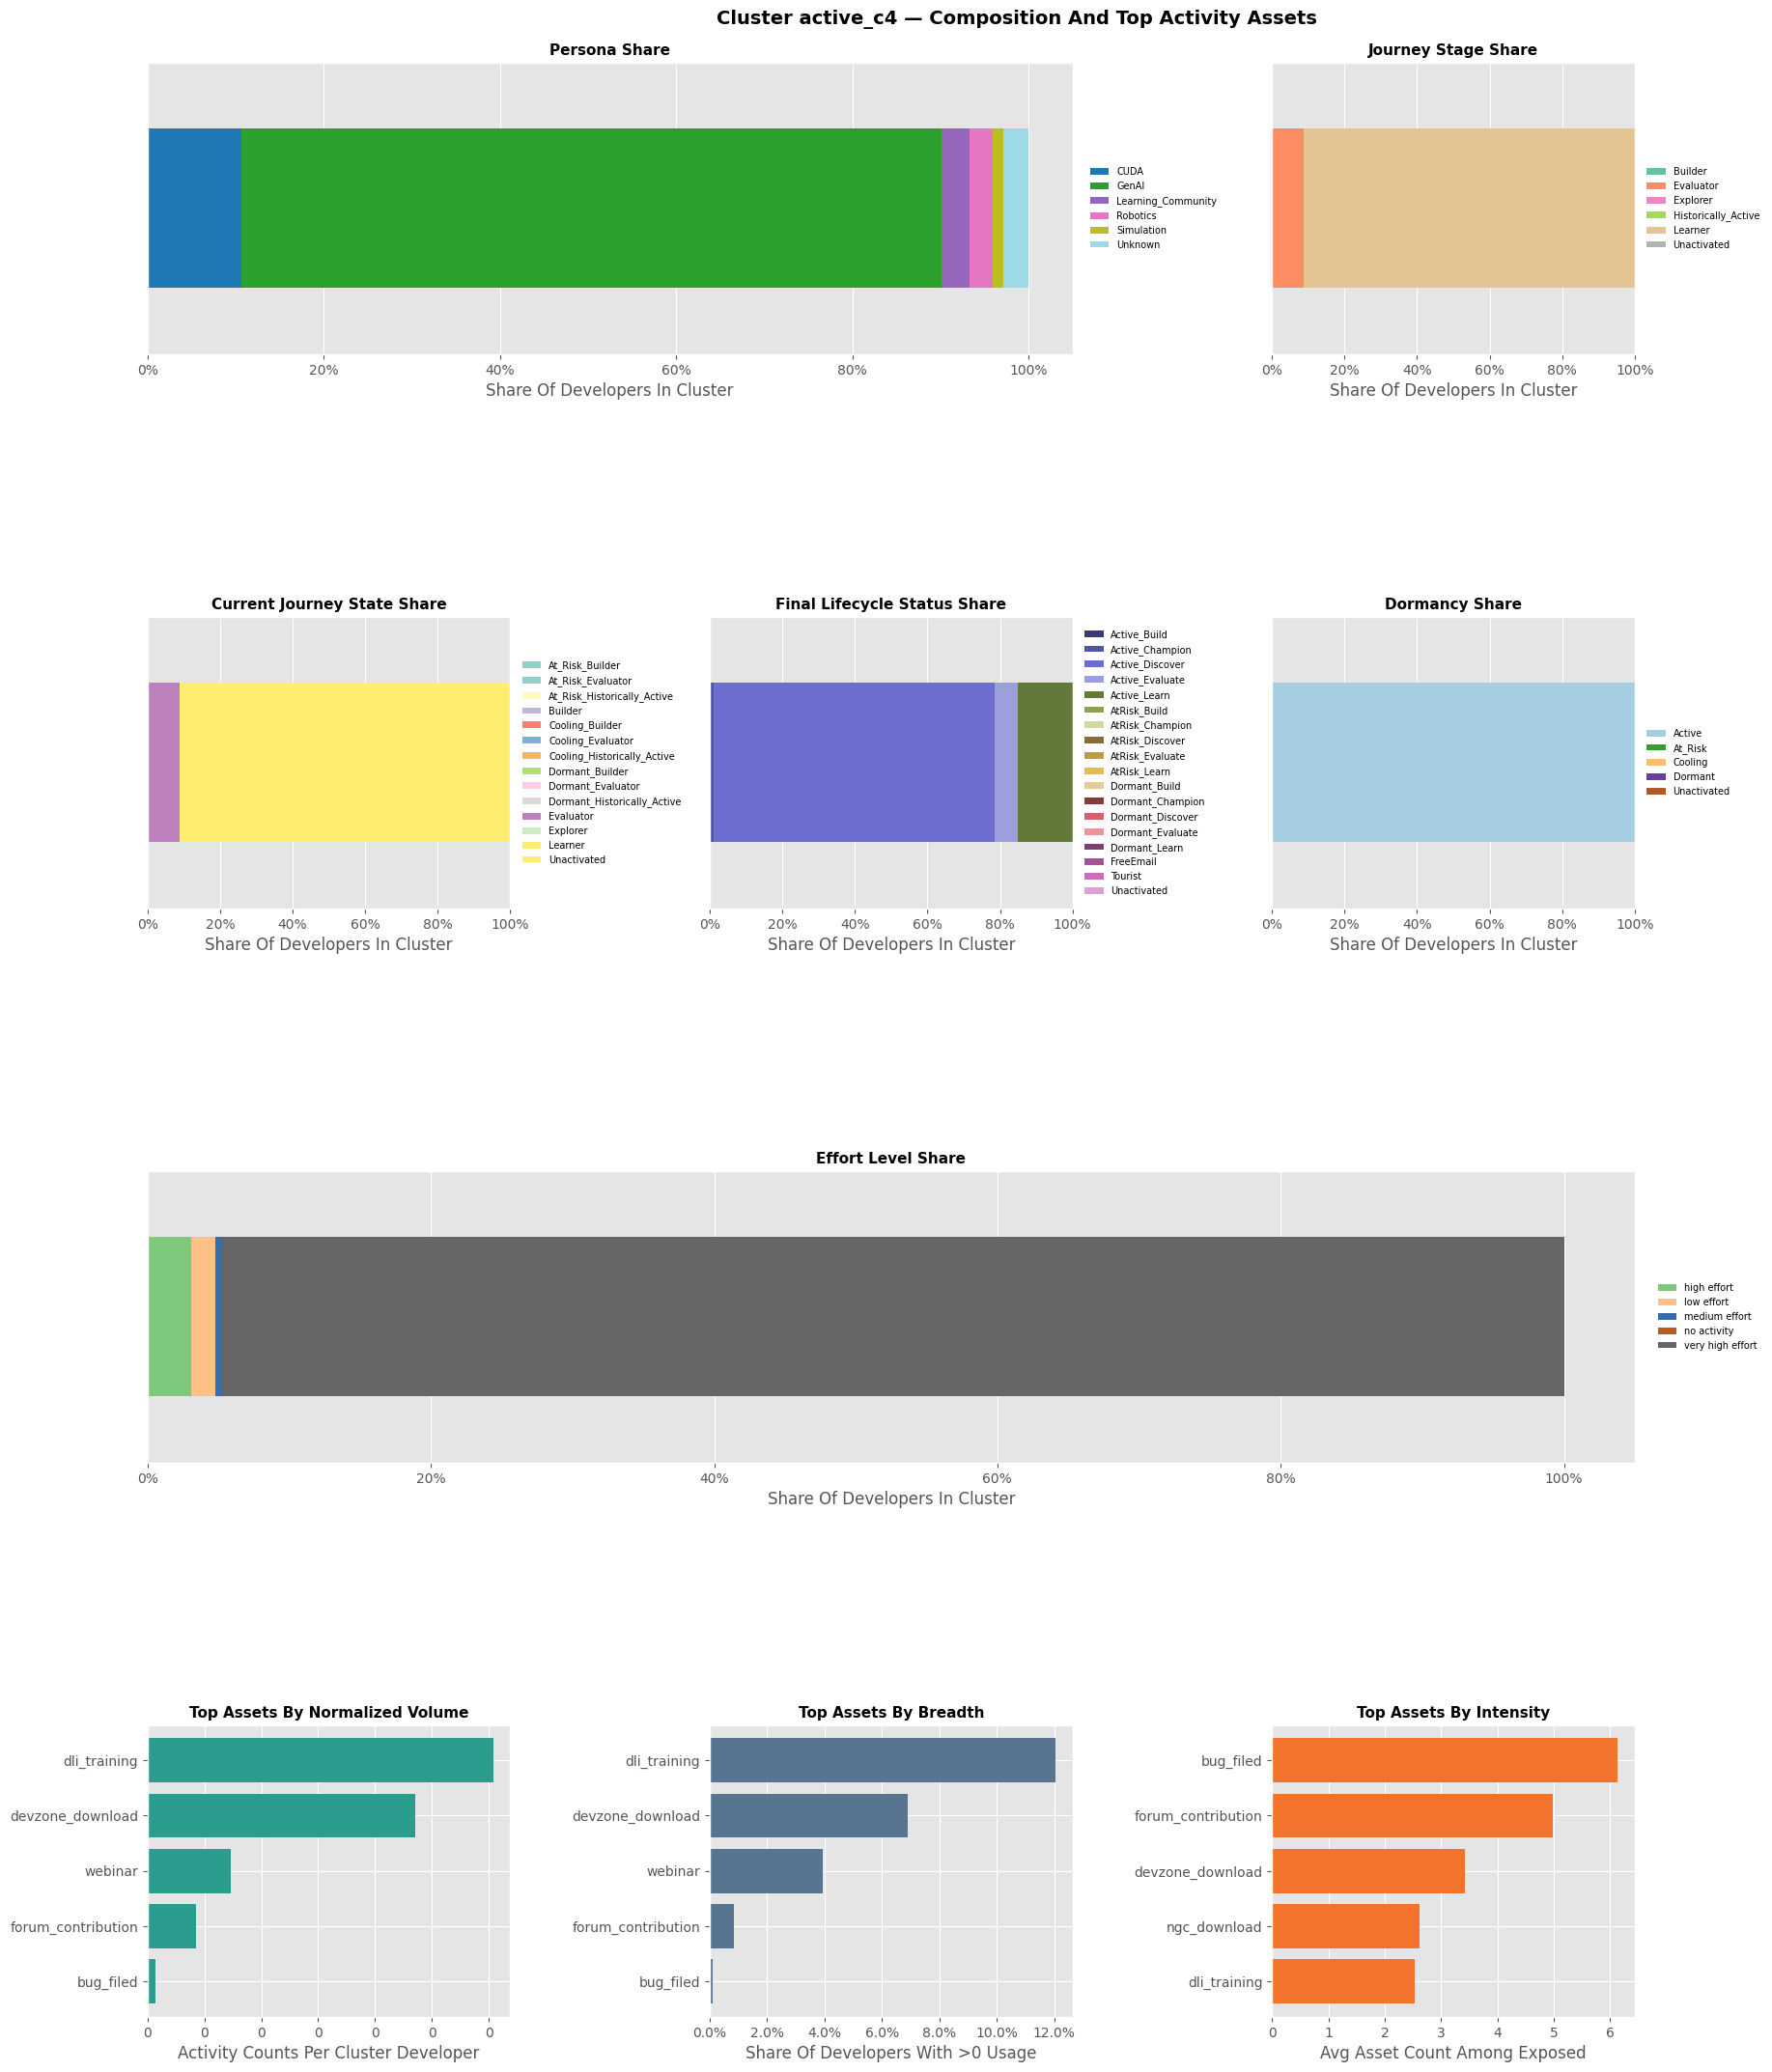

### Cluster: `active_c0` (51,389 developers)

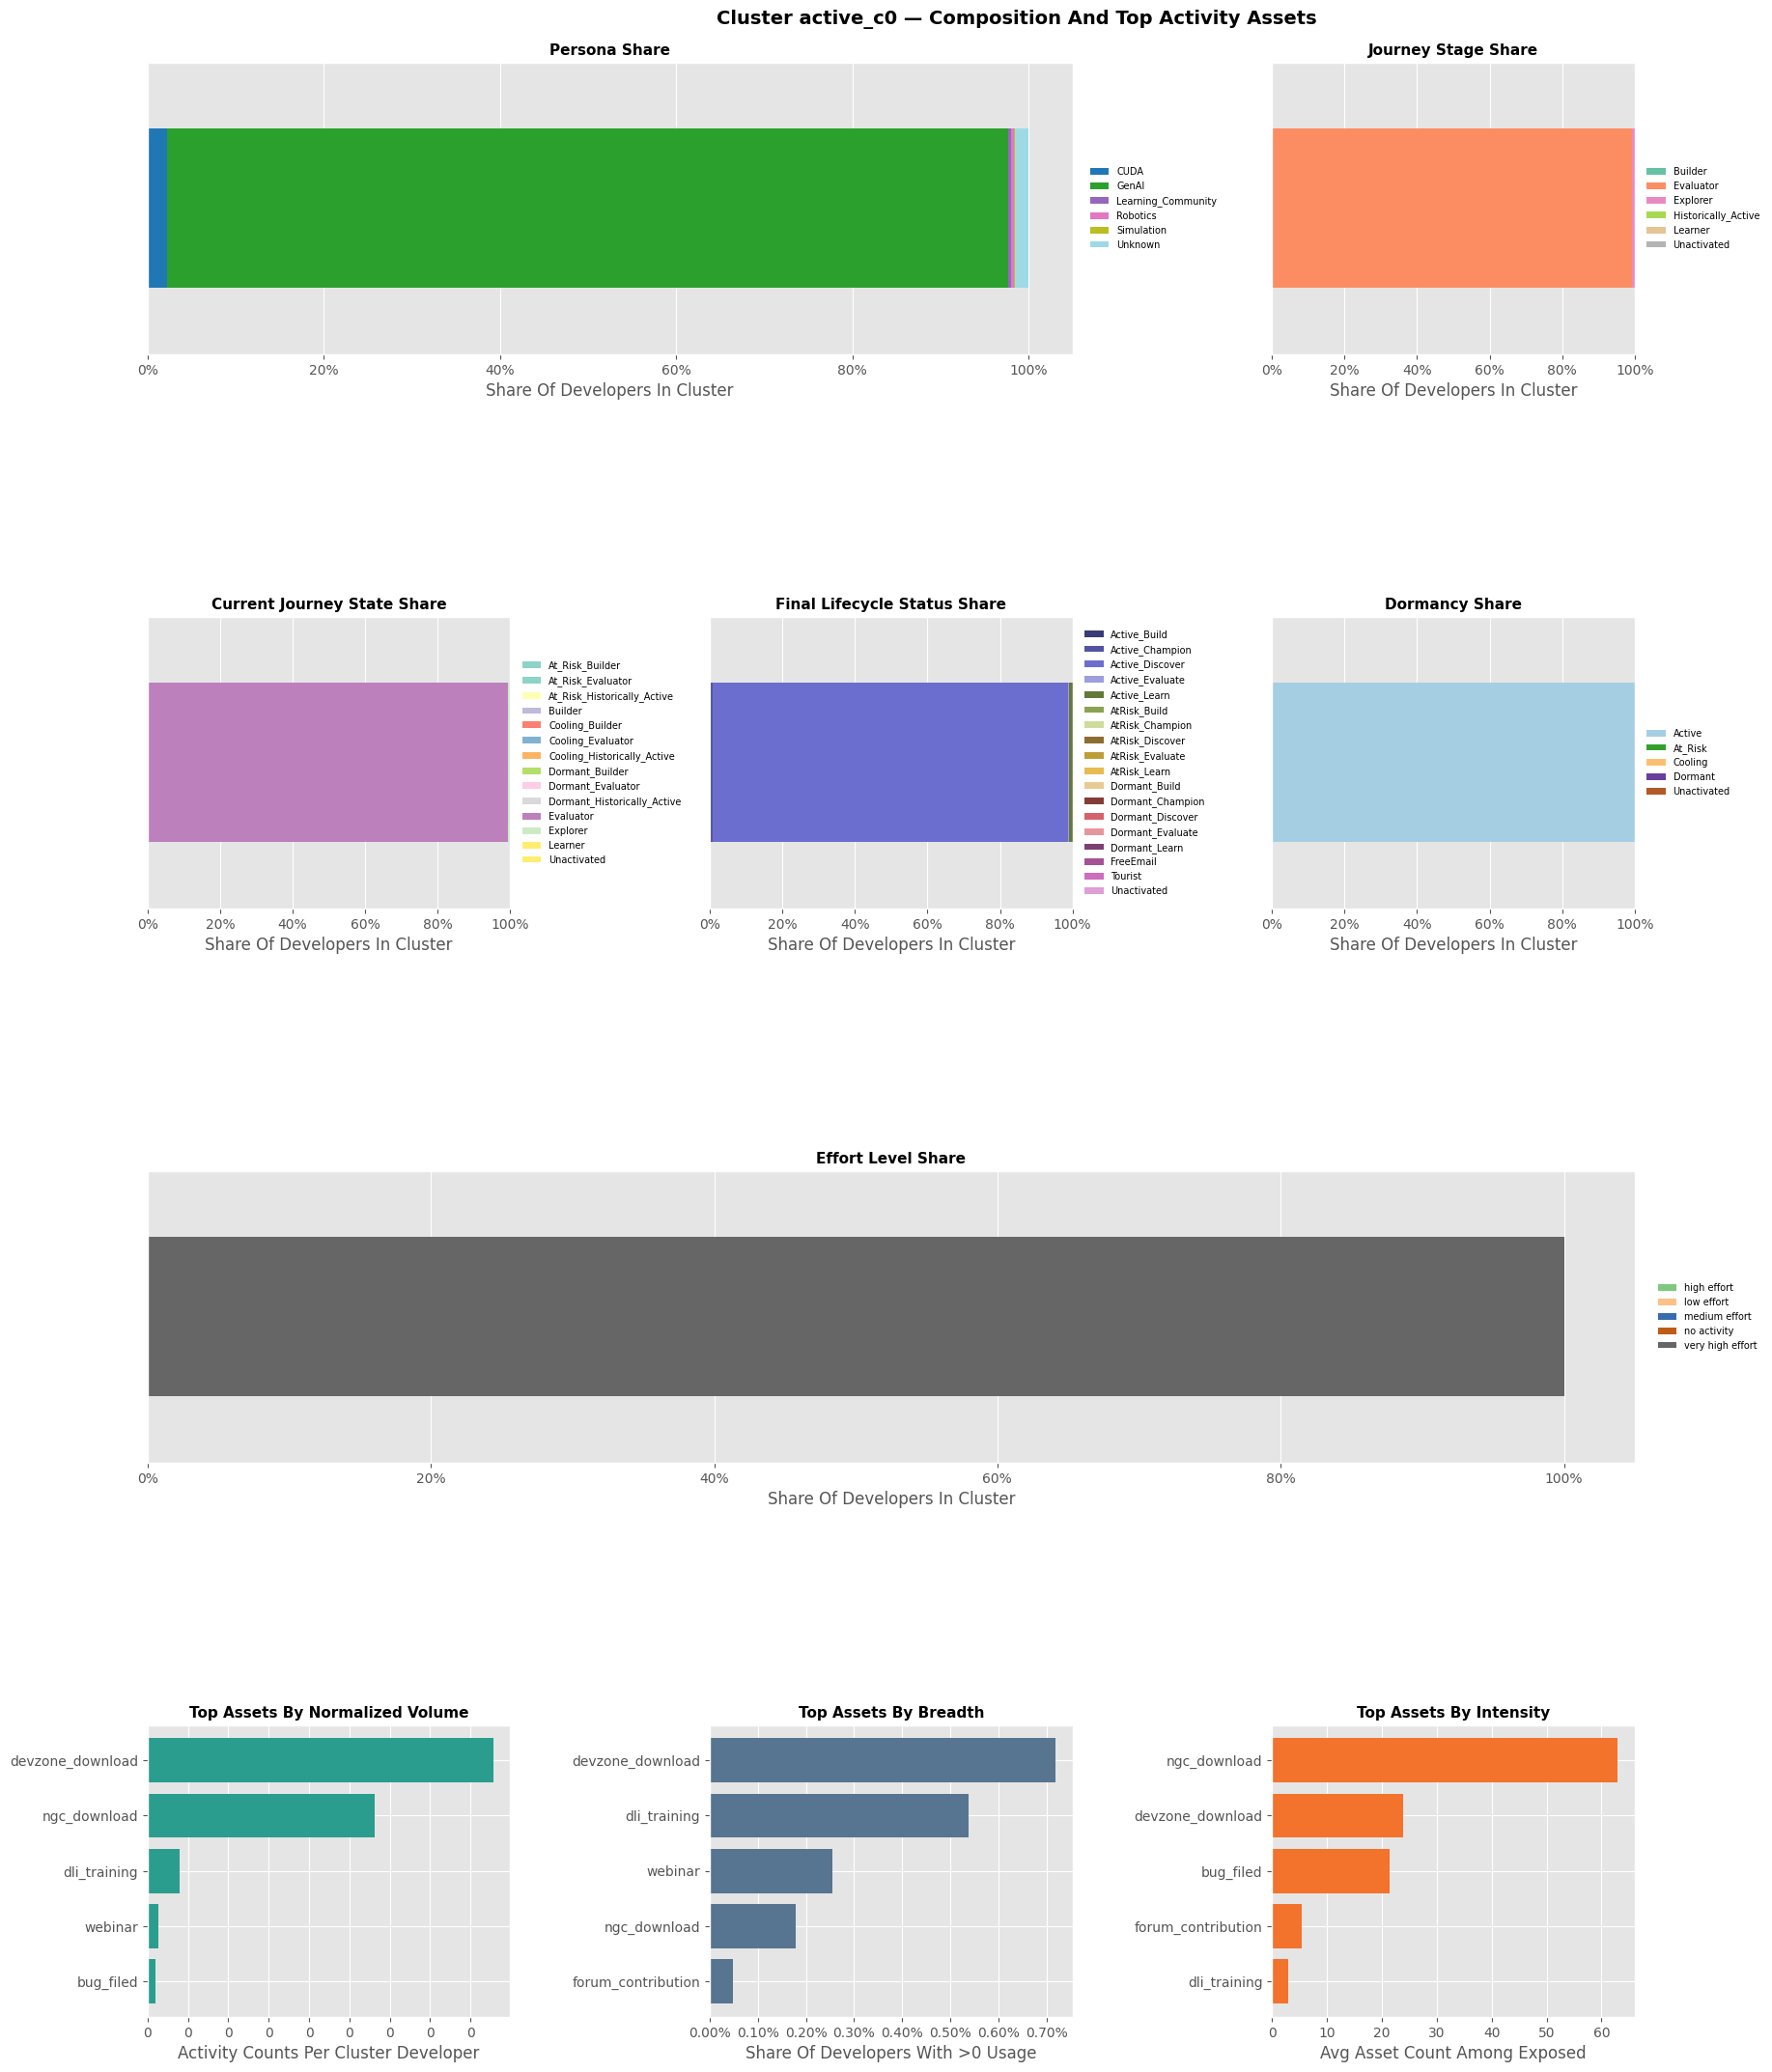

### Cluster: `active_c1` (46,966 developers)

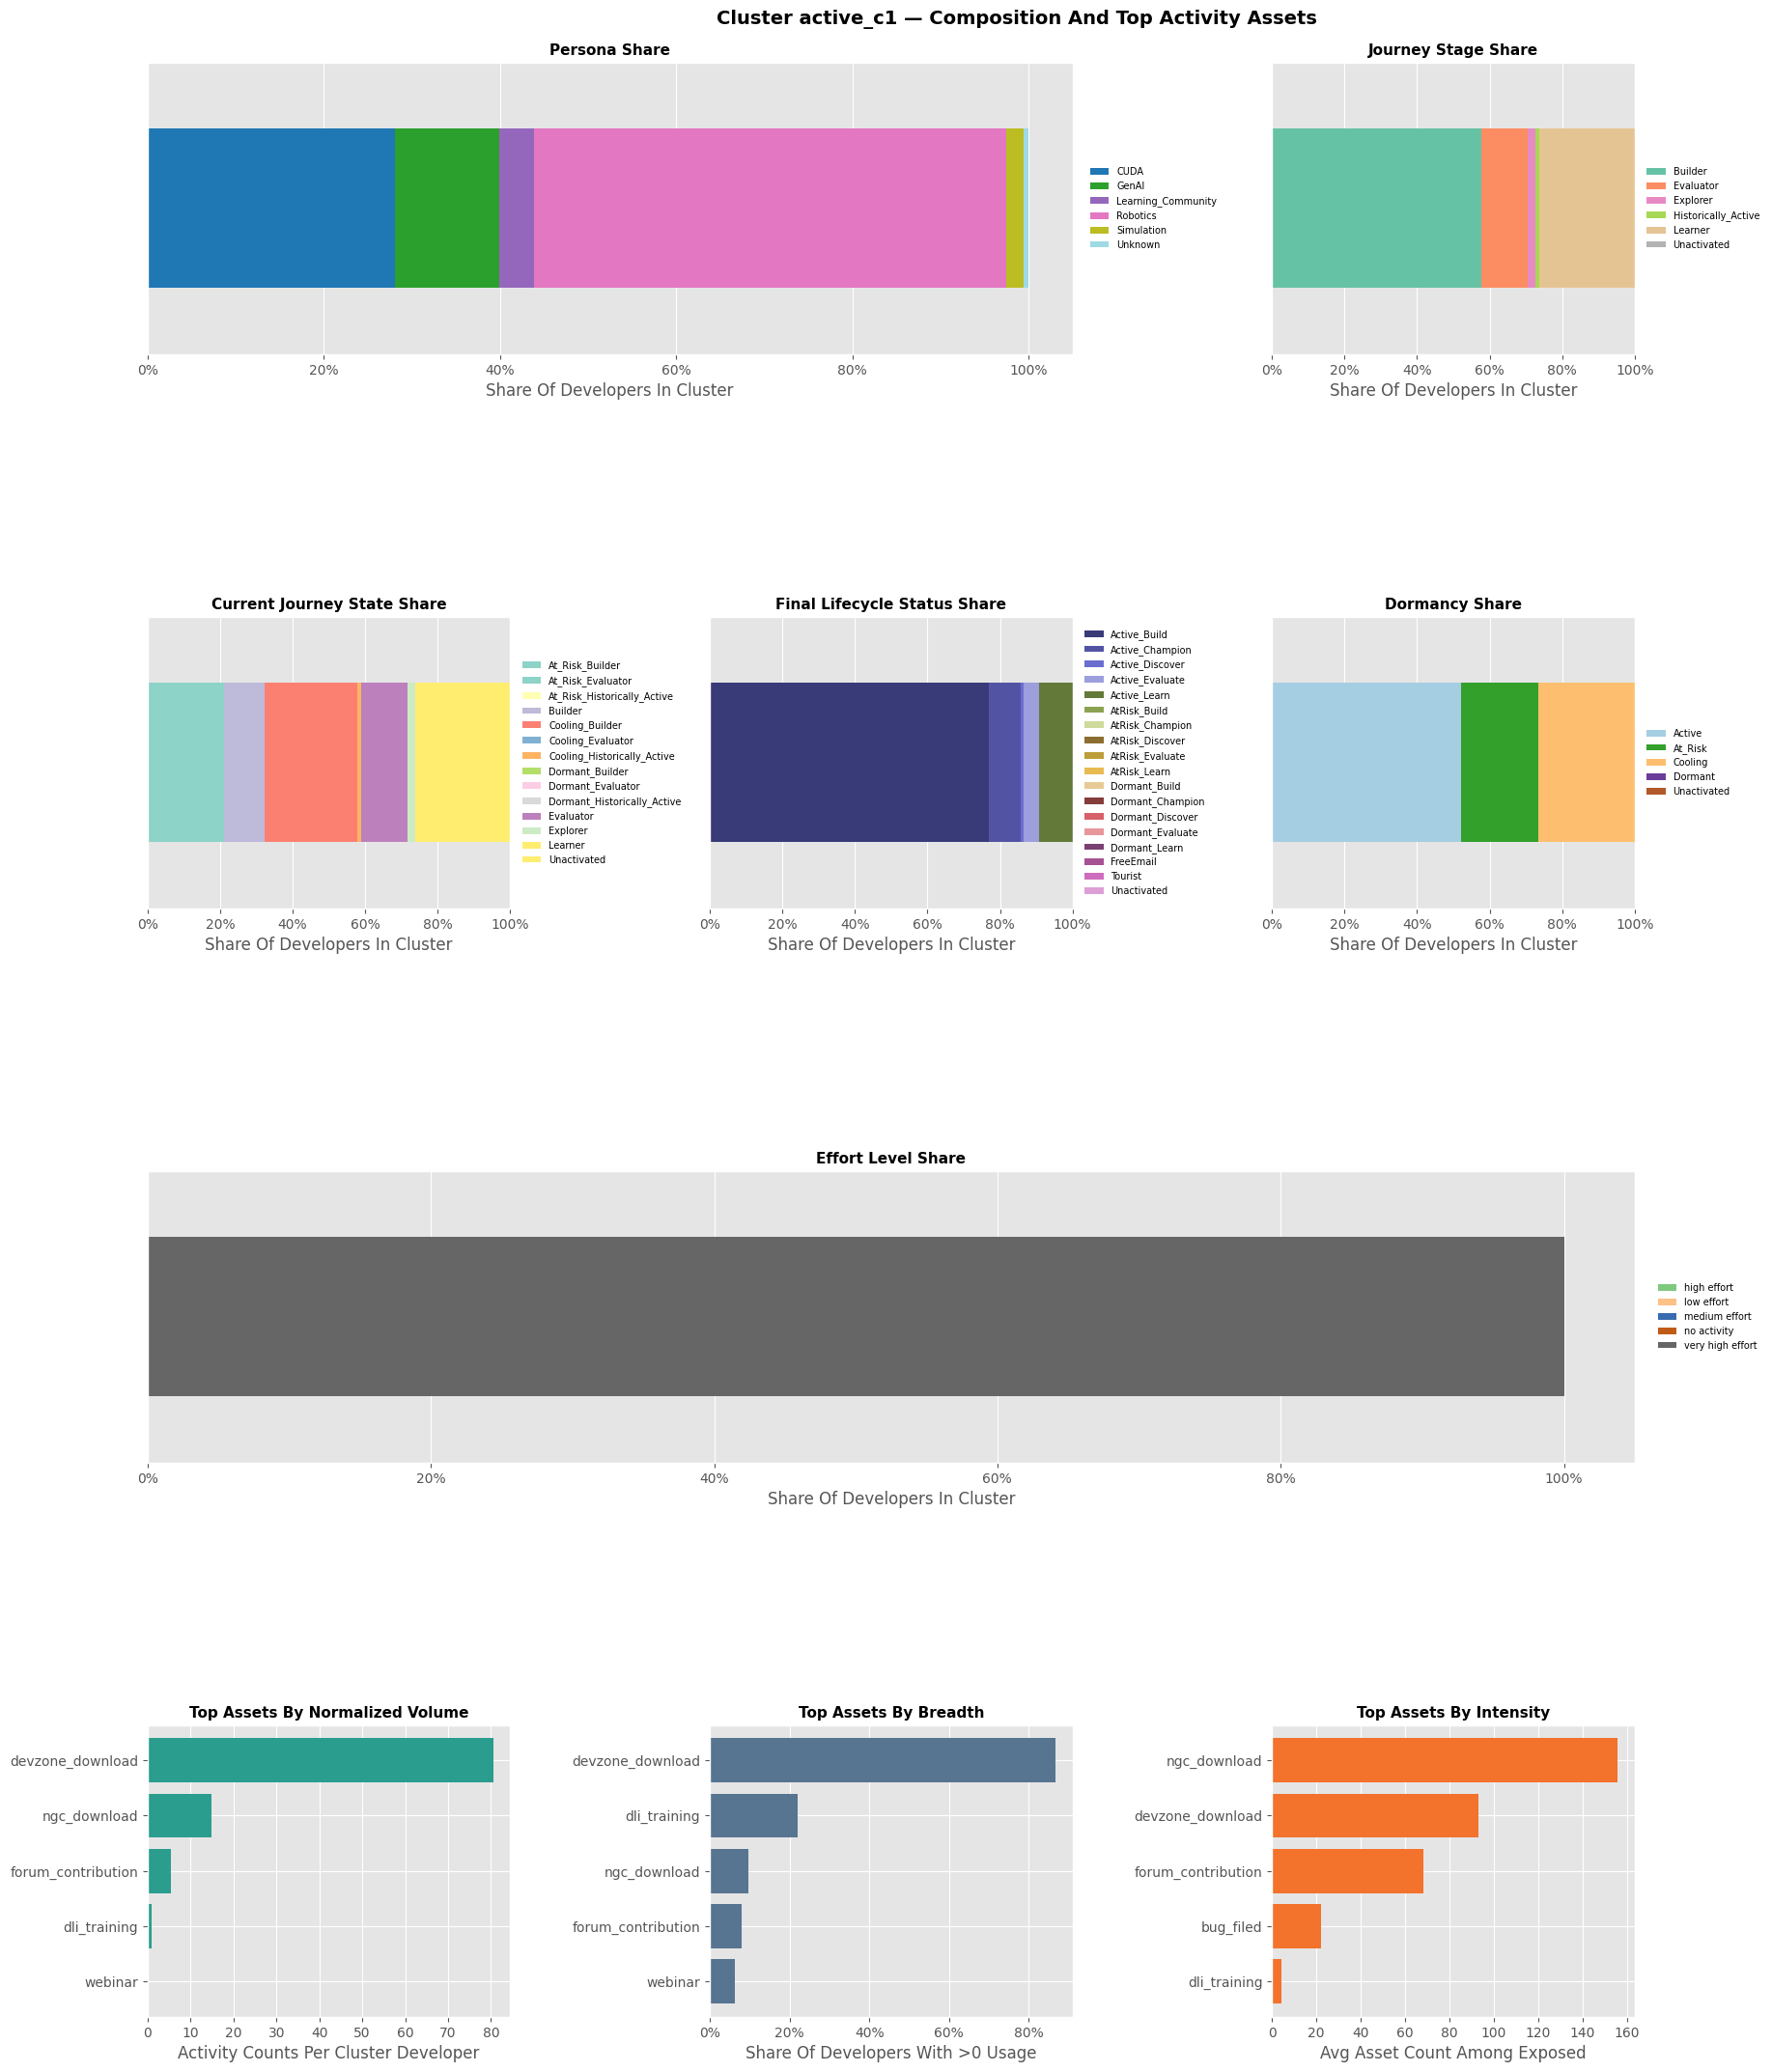

### Cluster: `active_c3` (27,096 developers)

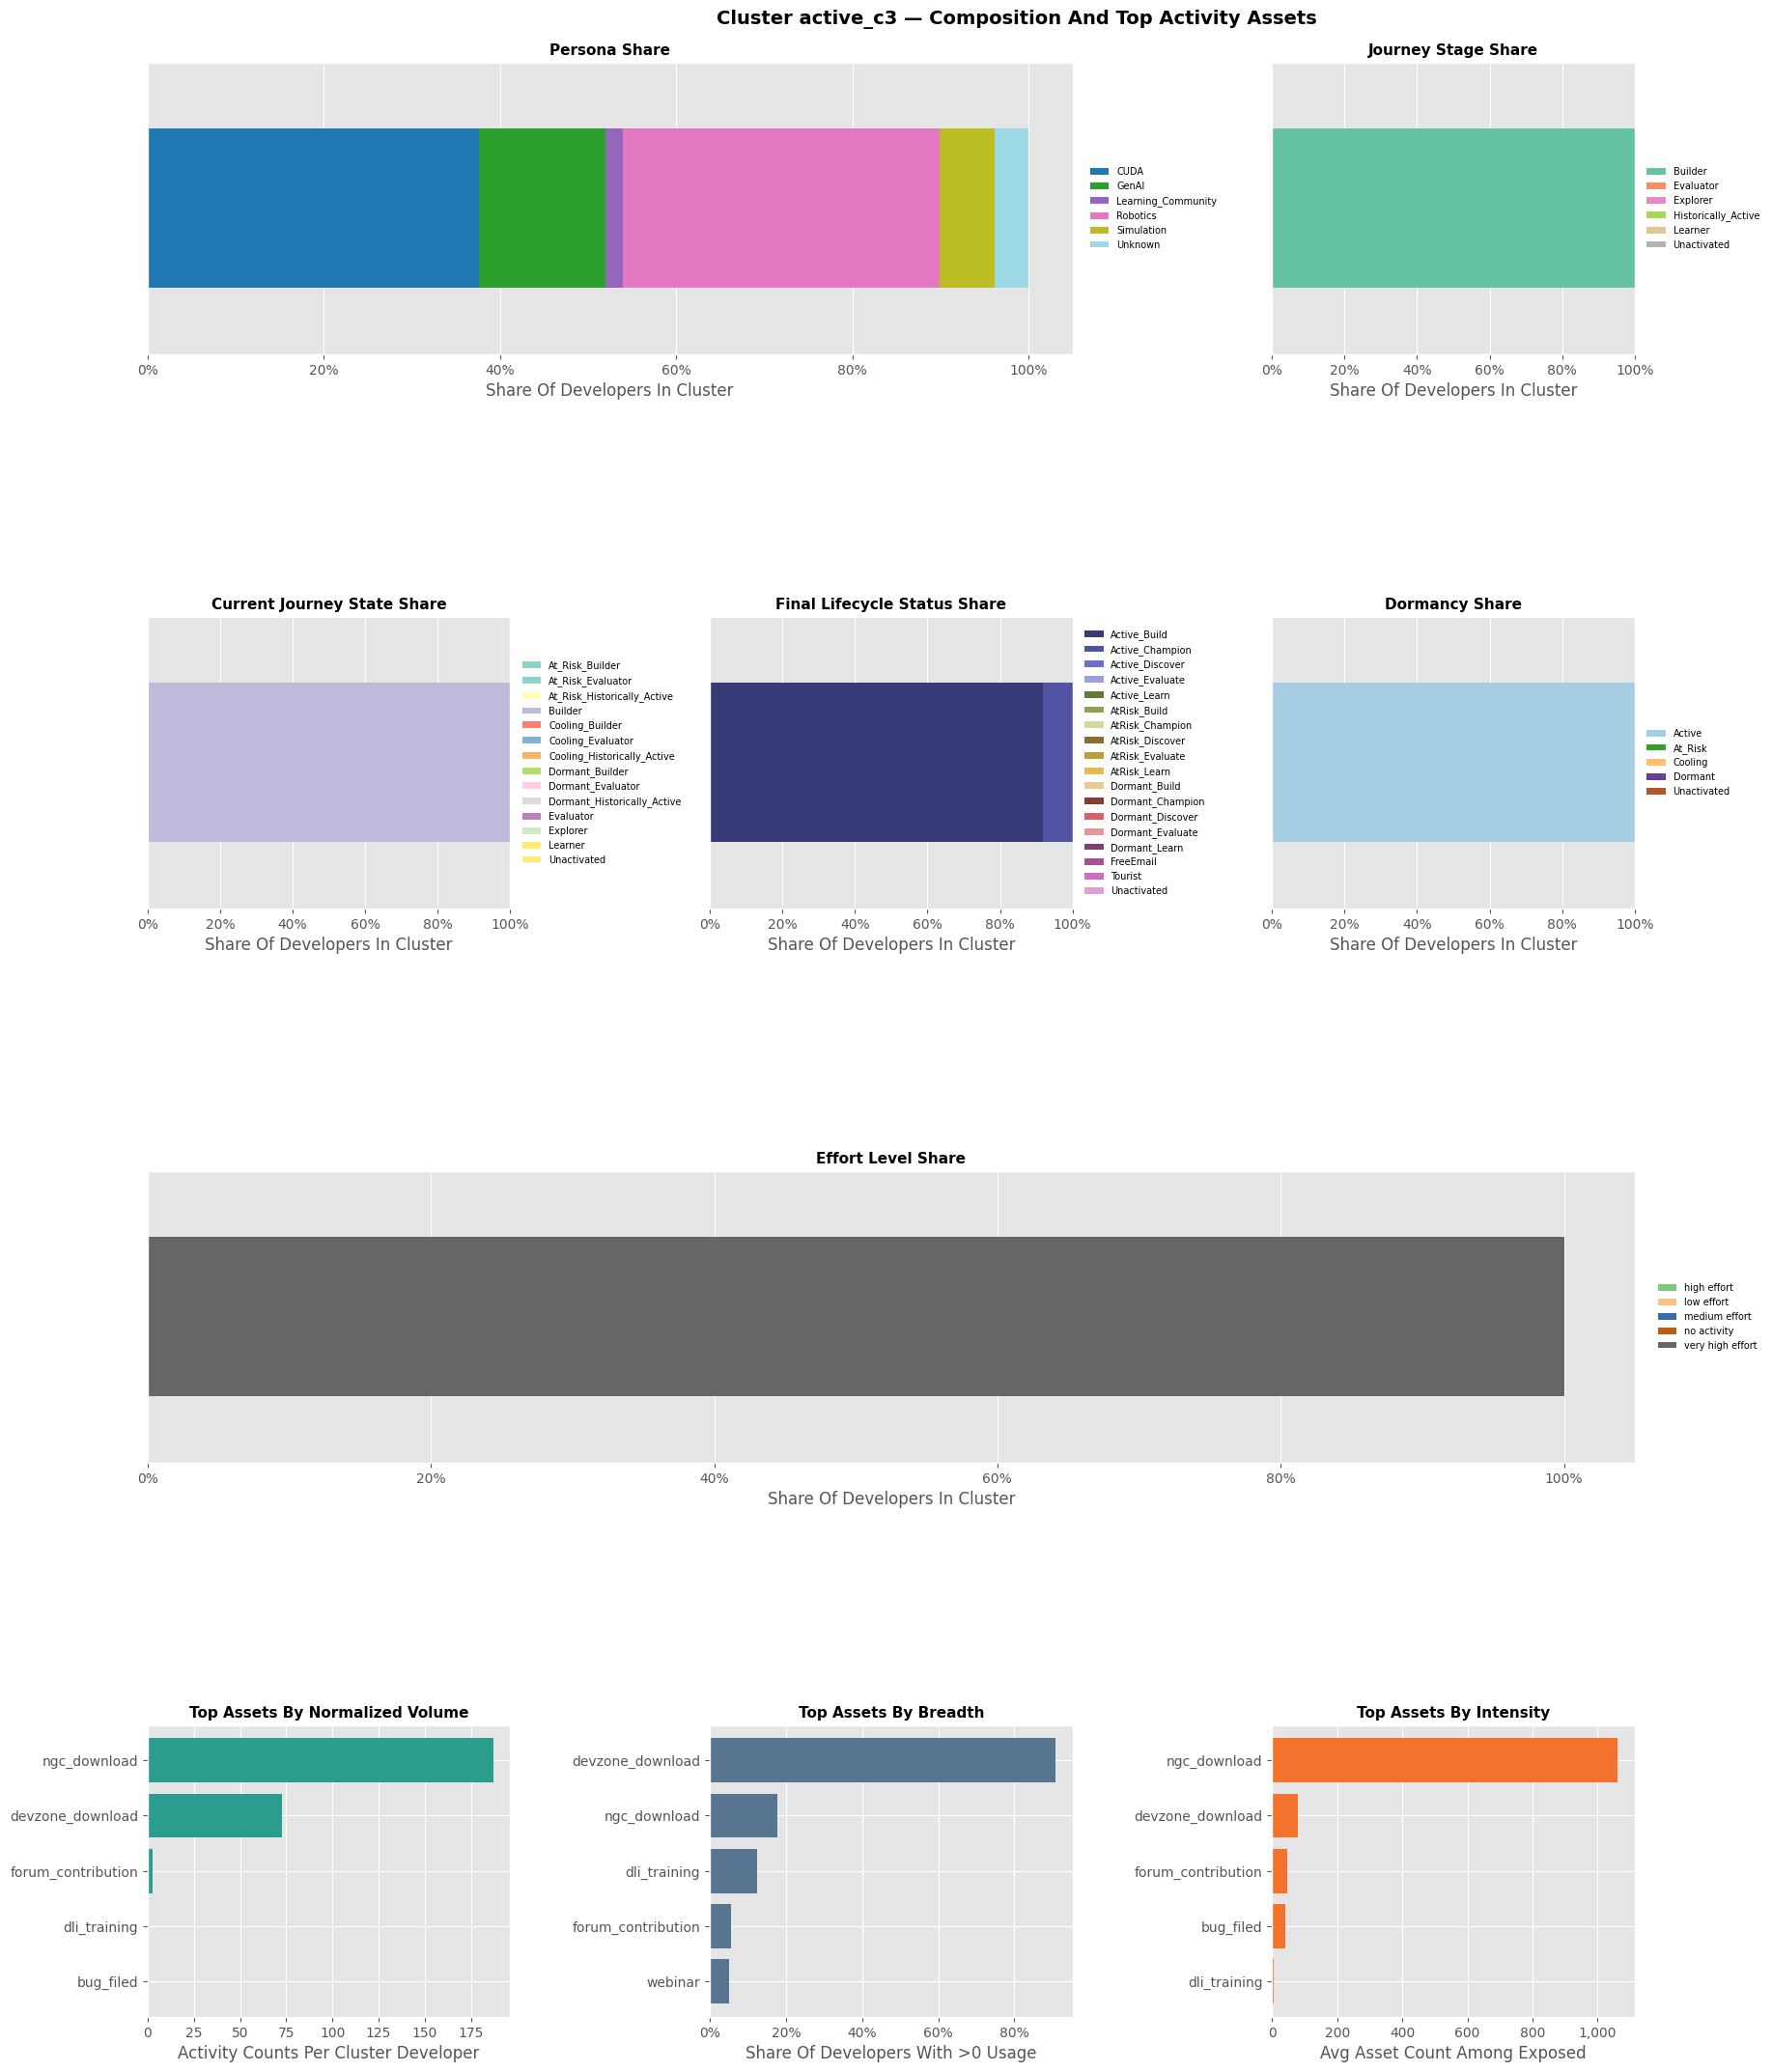

## Aggregate Overview Across Clusters

### Cluster-Level Activity And Exposure Overview

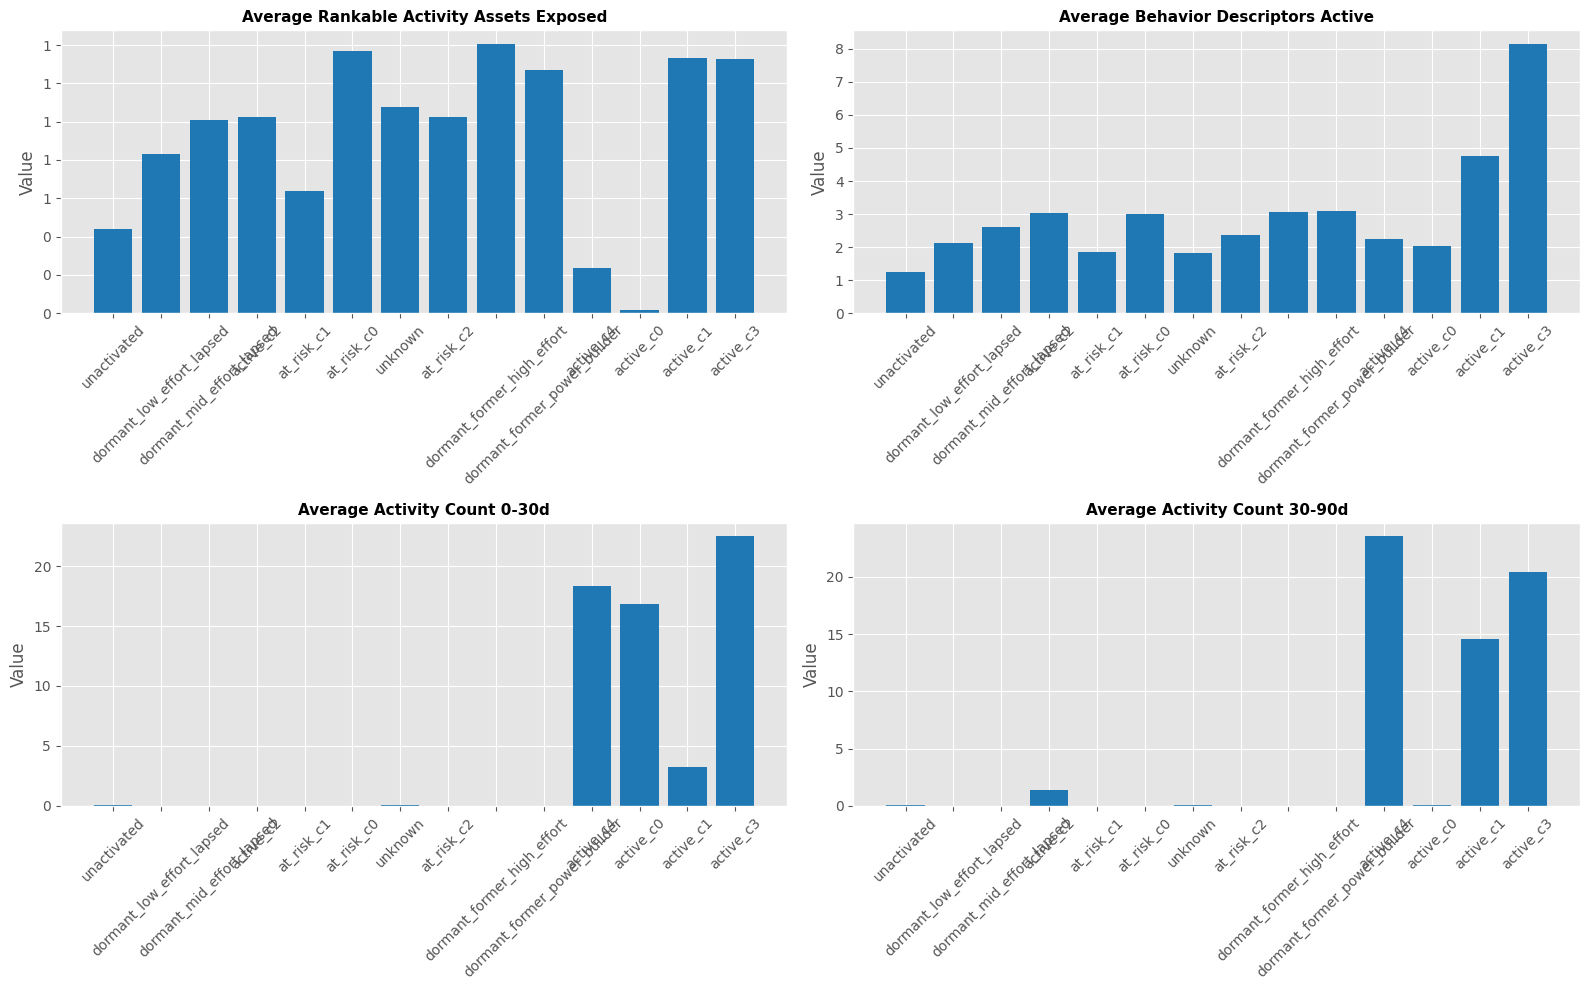

### Persona Share By Cluster

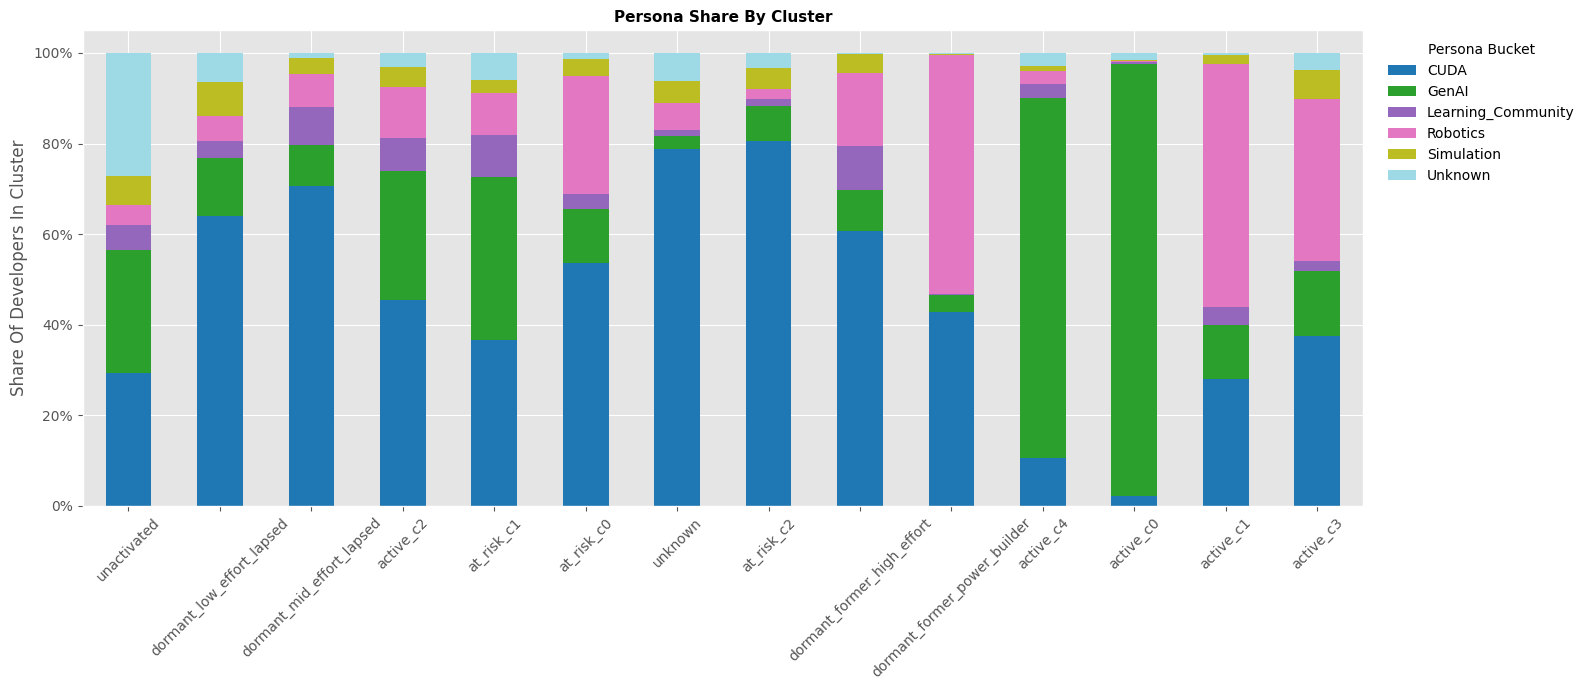

### Journey Stage Share By Cluster

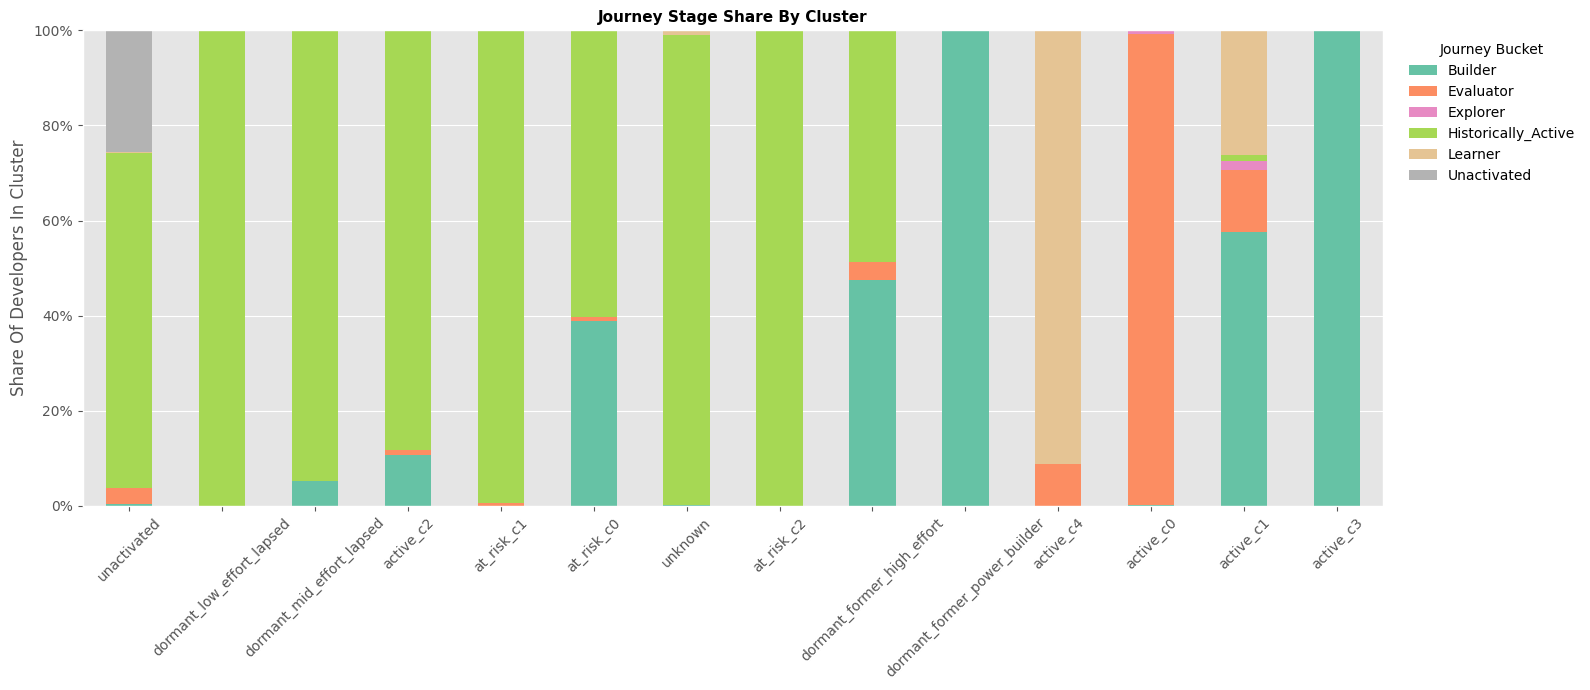

### Current Journey State Share By Cluster

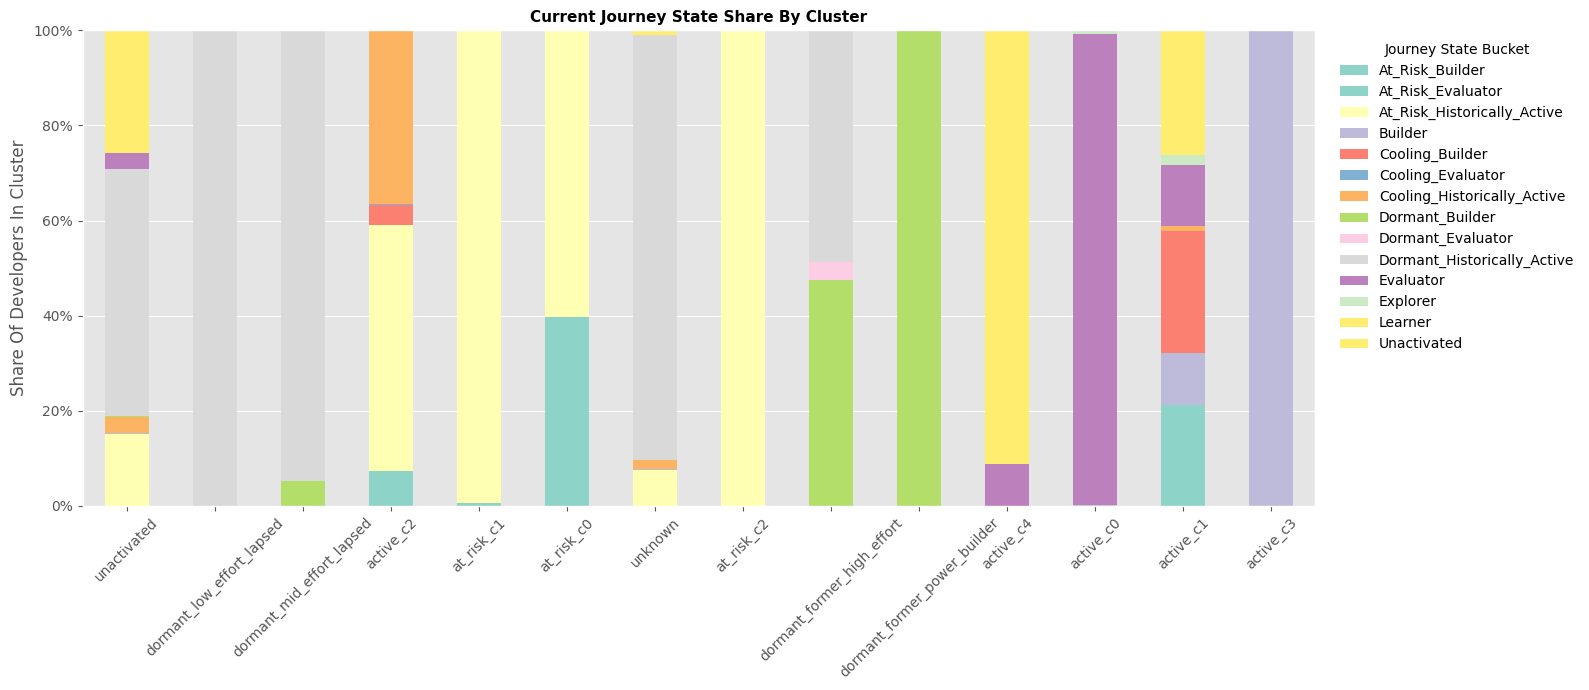

### Final Lifecycle Status Share By Cluster

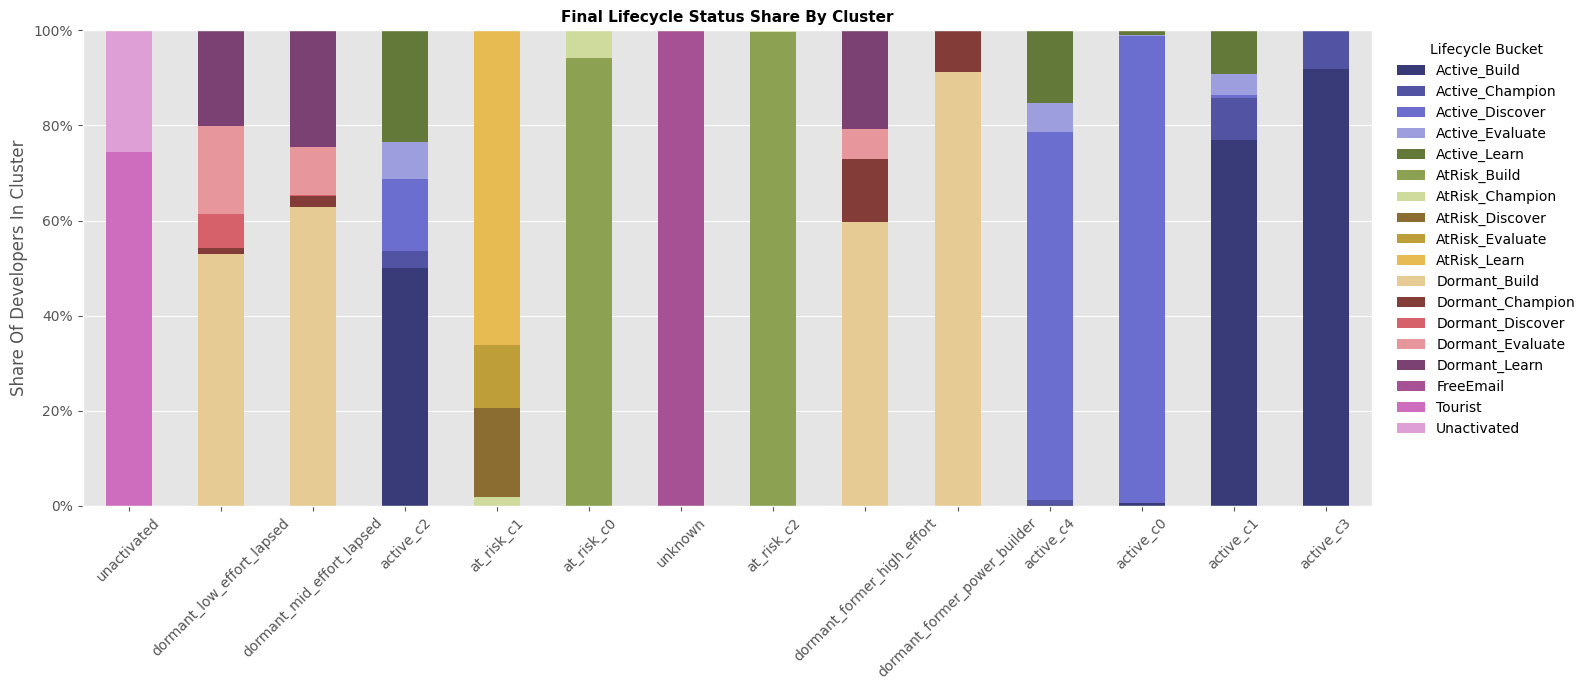

### Dormancy Share By Cluster

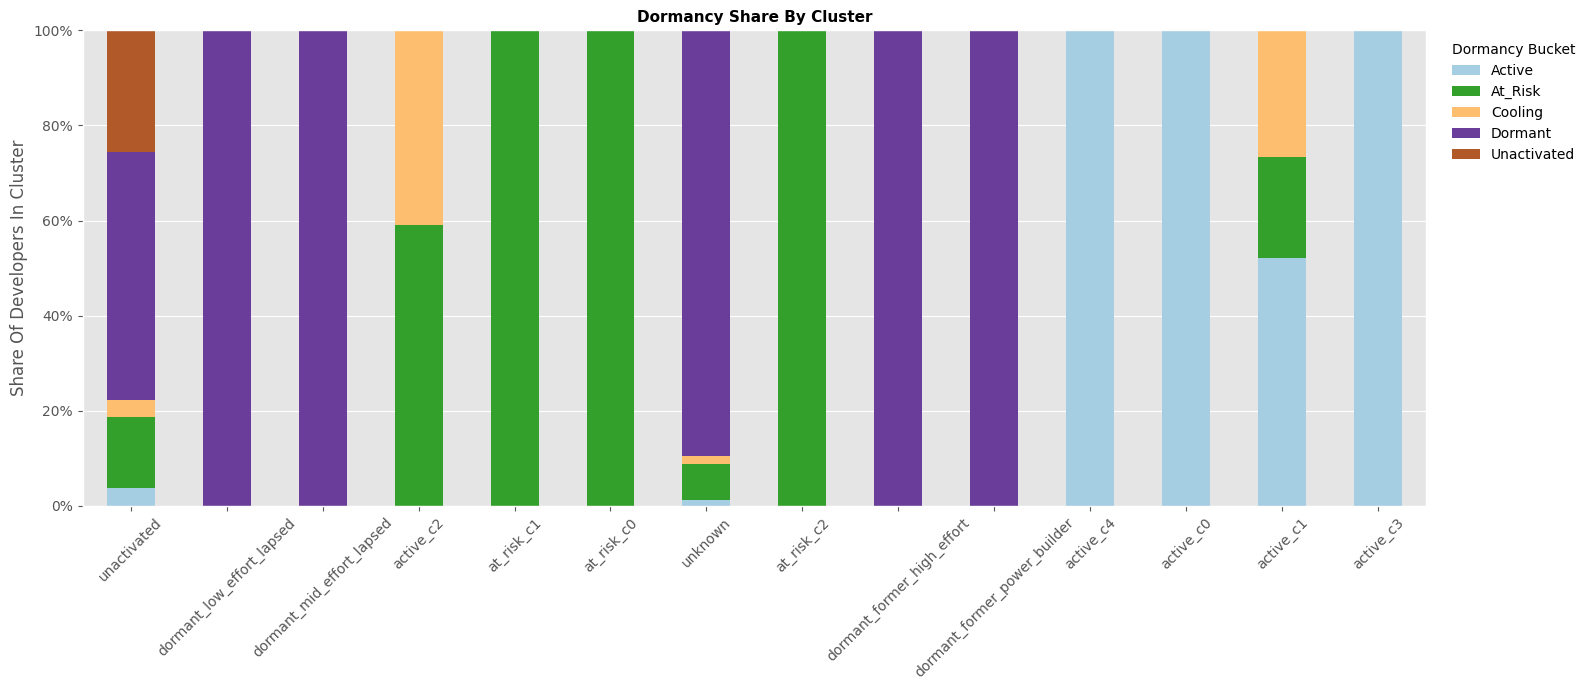

### Effort Level Share By Cluster

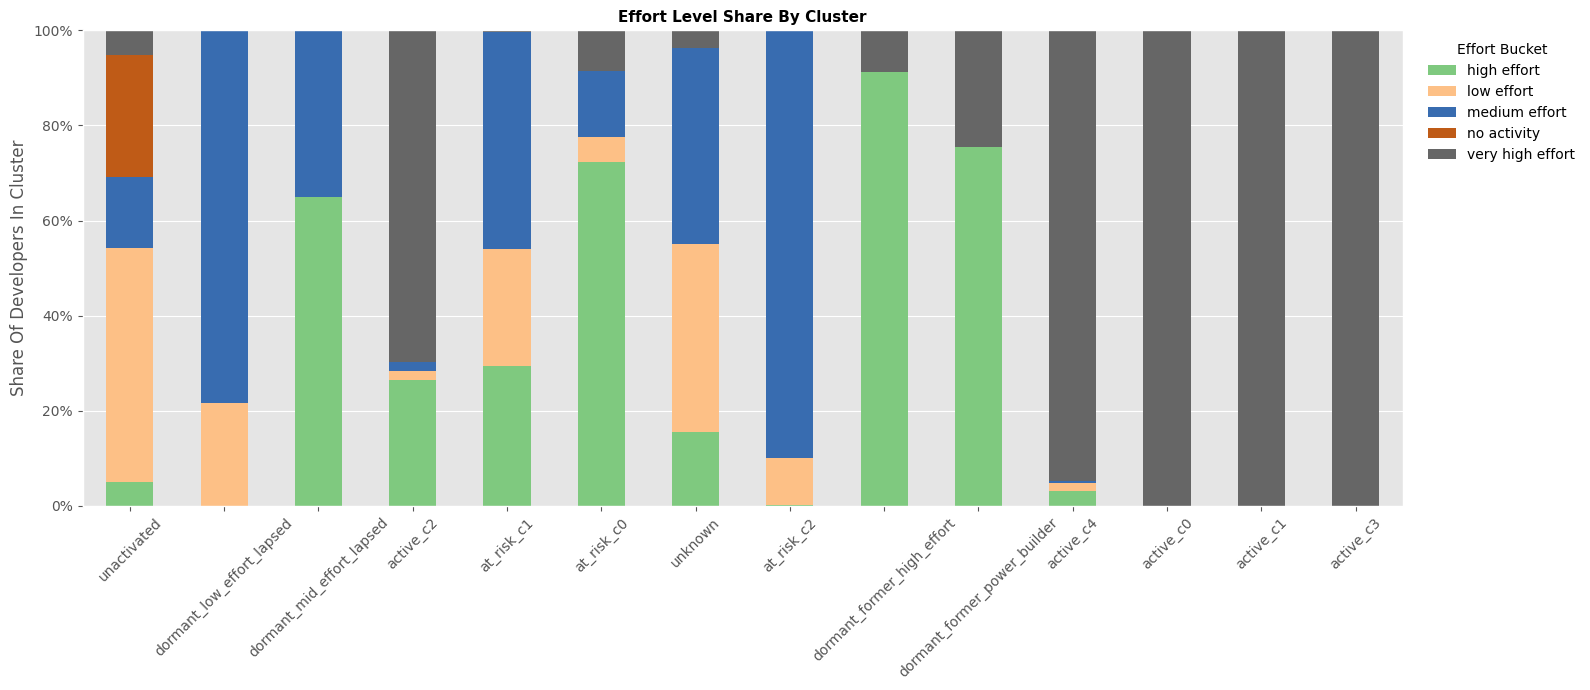

## Per-Asset Views

<positron-console-cell-12>:224: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<positron-console-cell-12>:225: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


### Asset View: `dli_training`

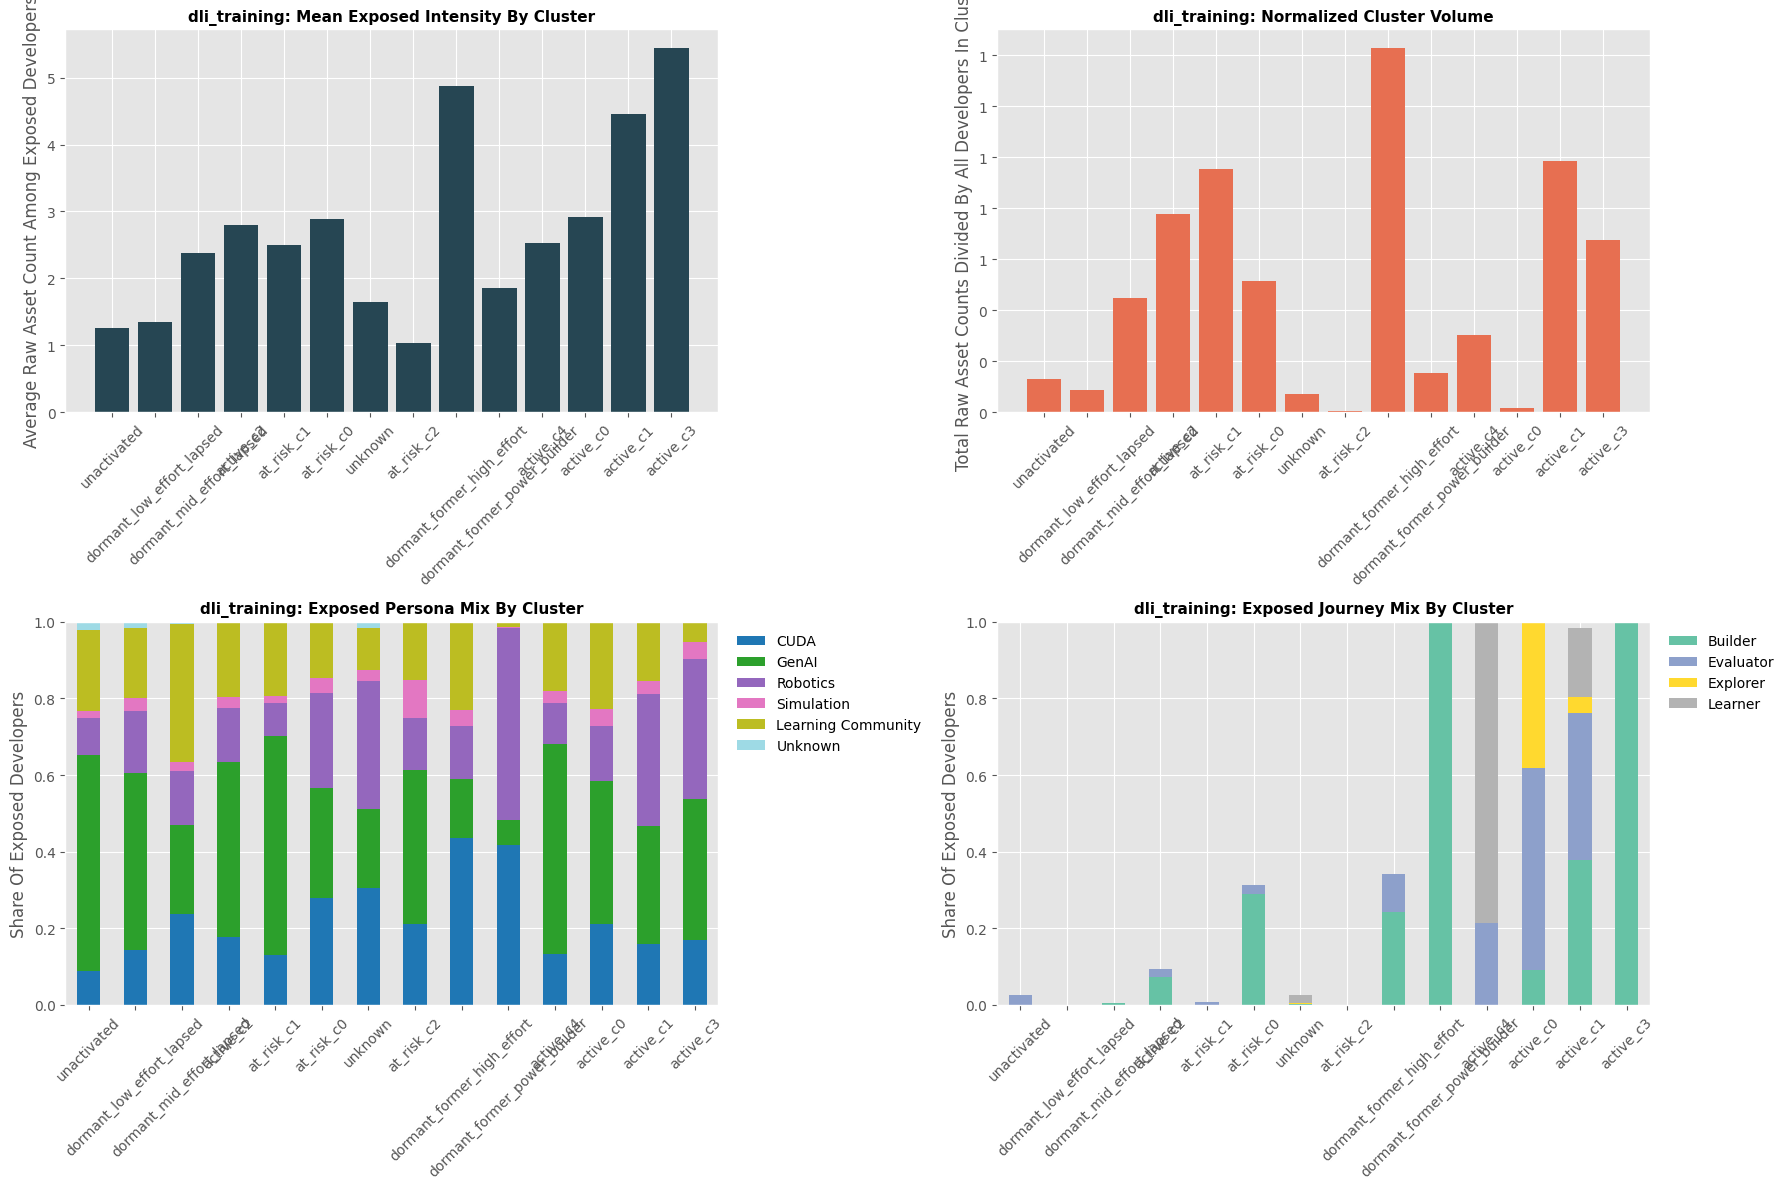

### Asset View: `webinar`

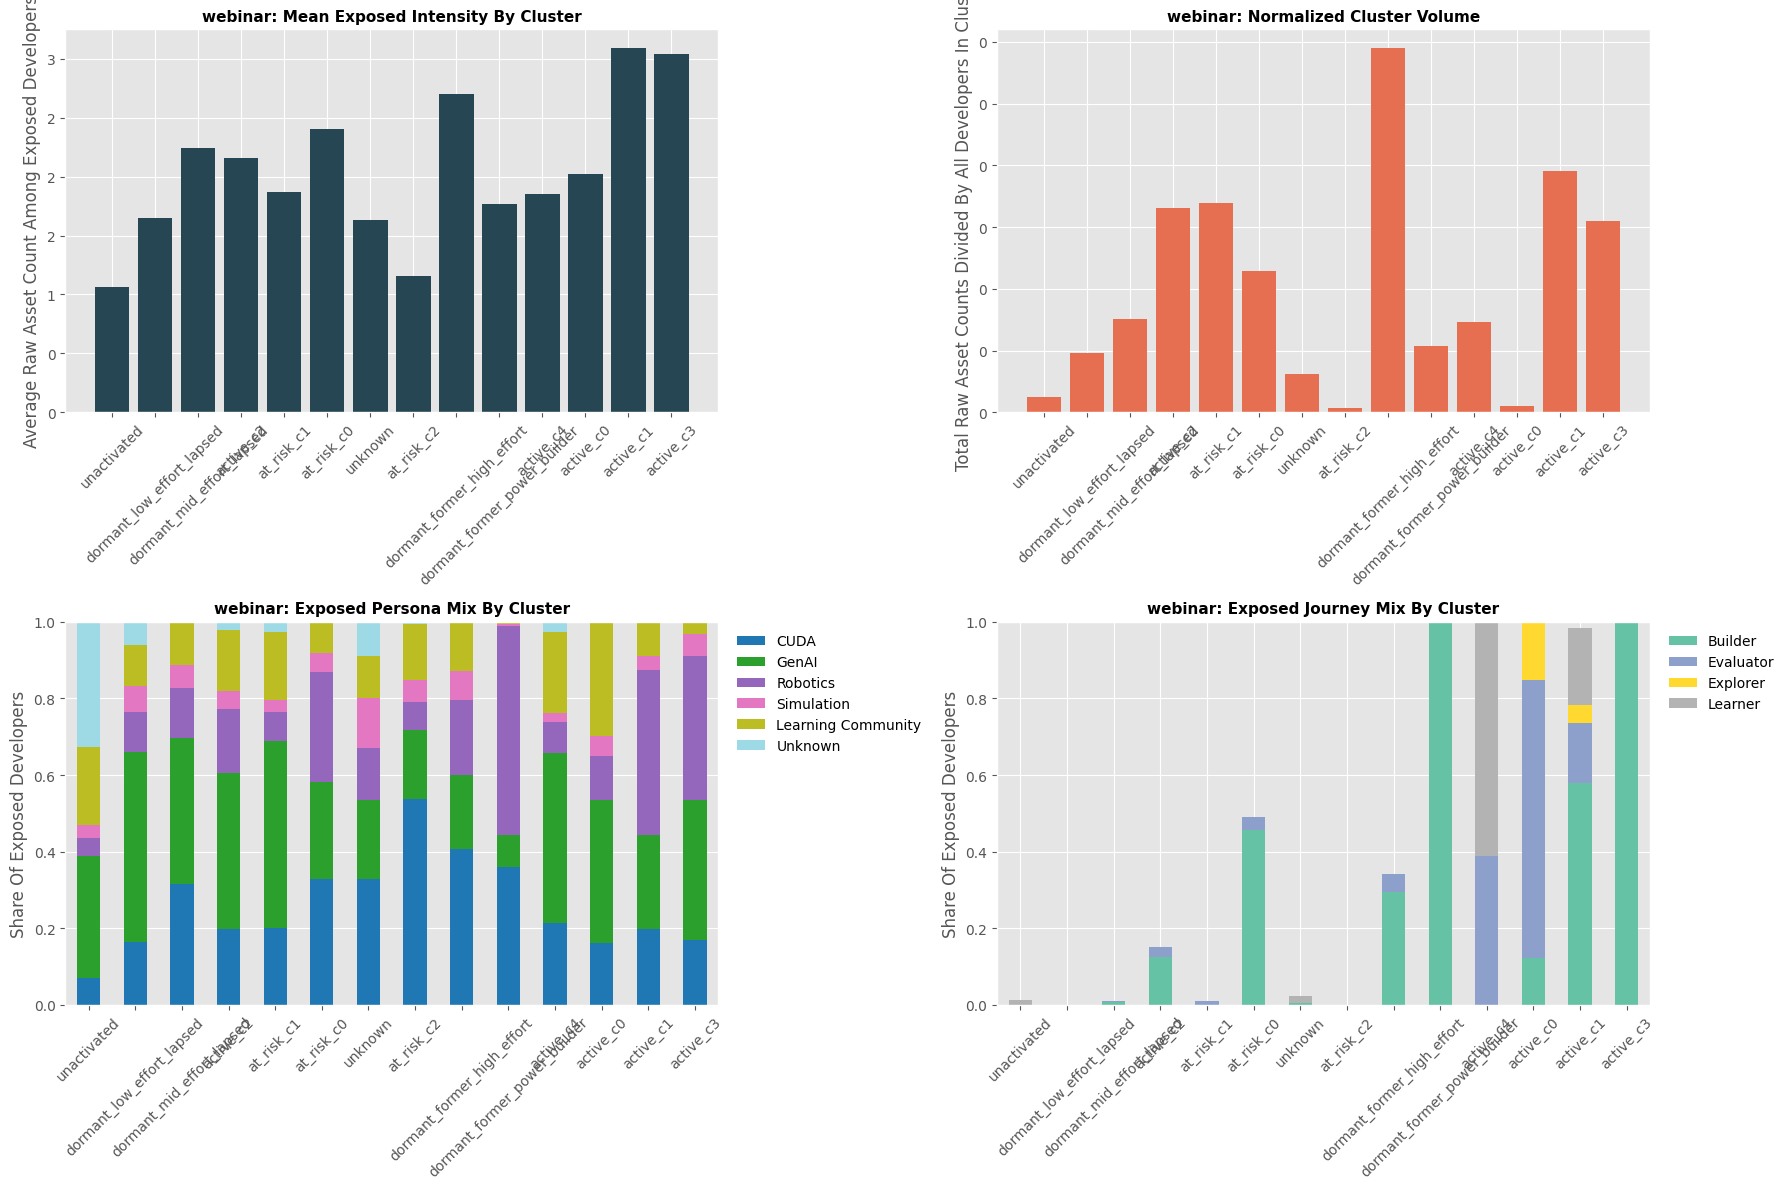

### Asset View: `devzone_download`

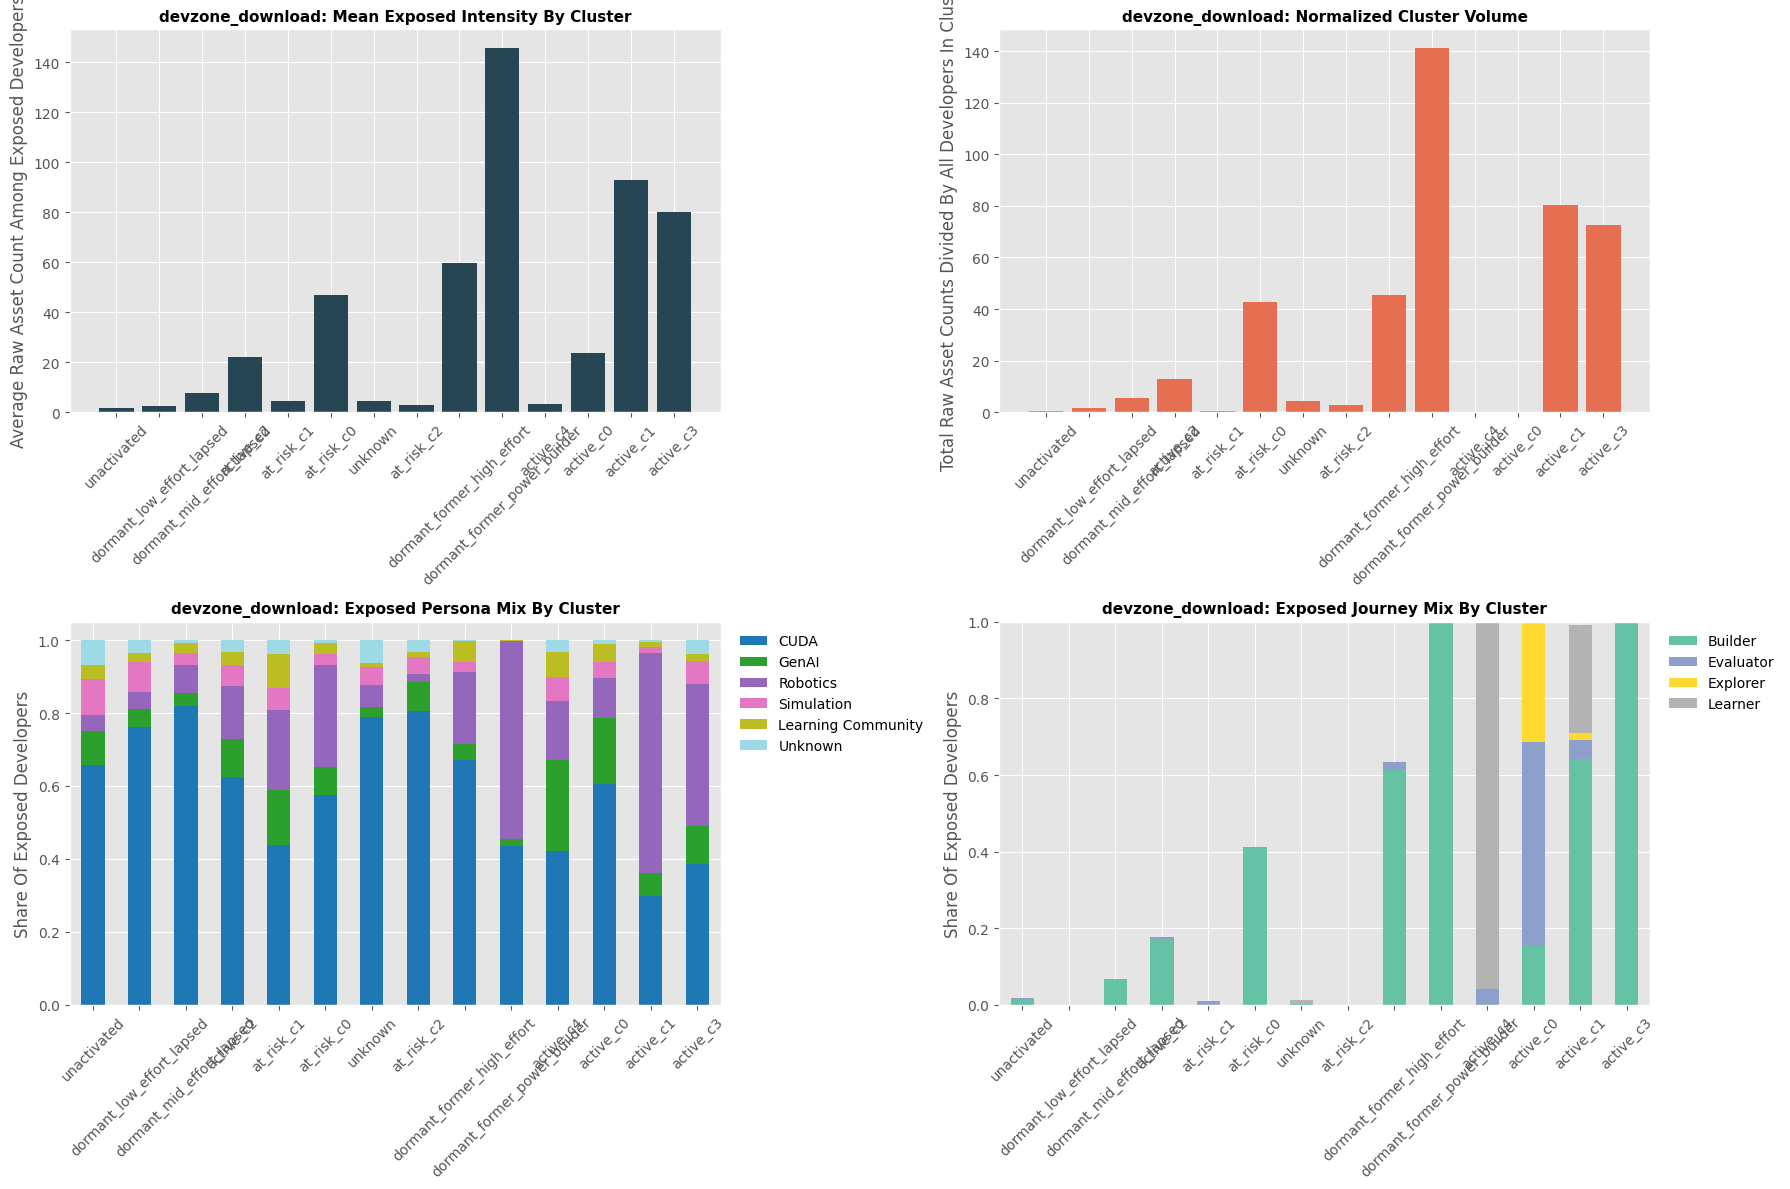

### Asset View: `hackathon`

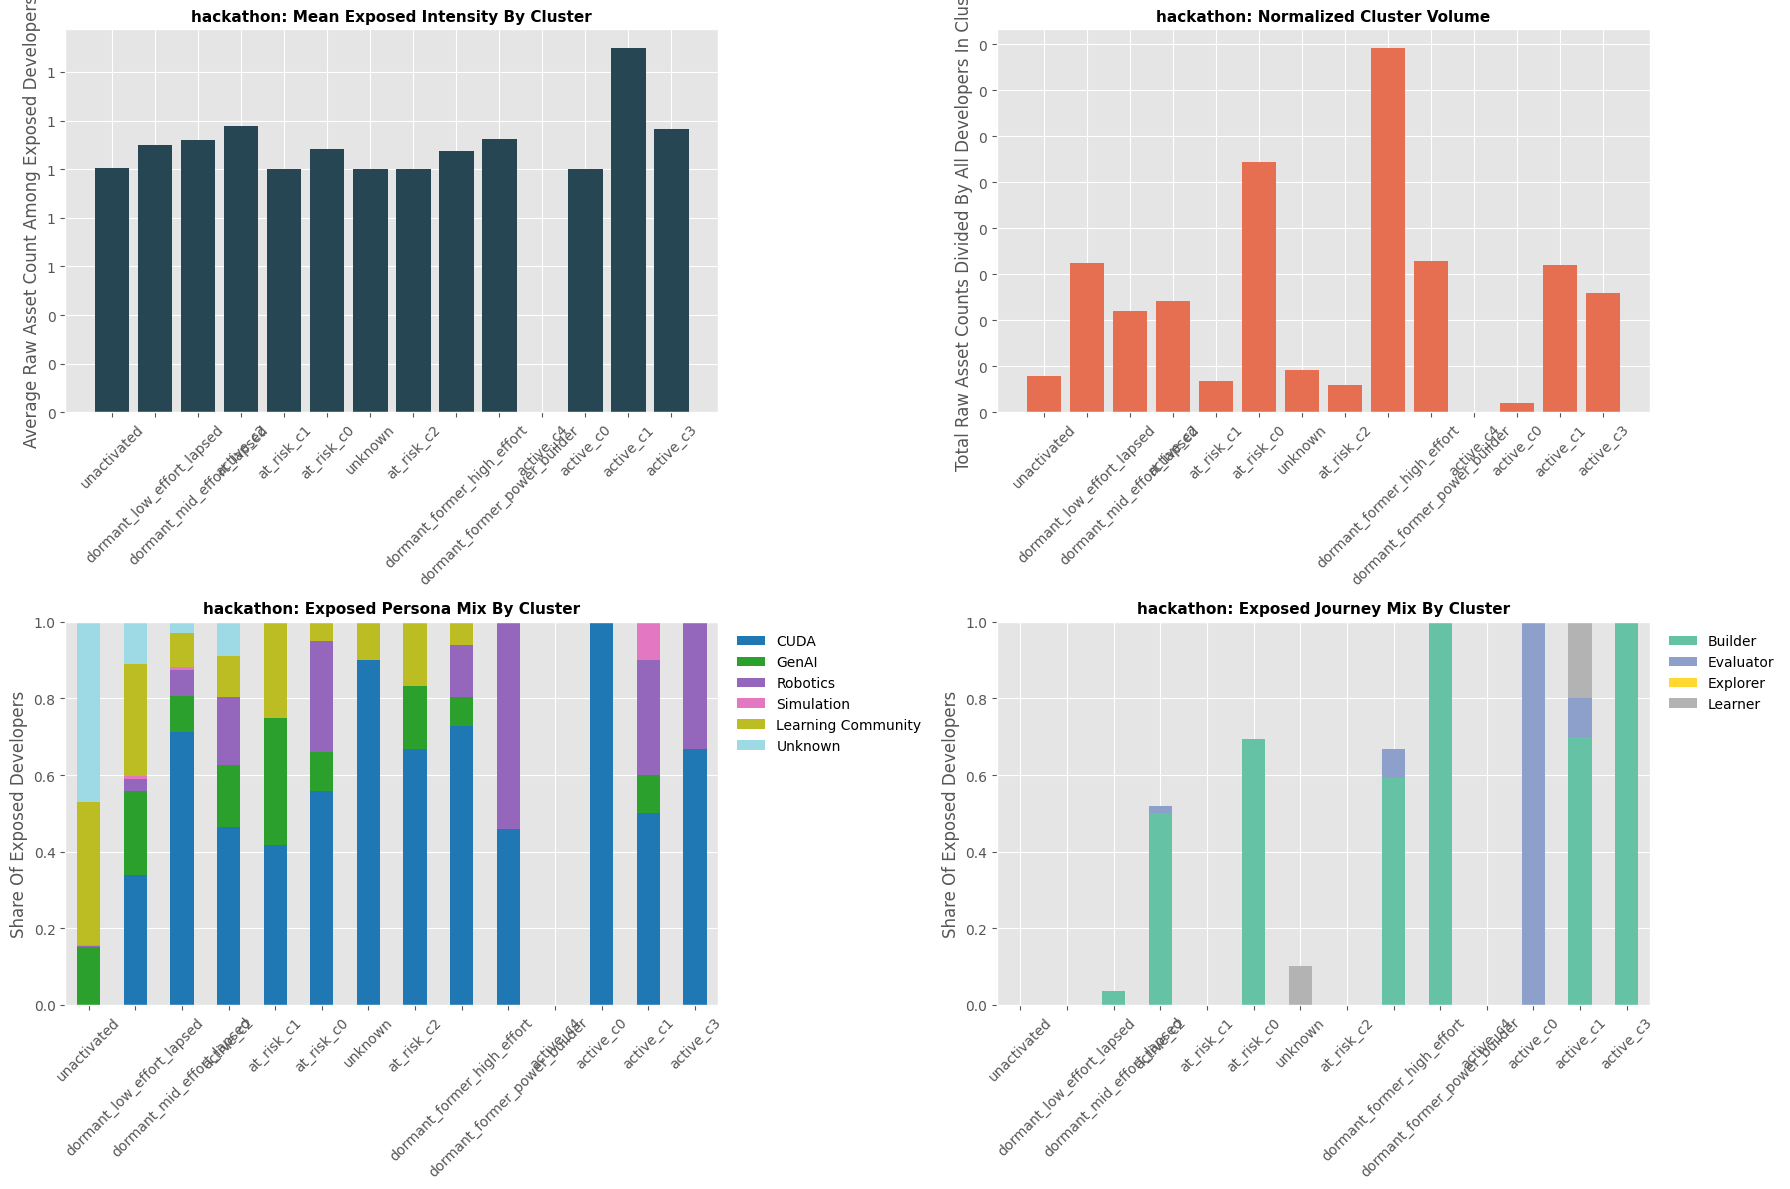

### Asset View: `ngc_download`

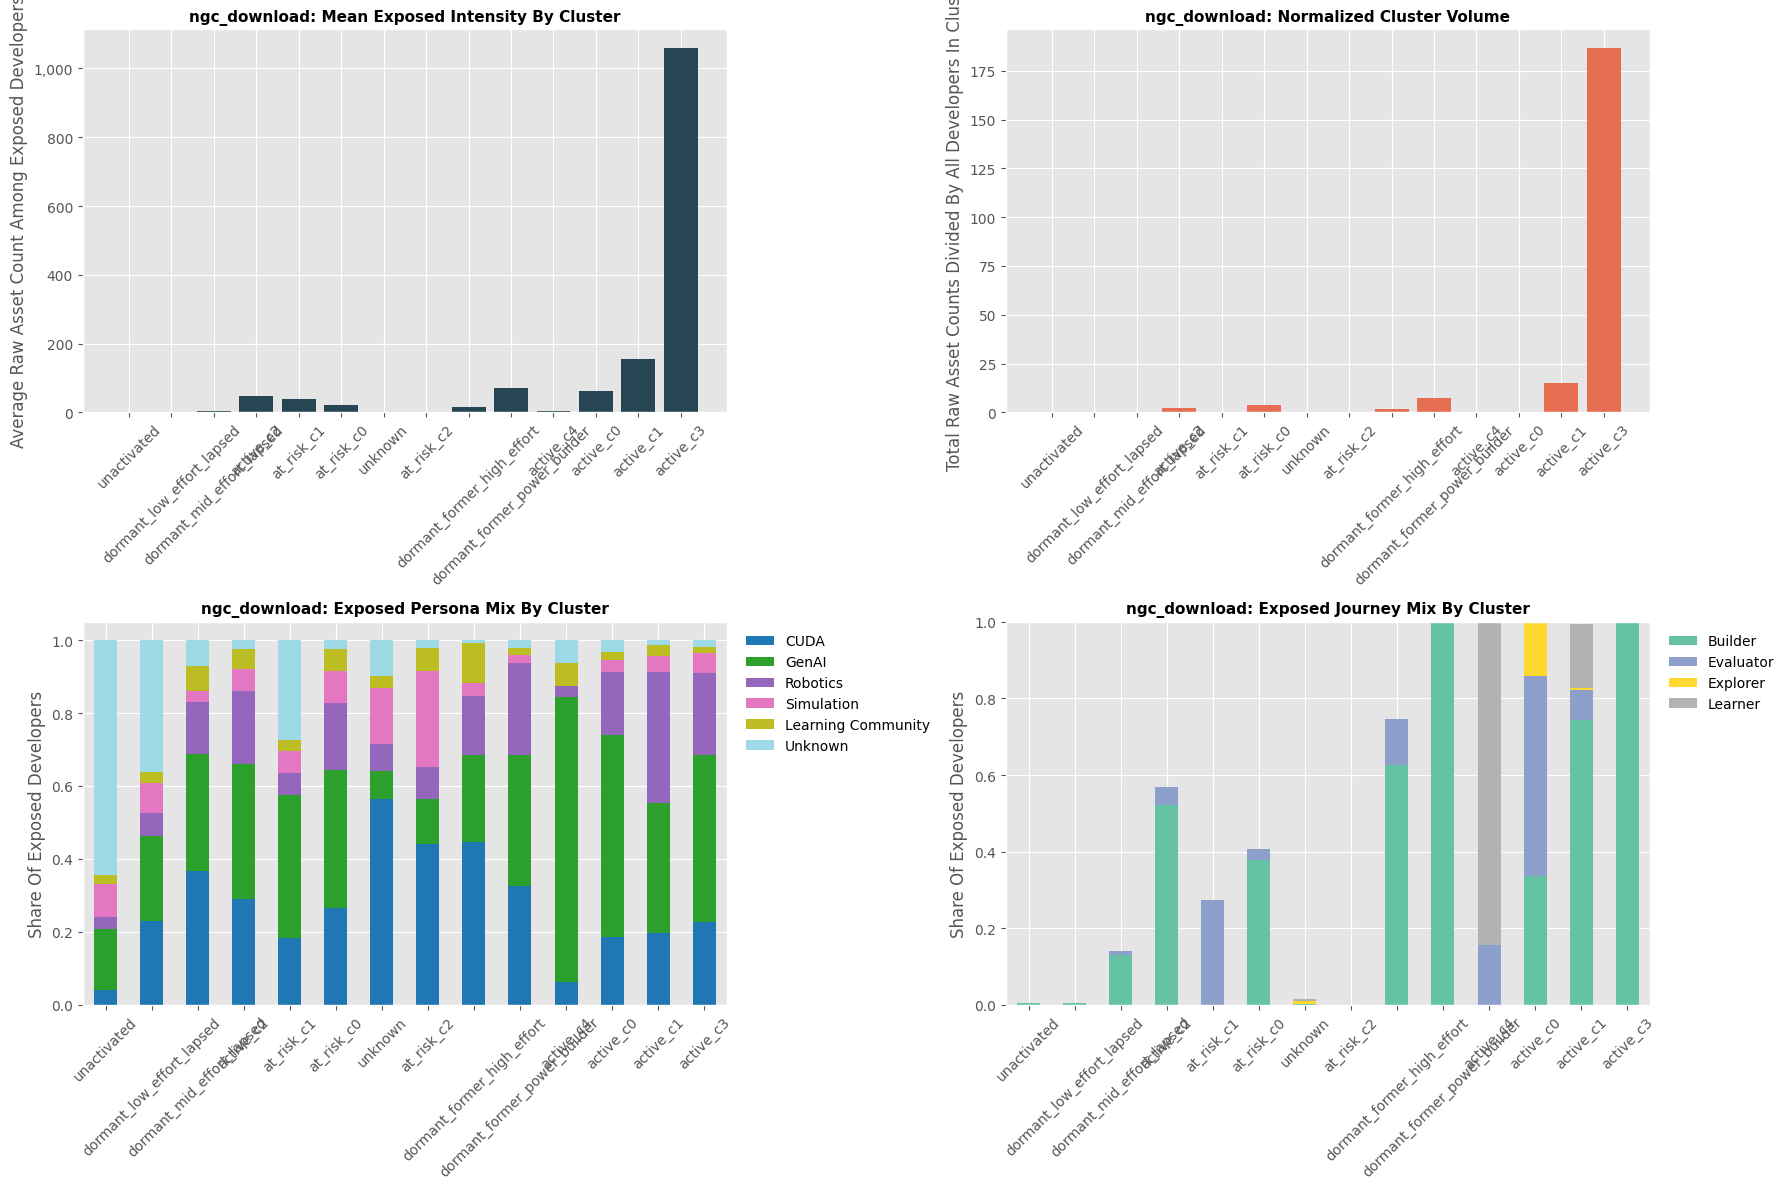

### Asset View: `forum_contribution`

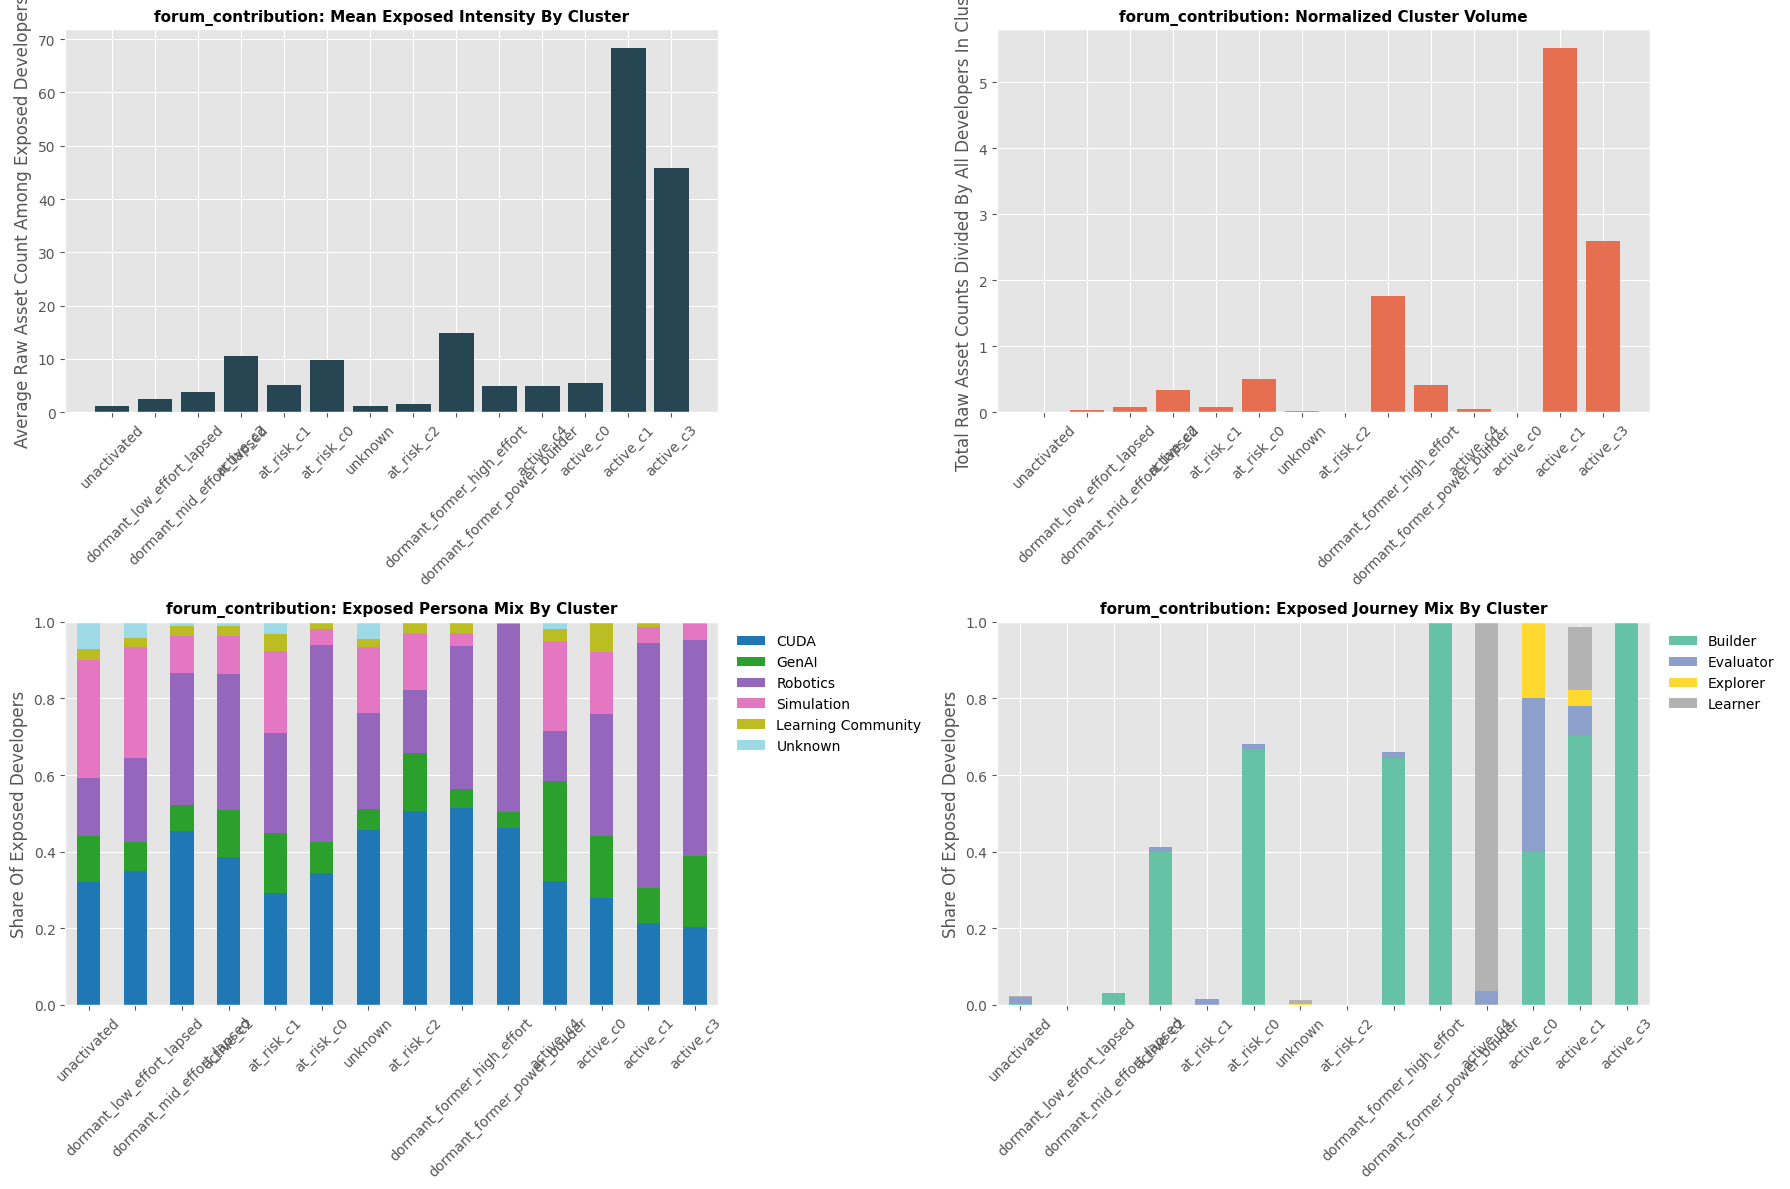

### Asset View: `bug_filed`

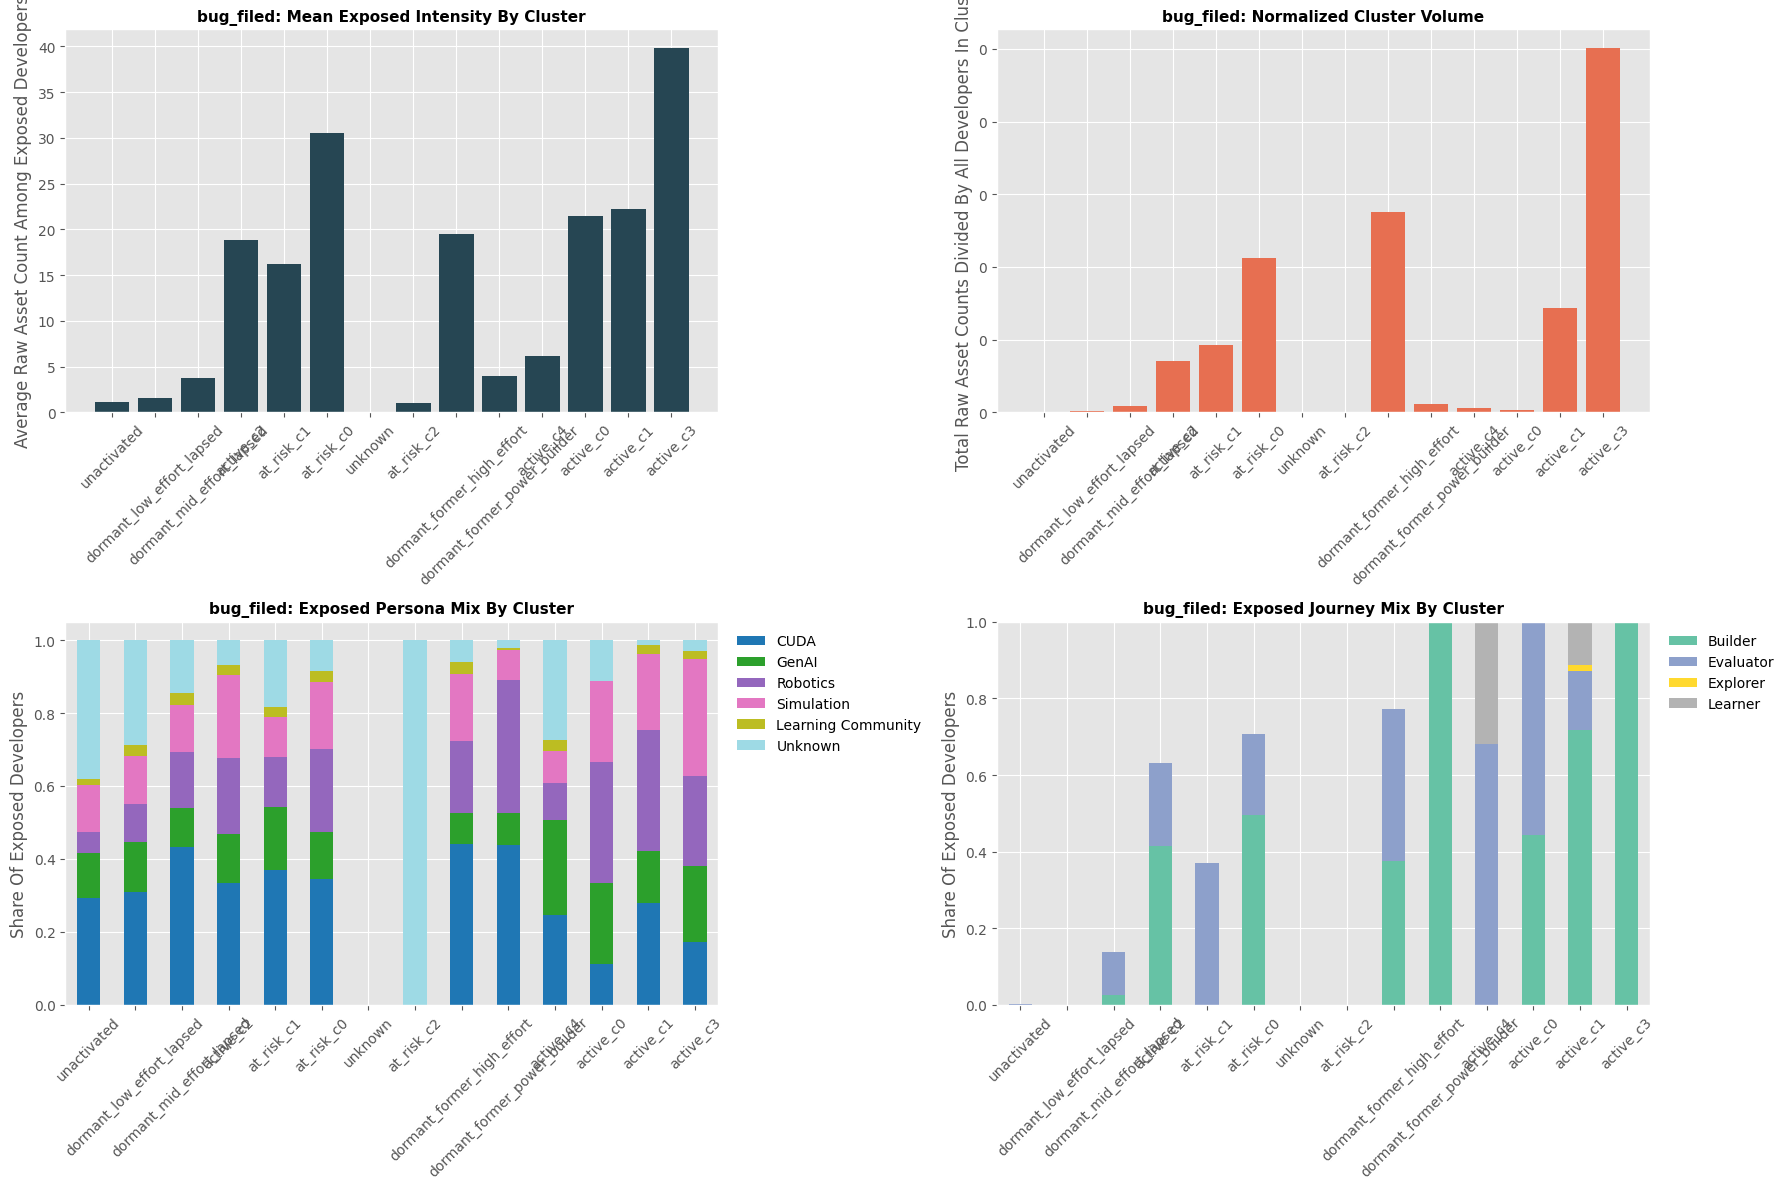

In [12]:
from matplotlib.ticker import StrMethodFormatter, PercentFormatter
import matplotlib.cm as cm
import numpy as np

cluster_order_df = con.execute(f"SELECT cluster_label, developers FROM {CLUSTER_ASSET_SUMMARY_TABLE} ORDER BY developers DESC").fetchdf()
cluster_order = cluster_order_df['cluster_label'].tolist()
cluster_sizes = dict(zip(cluster_order_df['cluster_label'], cluster_order_df['developers']))

summary_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_SUMMARY_TABLE}").fetchdf()
intensity_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_INTENSITY_TABLE}").fetchdf()
profile_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_EXPOSED_PROFILE_TABLE}").fetchdf()
priority_df = con.execute(f"SELECT * FROM {CLUSTER_ASSET_PRIORITY_TABLE}").fetchdf()
persona_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_PERSONA_PROFILE_TABLE}").fetchdf()
journey_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_JOURNEY_PROFILE_TABLE}").fetchdf()
journey_state_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_JOURNEY_STATE_PROFILE_TABLE}").fetchdf()
lifecycle_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_LIFECYCLE_PROFILE_TABLE}").fetchdf()
dormancy_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_DORMANCY_PROFILE_TABLE}").fetchdf()
effort_cluster_df = con.execute(f"SELECT * FROM {CLUSTER_EFFORT_PROFILE_TABLE}").fetchdf()

for df in [summary_df, intensity_df, profile_df, priority_df,
           persona_cluster_df, journey_cluster_df, journey_state_cluster_df, lifecycle_cluster_df,
           dormancy_cluster_df, effort_cluster_df]:
    df['cluster_label'] = pd.Categorical(df['cluster_label'], categories=cluster_order, ordered=True)

def finish_axes(ax, title, xlabel='', ylabel=''):
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def apply_plain_number_format(ax, axis='x'):
    fmt = StrMethodFormatter('{x:,.0f}')
    if axis == 'x':
        ax.xaxis.set_major_formatter(fmt)
    else:
        ax.yaxis.set_major_formatter(fmt)

# ============================================================
# Build a stable color map per share dimension so categories
# get the same color in every cluster
# ============================================================
def build_category_color_map(df, bucket_col, cmap_name):
    categories = sorted(df[bucket_col].dropna().unique().tolist())
    cmap = cm.get_cmap(cmap_name, max(len(categories), 1))
    return {cat: cmap(i) for i, cat in enumerate(categories)}, categories

persona_colors, persona_categories = build_category_color_map(persona_cluster_df, 'persona_bucket', 'tab20')
journey_colors, journey_categories = build_category_color_map(journey_cluster_df, 'journey_bucket', 'Set2')
journey_state_colors, journey_state_categories = build_category_color_map(journey_state_cluster_df, 'journey_state_bucket', 'Set3')
lifecycle_colors, lifecycle_categories = build_category_color_map(lifecycle_cluster_df, 'lifecycle_bucket', 'tab20b')
dormancy_colors, dormancy_categories = build_category_color_map(dormancy_cluster_df, 'dormancy_bucket', 'Paired')
effort_colors, effort_categories = build_category_color_map(effort_cluster_df, 'effort_bucket', 'Accent')

def plot_share_panel(ax, df, bucket_col, title, color_map, categories, cluster):
    pivot = df.pivot(index='cluster_label', columns=bucket_col, values='pct_within_cluster').fillna(0)
    # Reindex columns to the full category list so colors and order stay consistent
    pivot = pivot.reindex(columns=categories, fill_value=0)
    if cluster in pivot.index:
        row = pivot.loc[[cluster]]
        colors = [color_map[c] for c in categories]
        row.plot(kind='barh', stacked=True, ax=ax, color=colors, width=0.6, legend=False)
        ax.set_yticks([])
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0 if row.values.max() <= 1.0 else 100))
        finish_axes(ax, title, xlabel='Share Of Developers In Cluster')
        ax.legend(categories, loc='center left', bbox_to_anchor=(1.01, 0.5),
                  frameon=False, fontsize=7, ncol=1)
    else:
        ax.axis('off')
        ax.set_title(title, fontsize=11, weight='bold')

# ============================================================
# PART 1: CLUSTER-BY-CLUSTER SECTIONS
# ============================================================
display(Markdown('## Cluster-By-Cluster Breakdown'))

for cluster in cluster_order:
    size = cluster_sizes.get(cluster, 0)
    display(Markdown(f'### Cluster: `{cluster}` ({size:,} developers)'))

    fig = plt.figure(figsize=(20, 22))
    gs = fig.add_gridspec(4, 3, hspace=0.9, wspace=0.55,
                          left=0.05, right=0.82, top=0.96, bottom=0.04)

    # Row 0: persona (wide), journey stage
    ax_persona = fig.add_subplot(gs[0, 0:2])
    plot_share_panel(ax_persona, persona_cluster_df, 'persona_bucket',
                     'Persona Share', persona_colors, persona_categories, cluster)

    ax_journey = fig.add_subplot(gs[0, 2])
    plot_share_panel(ax_journey, journey_cluster_df, 'journey_bucket',
                     'Journey Stage Share', journey_colors, journey_categories, cluster)

    # Row 1: journey state, lifecycle, dormancy
    ax_journey_state = fig.add_subplot(gs[1, 0])
    plot_share_panel(ax_journey_state, journey_state_cluster_df, 'journey_state_bucket',
                     'Current Journey State Share', journey_state_colors, journey_state_categories, cluster)

    ax_lifecycle = fig.add_subplot(gs[1, 1])
    plot_share_panel(ax_lifecycle, lifecycle_cluster_df, 'lifecycle_bucket',
                     'Final Lifecycle Status Share', lifecycle_colors, lifecycle_categories, cluster)

    ax_dormancy = fig.add_subplot(gs[1, 2])
    plot_share_panel(ax_dormancy, dormancy_cluster_df, 'dormancy_bucket',
                     'Dormancy Share', dormancy_colors, dormancy_categories, cluster)

    # Row 2: effort, full width
    ax_effort = fig.add_subplot(gs[2, :])
    plot_share_panel(ax_effort, effort_cluster_df, 'effort_bucket',
                     'Effort Level Share', effort_colors, effort_categories, cluster)

    # Row 3: top assets by normalized volume, breadth, intensity
    ax_vol = fig.add_subplot(gs[3, 0])
    vol_df = priority_df[(priority_df['cluster_label'].astype(str) == cluster) &
                         (priority_df['rank_by_total_volume'] <= 5)
                         ].sort_values('asset_volume_per_cluster_developer', ascending=True)
    if not vol_df.empty:
        ax_vol.barh(vol_df['asset_name'], vol_df['asset_volume_per_cluster_developer'], color='#2a9d8f')
        apply_plain_number_format(ax_vol, axis='x')
        finish_axes(ax_vol, 'Top Assets By Normalized Volume',
                    xlabel='Activity Counts Per Cluster Developer')
    else:
        ax_vol.axis('off')
        ax_vol.set_title('Top Assets By Normalized Volume', fontsize=11, weight='bold')

    ax_breadth = fig.add_subplot(gs[3, 1])
    breadth_df = priority_df[(priority_df['cluster_label'].astype(str) == cluster) &
                             (priority_df['rank_by_breadth'] <= 5)
                             ].sort_values('exposure_rate', ascending=True)
    if not breadth_df.empty:
        ax_breadth.barh(breadth_df['asset_name'], breadth_df['exposure_rate'], color='#577590')
        ax_breadth.xaxis.set_major_formatter(
            PercentFormatter(xmax=1.0 if breadth_df['exposure_rate'].max() <= 1.0 else 100))
        finish_axes(ax_breadth, 'Top Assets By Breadth',
                    xlabel='Share Of Developers With >0 Usage')
    else:
        ax_breadth.axis('off')
        ax_breadth.set_title('Top Assets By Breadth', fontsize=11, weight='bold')

    ax_int = fig.add_subplot(gs[3, 2])
    int_df = priority_df[(priority_df['cluster_label'].astype(str) == cluster) &
                         (priority_df['rank_by_intensity'] <= 5)
                         ].sort_values('avg_exposure_value_exposed', ascending=True)
    if not int_df.empty:
        ax_int.barh(int_df['asset_name'], int_df['avg_exposure_value_exposed'], color='#f3722c')
        apply_plain_number_format(ax_int, axis='x')
        finish_axes(ax_int, 'Top Assets By Intensity',
                    xlabel='Avg Asset Count Among Exposed')
    else:
        ax_int.axis('off')
        ax_int.set_title('Top Assets By Intensity', fontsize=11, weight='bold')

    fig.suptitle(f'Cluster {cluster} — Composition And Top Activity Assets',
                 fontsize=14, weight='bold', y=0.985)
    plt.show()

# ============================================================
# PART 2: AGGREGATE / OVERVIEW
# ============================================================
display(Markdown('## Aggregate Overview Across Clusters'))

display(Markdown('### Cluster-Level Activity And Exposure Overview'))
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
overview_specs = [
    ('avg_rankable_activity_assets_exposed', 'Average Rankable Activity Assets Exposed'),
    ('avg_behavior_descriptors_active', 'Average Behavior Descriptors Active'),
    ('avg_activity_count_0_30d', 'Average Activity Count 0-30d'),
    ('avg_activity_count_30_90d', 'Average Activity Count 30-90d')
]
for ax, (col, title) in zip(axes.flatten(), overview_specs):
    plot_df = summary_df.sort_values('cluster_label')
    ax.bar(plot_df['cluster_label'].astype(str), plot_df[col], color='#1f77b4')
    apply_plain_number_format(ax, axis='y')
    finish_axes(ax, title, ylabel='Value')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for label, df, bucket_col, color_map, categories in [
    ('Persona Share By Cluster', persona_cluster_df, 'persona_bucket', persona_colors, persona_categories),
    ('Journey Stage Share By Cluster', journey_cluster_df, 'journey_bucket', journey_colors, journey_categories),
    ('Current Journey State Share By Cluster', journey_state_cluster_df, 'journey_state_bucket', journey_state_colors, journey_state_categories),
    ('Final Lifecycle Status Share By Cluster', lifecycle_cluster_df, 'lifecycle_bucket', lifecycle_colors, lifecycle_categories),
    ('Dormancy Share By Cluster', dormancy_cluster_df, 'dormancy_bucket', dormancy_colors, dormancy_categories),
    ('Effort Level Share By Cluster', effort_cluster_df, 'effort_bucket', effort_colors, effort_categories),
]:
    display(Markdown(f'### {label}'))
    pivot = df.pivot(index='cluster_label', columns=bucket_col, values='pct_within_cluster').fillna(0).sort_index()
    pivot = pivot.reindex(columns=categories, fill_value=0)
    colors = [color_map[c] for c in categories]
    fig, ax = plt.subplots(figsize=(16, 7))
    pivot.plot(kind='bar', stacked=True, ax=ax, color=colors)
    finish_axes(ax, label, ylabel='Share Of Developers In Cluster')
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0 if pivot.values.max() <= 1.0 else 100))
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, title=bucket_col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# ============================================================
# PART 3: PER-ASSET VIEWS
# ============================================================
display(Markdown('## Per-Asset Views'))

asset_plot_df = intensity_df[intensity_df['analysis_role'] == 'rankable_activity_asset'].copy()
asset_names = asset_plot_df['asset_name'].drop_duplicates().tolist()

persona_cols = [
    ('pct_cuda', 'CUDA'),
    ('pct_genai', 'GenAI'),
    ('pct_robotics', 'Robotics'),
    ('pct_simulation', 'Simulation'),
    ('pct_learning_community', 'Learning Community'),
    ('pct_unknown_persona', 'Unknown')
]
journey_cols = [
    ('pct_builder', 'Builder'),
    ('pct_evaluator', 'Evaluator'),
    ('pct_explorer', 'Explorer'),
    ('pct_learner', 'Learner')
]

# Stable colors for the per-asset persona/journey panels
asset_persona_labels = [label for _, label in persona_cols]
asset_journey_labels = [label for _, label in journey_cols]
asset_persona_cmap = cm.get_cmap('tab20', len(asset_persona_labels))
asset_journey_cmap = cm.get_cmap('Set2', len(asset_journey_labels))
asset_persona_colors = [asset_persona_cmap(i) for i in range(len(asset_persona_labels))]
asset_journey_colors = [asset_journey_cmap(i) for i in range(len(asset_journey_labels))]

for asset_name in asset_names:
    intensity_asset = asset_plot_df[asset_plot_df['asset_name'] == asset_name].sort_values('cluster_label')
    profile_asset = profile_df[(profile_df['asset_name'] == asset_name) &
                               (profile_df['analysis_role'] == 'rankable_activity_asset')].sort_values('cluster_label')
    if intensity_asset.empty or profile_asset.empty:
        continue

    display(Markdown(f'### Asset View: `{asset_name}`'))
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    axes[0, 0].bar(intensity_asset['cluster_label'].astype(str), intensity_asset['avg_exposure_value_exposed'], color='#264653')
    apply_plain_number_format(axes[0, 0], axis='y')
    finish_axes(axes[0, 0], f'{asset_name}: Mean Exposed Intensity By Cluster',
                ylabel='Average Raw Asset Count Among Exposed Developers')
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].bar(intensity_asset['cluster_label'].astype(str), intensity_asset['asset_volume_per_cluster_developer'], color='#e76f51')
    apply_plain_number_format(axes[0, 1], axis='y')
    finish_axes(axes[0, 1], f'{asset_name}: Normalized Cluster Volume',
                ylabel='Total Raw Asset Counts Divided By All Developers In Cluster')
    axes[0, 1].tick_params(axis='x', rotation=45)

    persona_plot = profile_asset[['cluster_label'] + [c for c, _ in persona_cols]].copy().set_index('cluster_label')
    persona_plot.columns = asset_persona_labels
    persona_plot.plot(kind='bar', stacked=True, ax=axes[1, 0], color=asset_persona_colors)
    finish_axes(axes[1, 0], f'{asset_name}: Exposed Persona Mix By Cluster',
                ylabel='Share Of Exposed Developers')
    axes[1, 0].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
    axes[1, 0].tick_params(axis='x', rotation=45)

    journey_plot = profile_asset[['cluster_label'] + [c for c, _ in journey_cols]].copy().set_index('cluster_label')
    journey_plot.columns = asset_journey_labels
    journey_plot.plot(kind='bar', stacked=True, ax=axes[1, 1], color=asset_journey_colors)
    finish_axes(axes[1, 1], f'{asset_name}: Exposed Journey Mix By Cluster',
                ylabel='Share Of Exposed Developers')
    axes[1, 1].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False)
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [13]:
con.close()